# First Implementation 


There is the pipeline
**camera.py**: builds the intrinsics for each pyramid level
**frameData.py**: stores image, derivatives, inverse depth, and pose
**pose_estimator_gauss_newton.py**: optimizes the pose
**common.py**: bilinear interpolation
**dataset/desktop_dataset/images**: input images
**Depth-Anything**: computes depth maps on the fly from the images


In this notebook, the simplest setup is now:

- you directly provide the path to the reference image
- you directly provide the path to the current image

You no longer need to use indices such as `scene_000`, `scene_001`, and so on.


In [40]:
from pathlib import Path
import copy
import hashlib
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.transforms import Compose

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent

PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

import importlib.util
try:
    import camera
except ModuleNotFoundError:
    camera_path = SCRIPT_DIR / "camera.py"
    if camera_path.exists():
        spec = importlib.util.spec_from_file_location("camera", str(camera_path))
        camera = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(camera)
        sys.modules["camera"] = camera
    else:
        raise
import common
import frameData
import pose_estimator_gauss_newton


In [41]:
plt.rcParams["figure.figsize"] = (8, 5)
np.set_printoptions(precision=6, suppress=True)

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
DEPTH_ANYTHING_DIR = PROJECT_ROOT / "Depth-Anything"

if not DEPTH_ANYTHING_DIR.exists():
    raise FileNotFoundError(f"Depth-Anything not found: {DEPTH_ANYTHING_DIR}")

if str(DEPTH_ANYTHING_DIR) not in sys.path:
    sys.path.insert(0, str(DEPTH_ANYTHING_DIR))

from depth_anything.dpt import DepthAnything
from depth_anything.util.transform import NormalizeImage, PrepareForNet, Resize



In [42]:


DEPTH_ENCODER = "vitb"
DEPTH_MODEL_NAME = f"LiheYoung/depth_anything_{DEPTH_ENCODER}14"
DEPTH_CACHE_DIR = SCRIPT_DIR / "depth_anything_cache" / DEPTH_ENCODER
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEPTH_CACHE_DIR.mkdir(parents=True, exist_ok=True)


--------------

### Convert to frame, create a list of these frames

In [43]:
import convert_video_frame
convert_video_frame.video_to_frames_and_save(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\ai\TUM_fake.mp4", r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\ai\TUM_fake_frames")

FPS : 24.0
Nombre total de trames : 121
121 frames sauvegardees dans : C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\ai\TUM_fake_frames


In [44]:
dossier_fake = Path(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\ai\TUM_fake_frames")


In [45]:
fake_frame_paths = sorted(
    str(f.resolve())
    for f in dossier_fake.rglob("*")
    if f.is_file()
)

print(f"{len(fake_frame_paths)} fichiers trouvés dans {dossier_fake}")

121 fichiers trouvés dans C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\ai\TUM_fake_frames


In [46]:

KEYFRAME_PATH = fake_frame_paths[0]
TARGET_PATH= fake_frame_paths[1]

print(KEYFRAME_PATH)
print(TARGET_PATH)

C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\ai\TUM_fake_frames\frame_00000.png
C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\ai\TUM_fake_frames\frame_00001.png


## 2. Notebook utility functions

Here we rewrite a few small helper functions to make the pipeline explicit:

- load a grayscale image from its path
- compute a depth map with Depth Anything
- convert depth -> inverse depth
- quickly display a 4x4 matrix

The depth is inferred directly from the corresponding image with the `vitb` encoder, and can optionally be cached in `depth_anything_cache/vitb` to avoid recomputing it every time.

The important conversion is:

$$
\rho = \frac{1}{d}
$$

where **d** is the depth and **rho** is the inverse depth expected by the solver.


In [47]:


#PERMET DE NORMALISER LE CHEMIN DE L'IMAGE, EN S'ASSURANT QU'IL EST ABSOLU ET QU'IL EXISTE
def normalize_image_path(path_like) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        path = (ROOT / path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    return path



#PERMET DE CONSTRUIRE LE CHEMIN DE CACHE POUR LA CARTE DE PROFONDEUR CORRESPONDANTE À UNE IMAGE, EN UTILISANT UN HASH DU CHEMIN DE L'IMAGE POUR ÉVITER LES CONFLITS
def build_depth_cache_path(image_path: Path) -> Path:
    safe_name = image_path.stem.replace(" ", "_")
    cache_key = hashlib.md5(str(image_path.resolve()).encode("utf-8")).hexdigest()[:8]
    cache_name = f"{safe_name}_{cache_key}_depth.npy"
    return DEPTH_CACHE_DIR / cache_name


#PERMET DE CHARGER UNE IMAGE EN NIVEAUX DE GRIS À PARTIR D'UN CHEMIN, EN UTILISANT OPENCV POUR LIRE LE FICHIER ET LE CONVERTIR EN UN TABLEAU NUMPY
def load_gray_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def load_rgb_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def get_depth_anything_components():
    if not hasattr(get_depth_anything_components, "model"):
        previous_cwd = Path.cwd()
        try:
            os.chdir(DEPTH_ANYTHING_DIR)
            model = DepthAnything.from_pretrained(DEPTH_MODEL_NAME).to(DEVICE).eval()
        finally:
            os.chdir(previous_cwd)

        transform = Compose([
            Resize(
                width=518,
                height=518,
                resize_target=False,
                keep_aspect_ratio=True,
                ensure_multiple_of=14,
                resize_method="lower_bound",
                image_interpolation_method=cv2.INTER_CUBIC,
            ),
            NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            PrepareForNet(),
        ])
        get_depth_anything_components.model = model
        get_depth_anything_components.transform = transform

        total_params = sum(param.numel() for param in model.parameters())
        print(f"Depth Anything loaded on {DEVICE} ({total_params / 1e6:.2f}M parameters)")

    return get_depth_anything_components.model, get_depth_anything_components.transform


def load_depth_map(image_path, use_cache: bool = True, save_cache: bool = True) -> np.ndarray:
    path = normalize_image_path(image_path)
    cache_path = build_depth_cache_path(path)
    if use_cache and cache_path.exists():
        return np.load(cache_path).astype(np.float32)

    image = load_rgb_image(path).astype(np.float32) / 255.0
    h, w = image.shape[:2]

    model, transform = get_depth_anything_components()
    image = transform({"image": image})["image"]
    image = torch.from_numpy(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        depth = model(image)

    depth = F.interpolate(depth[None], (h, w), mode="bilinear", align_corners=False)[0, 0]
    depth = depth.cpu().numpy().astype(np.float32)

    if save_cache:
        np.save(cache_path, depth)

    return depth


def depth_to_invdepth(depth: np.ndarray):
    inv_depth = np.zeros_like(depth, dtype=np.float32)
    valid_mask = depth > 1e-6
    inv_depth[valid_mask] = 1.0 / depth[valid_mask]
    inv_depth_var = np.ones_like(depth, dtype=np.float32)
    inv_depth_var[~valid_mask] = 1e6
    return inv_depth, inv_depth_var, valid_mask


def show_pose_matrix(title: str, pose):
    matrix = pose.as_matrix()
    print(title)
    print(matrix)
    return matrix


(720, 1280)


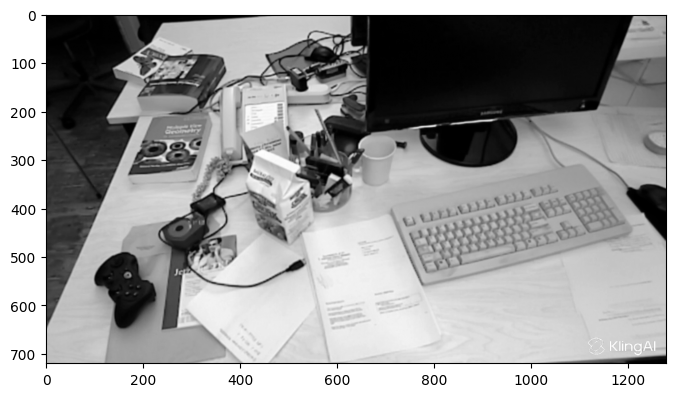

In [48]:
frame_0 = load_gray_image(KEYFRAME_PATH)
print(frame_0.shape)
plt.imshow(frame_0, cmap='gray')

## keyframe

Here we load:

- the reference image specified in `KEYFRAME_PATH`
- the depth map inferred by **Depth Anything** for this image

This image provides the base 3D geometry.


In [49]:
keyframe_image_path = normalize_image_path(KEYFRAME_PATH)
keyframe_image = load_gray_image(keyframe_image_path)
keyframe_depth = load_depth_map(keyframe_image_path)
keyframe_inv_depth, keyframe_inv_depth_var, valid_mask = depth_to_invdepth(keyframe_depth)


In [50]:

print("keyframe_image_path =", keyframe_image_path)
print("keyframe_image shape =", keyframe_image.shape, "dtype =", keyframe_image.dtype)
print("keyframe_depth shape =", keyframe_depth.shape, "dtype =", keyframe_depth.dtype)
print("depth min/max =", float(keyframe_depth.min()), float(keyframe_depth.max()))
print("valid depth ratio =", float(valid_mask.mean()))


keyframe_image_path = C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\ai\TUM_fake_frames\frame_00000.png
keyframe_image shape = (720, 1280) dtype = uint8
keyframe_depth shape = (720, 1280) dtype = float32
depth min/max = 0.0 65.0137939453125
valid depth ratio = 0.9769476996527777


Text(0.5, 1.0, 'Inverse depth')

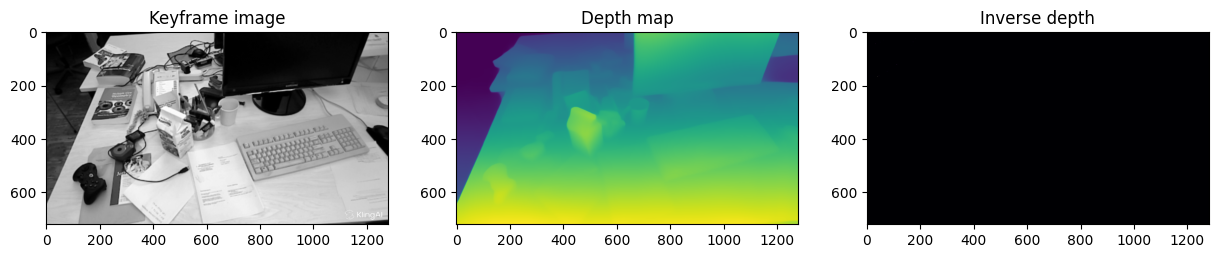

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))




axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title("Keyframe image")

axes[1].imshow(keyframe_depth, cmap="viridis")
axes[1].set_title("Depth map")


axes[2].imshow(keyframe_inv_depth, cmap="magma")
axes[2].set_title("Inverse depth")




## 4. Intrinsics

Dans ce notebook, les intrinseques doivent etre definies **une seule fois** dans la cellule suivante.

Idee simple :
- tu choisis `USER_FX`, `USER_FY`, `USER_CX`, `USER_CY`
- ces valeurs sont la **source de verite**
- elles sont passees a `camera.camera(...)`
- ensuite on affiche clairement ce que le pipeline utilise vraiment

Important :
- `frameData.py` et `camera.py` redimensionnent tout vers la resolution interne definie dans `params.py`
- donc on affiche a la fois :
  - `K_user` = la matrice que tu choisis
  - `K_used_lvl0` = la matrice effectivement utilisee au niveau 0 de la pyramide

Comme ca, il n'y a plus d'ambiguite sur les intrinseques utilisees dans la suite du notebook.



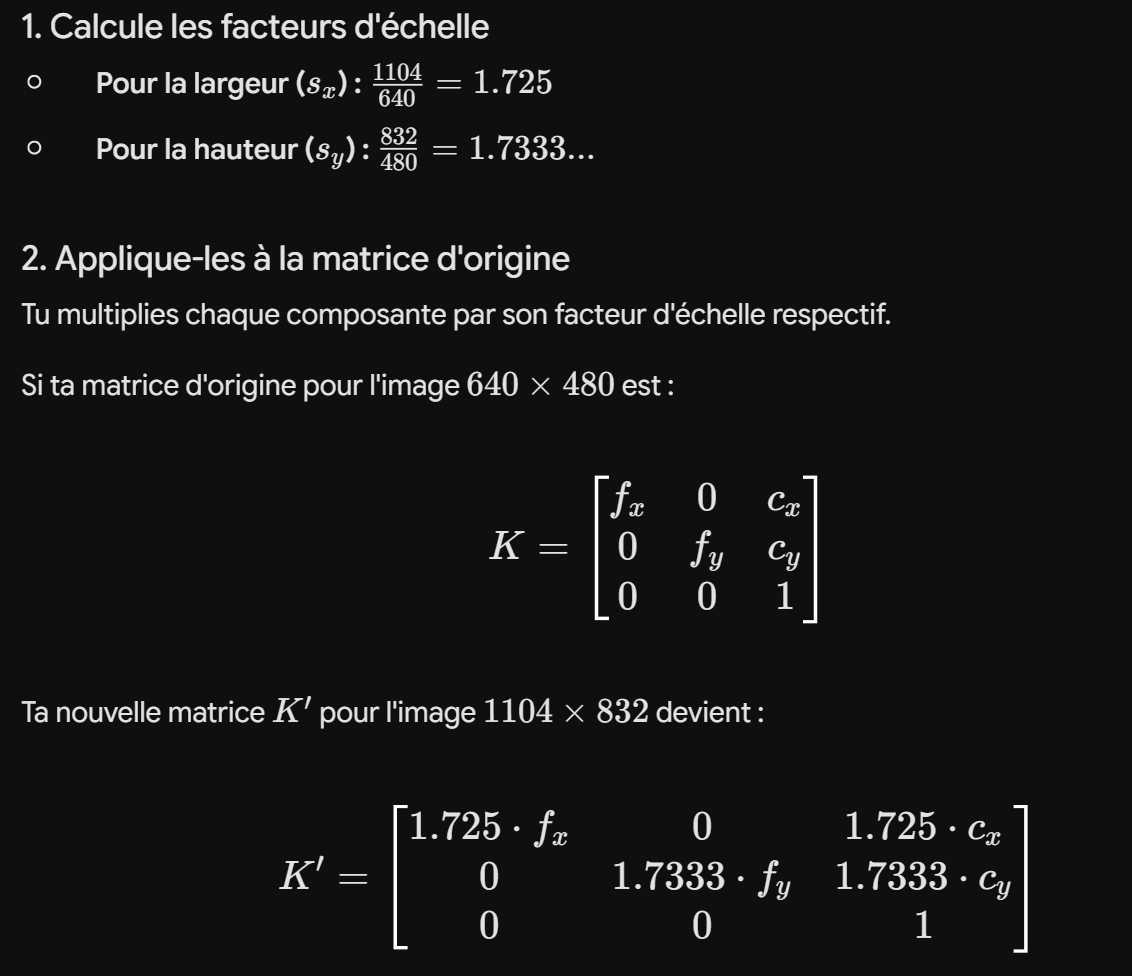

In [52]:

import base64
from IPython.display import HTML
with open(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\capture.png","rb") as f:
    with open(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\capture.png","rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    HTML(f'<div style="text-align:center;"><img src="data:image/png;base64,{b64}" width="900"/></div>')
HTML(f'<div style="text-align:center;"><img src="data:image/png;base64,{b64}" width="900"/></div>')

In [53]:
# ==================================================
# Intrinseques a definir UNE FOIS au debut
# ==================================================
loaded_height, loaded_width = keyframe_image.shape[:2]

# Mets ici les intrinseques que tu veux utiliser.
# Ce bloc est la source de verite pour tout le notebook.
USER_WIDTH = loaded_width
USER_HEIGHT = loaded_height


#Pour Emanuel
#USER_FX = 481.20 * 1.725
#USER_FY = 480.0 * 1.73333
#USER_CX = 319.5 * 1.725
#USER_CY = 239.5 * 1.73333


#Pour tum RGB
USER_FX = 525.0  *2
USER_FY = 525.0  *1.5
USER_CX = 319.5  *2
USER_CY = 239.5  *1.5




intrinsics_user = {
    "width": USER_WIDTH,
    "height": USER_HEIGHT,
    "fx": USER_FX,
    "fy": USER_FY,
    "cx": USER_CX,
    "cy": USER_CY,
}

K_user = np.array([
    [USER_FX, 0.0, USER_CX],
    [0.0, USER_FY, USER_CY],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    USER_WIDTH,
    USER_HEIGHT,
)

intrinsics_used_lvl0 = {
    "width": cam.width[0],
    "height": cam.height[0],
    "fx": cam.fx[0],
    "fy": cam.fy[0],
    "cx": cam.cx[0],
    "cy": cam.cy[0],
}

K_used_lvl0 = np.array([
    [cam.fx[0], 0.0, cam.cx[0]],
    [0.0, cam.fy[0], cam.cy[0]],
    [0.0, 0.0, 1.0],
], dtype=np.float64)

print("Loaded keyframe size:")
print("  width  =", loaded_width)
print("  height =", loaded_height)
print()
print("USER intrinsics chosen at the beginning of the notebook:")
print(intrinsics_user)
print()
print("K_user =")
print(K_user)
print()
print("Internal working resolution used by the pipeline (level 0):")
print("  width  =", intrinsics_used_lvl0["width"])
print("  height =", intrinsics_used_lvl0["height"])
print()
print("K_used_lvl0 =")
print(K_used_lvl0)


Loaded keyframe size:
  width  = 1280
  height = 720

USER intrinsics chosen at the beginning of the notebook:
{'width': 1280, 'height': 720, 'fx': 1050.0, 'fy': 787.5, 'cx': 639.0, 'cy': 359.25}

K_user =
[[1050.      0.    639.  ]
 [   0.    787.5   359.25]
 [   0.      0.      1.  ]]

Internal working resolution used by the pipeline (level 0):
  width  = 640
  height = 480

K_used_lvl0 =
[[525.    0.  319.5]
 [  0.  525.  239.5]
 [  0.    0.    1. ]]


In [54]:
scale_x = cam.width[0] / USER_WIDTH
scale_y = cam.height[0] / USER_HEIGHT

print("Check that the pipeline camera really comes from the USER intrinsics above:")
print("  scale_x =", scale_x)
print("  scale_y =", scale_y)
print()
print("  USER_FX -> cam.fx[0] :", USER_FX, "->", cam.fx[0])
print("  USER_FY -> cam.fy[0] :", USER_FY, "->", cam.fy[0])
print("  USER_CX -> cam.cx[0] :", USER_CX, "->", cam.cx[0])
print("  USER_CY -> cam.cy[0] :", USER_CY, "->", cam.cy[0])
print()
print("Expected level-0 values after internal resize:")
print("  expected fx =", USER_FX * scale_x)
print("  expected fy =", USER_FY * scale_y)
print("  expected cx =", USER_CX * scale_x)
print("  expected cy =", USER_CY * scale_y)

assert np.isclose(cam.fx[0], USER_FX * scale_x)
assert np.isclose(cam.fy[0], USER_FY * scale_y)
assert np.isclose(cam.cx[0], USER_CX * scale_x)
assert np.isclose(cam.cy[0], USER_CY * scale_y)

print()
print("Assertion passed: the notebook is using the intrinsics defined above.")


Check that the pipeline camera really comes from the USER intrinsics above:
  scale_x = 0.5
  scale_y = 0.6666666666666666

  USER_FX -> cam.fx[0] : 1050.0 -> 525.0
  USER_FY -> cam.fy[0] : 787.5 -> 525.0
  USER_CX -> cam.cx[0] : 639.0 -> 319.5
  USER_CY -> cam.cy[0] : 359.25 -> 239.5

Expected level-0 values after internal resize:
  expected fx = 525.0
  expected fy = 525.0
  expected cx = 319.5
  expected cy = 239.5

Assertion passed: the notebook is using the intrinsics defined above.


### Verification for every pyramid level

On affiche maintenant les intrinseques utilisees a **chaque niveau** de la pyramide, et on verifie qu elles correspondent bien a la regle automatique du code : division par `2**lvl` a partir du niveau 0.

In [55]:
intrinsics_per_level = []
base_fx = cam.fx[0]
base_fy = cam.fy[0]
base_cx = cam.cx[0]
base_cy = cam.cy[0]
base_width = cam.width[0]
base_height = cam.height[0]

print("Intrinsics used for each pyramid level:")
print()

for lvl in range(len(cam.fx)):
    scale = 2 ** lvl
    expected_fx = base_fx / scale
    expected_fy = base_fy / scale
    expected_cx = base_cx / scale
    expected_cy = base_cy / scale
    expected_width = int(base_width / scale)
    expected_height = int(base_height / scale)

    K_lvl = np.array([
        [cam.fx[lvl], 0.0, cam.cx[lvl]],
        [0.0, cam.fy[lvl], cam.cy[lvl]],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    assert np.isclose(cam.fx[lvl], expected_fx)
    assert np.isclose(cam.fy[lvl], expected_fy)
    assert np.isclose(cam.cx[lvl], expected_cx)
    assert np.isclose(cam.cy[lvl], expected_cy)
    assert cam.width[lvl] == expected_width
    assert cam.height[lvl] == expected_height

    intrinsics_per_level.append({
        "level": lvl,
        "scale": scale,
        "width": cam.width[lvl],
        "height": cam.height[lvl],
        "fx": cam.fx[lvl],
        "fy": cam.fy[lvl],
        "cx": cam.cx[lvl],
        "cy": cam.cy[lvl],
        "K": K_lvl,
    })

    print(f"LEVEL {lvl}")
    print(f"  scale  = 1 / {scale}")
    print(f"  size   = {cam.width[lvl]} x {cam.height[lvl]}")
    print(f"  fx, fy = {cam.fx[lvl]:.6f}, {cam.fy[lvl]:.6f}")
    print(f"  cx, cy = {cam.cx[lvl]:.6f}, {cam.cy[lvl]:.6f}")
    print("  K =")
    print(K_lvl)
    print()

print("All assertions passed: each level uses the expected intrinsics.")


Intrinsics used for each pyramid level:

LEVEL 0
  scale  = 1 / 1
  size   = 640 x 480
  fx, fy = 525.000000, 525.000000
  cx, cy = 319.500000, 239.500000
  K =
[[525.    0.  319.5]
 [  0.  525.  239.5]
 [  0.    0.    1. ]]

LEVEL 1
  scale  = 1 / 2
  size   = 320 x 240
  fx, fy = 262.500000, 262.500000
  cx, cy = 159.750000, 119.750000
  K =
[[262.5    0.   159.75]
 [  0.   262.5  119.75]
 [  0.     0.     1.  ]]

LEVEL 2
  scale  = 1 / 4
  size   = 160 x 120
  fx, fy = 131.250000, 131.250000
  cx, cy = 79.875000, 59.875000
  K =
[[131.25    0.     79.875]
 [  0.    131.25   59.875]
 [  0.      0.      1.   ]]

LEVEL 3
  scale  = 1 / 8
  size   = 80 x 60
  fx, fy = 65.625000, 65.625000
  cx, cy = 39.937500, 29.937500
  K =
[[65.625   0.     39.9375]
 [ 0.     65.625  29.9375]
 [ 0.      0.      1.    ]]

LEVEL 4
  scale  = 1 / 16
  size   = 40 x 30
  fx, fy = 32.812500, 32.812500
  cx, cy = 19.968750, 14.968750
  K =
[[32.8125   0.      19.96875]
 [ 0.      32.8125  14.96875]
 [ 0.  

In [56]:

keyframe = frameData.frameData()
keyframe.setImage(keyframe_image)
keyframe.setInvDepth(keyframe_inv_depth, keyframe_inv_depth_var)

print("Pyramid levels =", len(keyframe.image))
for lvl in range(len(keyframe.image)):
    print(
        f"level {lvl}: image={keyframe.image[lvl].shape}, "
        f"invDepth={keyframe.invDepth[lvl].shape}, "
        f"grad={keyframe.imageDerivative[lvl].shape}"
    )


Pyramid levels = 5
level 0: image=(480, 640), invDepth=(480, 640), grad=(480, 640, 2)
level 1: image=(240, 320), invDepth=(240, 320), grad=(240, 320, 2)
level 2: image=(120, 160), invDepth=(120, 160), grad=(120, 160, 2)
level 3: image=(60, 80), invDepth=(60, 80), grad=(60, 80, 2)
level 4: image=(30, 40), invDepth=(30, 40), grad=(30, 40, 2)


## 5. Loading the current image

Now we take a second image, specified in `TARGET_PATH`.

This is the image whose relative pose with respect to the keyframe we want to estimate.
At first, its pose is the identity, and then the solver updates it.


In [57]:
current_image_path = normalize_image_path(TARGET_PATH)
current_image = load_gray_image(current_image_path)

current_frame = frameData.frameData()
current_frame.setImage(current_image)



### Recap

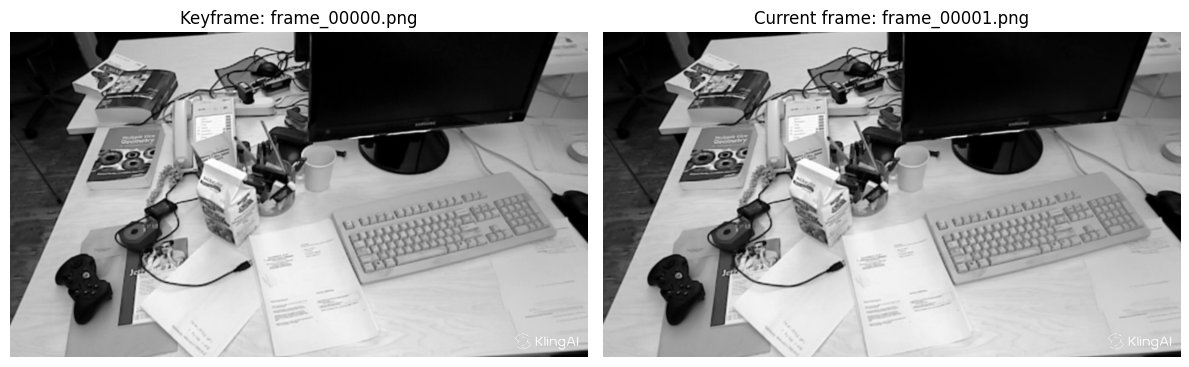

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title(f"Keyframe: {keyframe_image_path.name}")


axes[1].imshow(current_image, cmap="gray")
axes[1].set_title(f"Current frame: {current_image_path.name}")


for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


## Initial pose and optimization updates

Dans la cellule suivante, `pose_solver` est cree avec `cam`.
Donc les intrinseques utilisees pour l'estimation de pose sont bien celles affichees juste au-dessus.


In [59]:
pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(cam, show_debug=False)

print("Proof before optimization:")
print("  pose_solver.camera is cam ->", pose_solver.camera is cam)
print("  pose_solver.camera.fx[0] =", pose_solver.camera.fx[0])
print("  pose_solver.camera.fy[0] =", pose_solver.camera.fy[0])
print("  pose_solver.camera.cx[0] =", pose_solver.camera.cx[0])
print("  pose_solver.camera.cy[0] =", pose_solver.camera.cy[0])
print()
print("Reference level-0 intrinsics that should match:")
print(intrinsics_used_lvl0)
print()

initial_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
initial_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
initial_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Initial photometric errors before optimization:")
print("  level 4 =", initial_error_lvl4)
print("  level 3 =", initial_error_lvl3)
print("  level 2 =", initial_error_lvl2)


Proof before optimization:
  pose_solver.camera is cam -> True
  pose_solver.camera.fx[0] = 525.0
  pose_solver.camera.fy[0] = 525.0
  pose_solver.camera.cx[0] = 319.5
  pose_solver.camera.cy[0] = 239.5

Reference level-0 intrinsics that should match:
{'width': 640, 'height': 480, 'fx': 525.0, 'fy': 525.0, 'cx': 319.5, 'cy': 239.5}

Initial photometric errors before optimization:
  level 4 = 62.40405014464803
  level 3 = 44.878215342590515
  level 2 = 46.04406203759508


**optPose(...)** performs several updates:

- it computes an error
- it locally linearizes the problem
- it computes a pose increment
- it accepts or rejects this update depending on the error improvement

At the end, **current_frame.pose** contains the estimated extrinsic matrix of the current frame relative to the keyframe.


In [60]:
pose_solver.optPose(current_frame, keyframe)

final_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
final_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
final_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Final photometric errors after optimization:")
print("  level 4 =", final_error_lvl4)
print("  level 3 =", final_error_lvl3)
print("  level 2 =", final_error_lvl2)


lvl:  4  initial error:  62.40405014464803
 error improvement too small, level converged! it:  9  error:  50.53748358124773  lambda:  0.0
lvl:  3  initial error:  51.259715348630166
 error improvement too small, level converged! it:  3  error:  41.44342136363349  lambda:  12.8
lvl:  2  initial error:  42.511807627720245
 error improvement too small, level converged! it:  8  error:  38.6818893977534  lambda:  109951162777.6
Final photometric errors after optimization:
  level 4 = 54.24278448435919
  level 3 = 41.002110410443926
  level 2 = 38.6818893977534


### Sanity check on pose estimation

Ici on verifie que le resultat a du sens :
- les erreurs photometriques doivent baisser apres optimisation
- la pose finale doit contenir des valeurs finies
- on veut aussi garder une trace interpretable du gain obtenu a chaque niveau.

In [61]:
optimization_summary = {
    "lvl4_initial": float(initial_error_lvl4),
    "lvl4_final": float(final_error_lvl4),
    "lvl3_initial": float(initial_error_lvl3),
    "lvl3_final": float(final_error_lvl3),
    "lvl2_initial": float(initial_error_lvl2),
    "lvl2_final": float(final_error_lvl2),
}

error_improvement = {
    "lvl4": float(initial_error_lvl4 - final_error_lvl4),
    "lvl3": float(initial_error_lvl3 - final_error_lvl3),
    "lvl2": float(initial_error_lvl2 - final_error_lvl2),
}

print("Optimization summary:")
for lvl in [4, 3, 2]:
    initial_value = optimization_summary[f"lvl{lvl}_initial"]
    final_value = optimization_summary[f"lvl{lvl}_final"]
    improvement = error_improvement[f"lvl{lvl}"]
    print(f"  level {lvl}: initial={initial_value:.6f}, final={final_value:.6f}, improvement={improvement:.6f}")

pose_matrix_now = current_frame.pose.as_matrix()
pose_is_finite = bool(np.isfinite(pose_matrix_now).all())
errors_improved = {lvl: (error_improvement[f"lvl{lvl}"] > 0.0) for lvl in [4, 3, 2]}

print()
print("Pose matrix finite ->", pose_is_finite)
print("Errors improved by level ->", errors_improved)

assert pose_is_finite, "Pose matrix contains non-finite values."
assert all(errors_improved.values()), "At least one pyramid level did not improve after optimization."

print()
print("Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.")


Optimization summary:
  level 4: initial=62.404050, final=54.242784, improvement=8.161266
  level 3: initial=44.878215, final=41.002110, improvement=3.876105
  level 2: initial=46.044062, final=38.681889, improvement=7.362173

Pose matrix finite -> True
Errors improved by level -> {4: True, 3: True, 2: True}

Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.


### Output matrix: the final extrinsic matrix

This is the most important output of the notebook.

This 4x4 matrix represents the estimated relative pose of the current image with respect to the keyframe.

In block form:

$$
T =
\begin{bmatrix}
R & t \\
0 & 1
\end{bmatrix}
$$


In [62]:
extrinsic_matrix = show_pose_matrix(
    f"Extrinsic matrix for {current_image_path.name} relative to {keyframe_image_path.name}:",
    current_frame.pose,
)


Extrinsic matrix for frame_00001.png relative to frame_00000.png:
[[ 1.       -0.000101 -0.000499  0.018891]
 [ 0.000102  1.        0.000206  0.006115]
 [ 0.000499 -0.000206  1.       -0.062383]
 [ 0.        0.        0.        1.      ]]


--
Comparaison avec le GT

In [63]:
GT_Pose = np.array([
    [0.999994773, -0.001180835, -0.002703893, -0.017635176],
    [0.001167188,  0.999986898, -0.005040318, -0.021989598],
    [0.002709795,  0.005037578,  0.999983107,  0.000817620],
    [0.0,          0.0,          0.0,          1.0],
], dtype=np.float64)


Difference = extrinsic_matrix - GT_Pose
A = np.round(Difference, 2)  # 1 chiffre après la virgule

print(A)

[[ 0.    0.    0.    0.04]
 [-0.    0.    0.01  0.03]
 [-0.   -0.01  0.   -0.06]
 [ 0.    0.    0.    0.  ]]


----------- 

## Evaluation

On garde maintenant **une seule metrique** : la **photometric error**.

Definition :
- on reprojecte chaque pixel valide du keyframe dans l image courante
- on compare l intensite du keyframe a l intensite observee apres reprojection
- on prend la difference au carre
- on somme sur tous les pixels valides



In [64]:
def compute_photometric_error(frame, keyframe, cam, lvl=0):
    width = cam.width[lvl]
    height = cam.height[lvl]
    fx = cam.fx[lvl]
    fy = cam.fy[lvl]
    cx = cam.cx[lvl]
    cy = cam.cy[lvl]
    fxinv = cam.fxinv[lvl]
    fyinv = cam.fyinv[lvl]
    cxinv = cam.cxinv[lvl]
    cyinv = cam.cyinv[lvl]

    relativePose = frame.pose.dot(keyframe.pose.inv())

    squared_error_map = np.full((height, width), np.nan, dtype=np.float32)
    valid_mask = np.zeros((height, width), dtype=bool)

    for y in range(height):
        for x in range(width):
            invDepth = keyframe.invDepth[lvl][y, x]
            if invDepth <= 0.0:
                continue

            pointKeyframe = np.array([fxinv * x + cxinv, fyinv * y + cyinv, 1.0]) / invDepth
            pointFrame = relativePose.dot(pointKeyframe)

            if pointFrame[2] <= 0.0:
                continue

            pixelFrame = np.array([
                fx * pointFrame[0] / pointFrame[2] + cx,
                fy * pointFrame[1] / pointFrame[2] + cy,
            ])
            if pixelFrame[0] < 1.0 or pixelFrame[0] >= width - 1 or pixelFrame[1] < 1.0 or pixelFrame[1] >= height - 1:
                continue

            key_intensity = float(keyframe.image[lvl][y, x])
            observed_intensity = float(common.getSubPixelValue(frame.image[lvl], pixelFrame))
            squared_error = (key_intensity - observed_intensity) ** 2

            squared_error_map[y, x] = squared_error
            valid_mask[y, x] = True

    photometric_error = float(np.nansum(squared_error_map[valid_mask]))

    return {
        "photometric_error": photometric_error,
        "squared_error_map": squared_error_map,
        "valid_mask": valid_mask,
        "level": lvl,
    }


In [65]:
evaluation = compute_photometric_error(current_frame, keyframe, cam, lvl=0)

In [66]:
photometric_error = evaluation["photometric_error"]

print("Photometric error =", photometric_error)


Photometric error = 5226812.5


In [67]:
abs_error_map = np.sqrt(evaluation["squared_error_map"])
valid_mask = evaluation["valid_mask"]

valid_abs_errors = abs_error_map[valid_mask]

total_valid_pixels = int(valid_abs_errors.size)
num_gt_200 = int(np.sum(valid_abs_errors > 200))
num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))





num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))








print("Pixel count by absolute difference range:")
print("  total valid pixels       =", total_valid_pixels)
print("  difference > 200         =", num_gt_200)
print("  150 <= difference <= 200 =", num_150_200)
print("  100 <= difference < 150  =", num_100_150)
print("   50 <= difference < 100  =", num_50_100)
print("   30 <= difference < 50   =", num_30_50)
print("   10 <= difference < 30   =", num_10_30)
print("    0 <= difference < 10   =", num_0_10)


Pixel count by absolute difference range:
  total valid pixels       = 293190
  difference > 200         = 0
  150 <= difference <= 200 = 0
  100 <= difference < 150  = 4
   50 <= difference < 100  = 149
   30 <= difference < 50   = 574
   10 <= difference < 30   = 9258
    0 <= difference < 10   = 283205


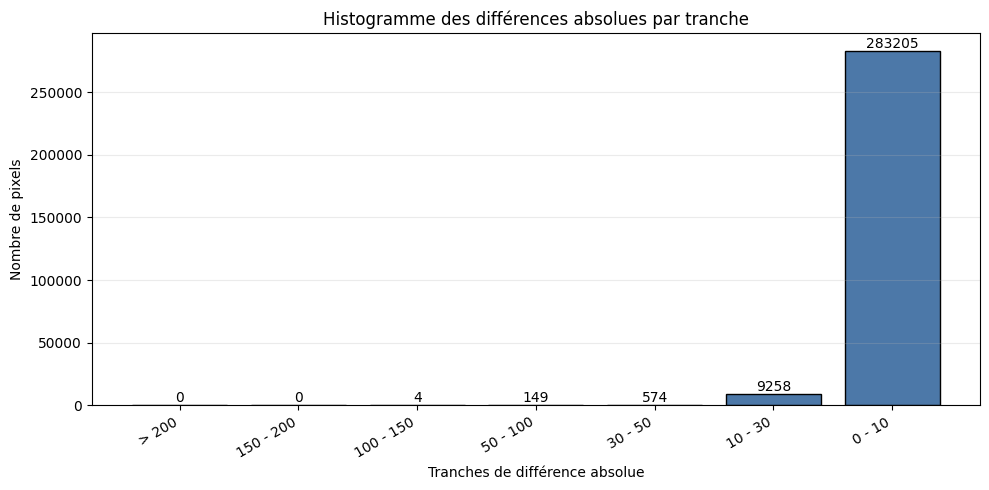

In [68]:
range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

range_counts = [
    num_gt_200,
    num_150_200,
    num_100_150,
    num_50_100,
    num_30_50,
    num_10_30,
    num_0_10,
]

plt.figure(figsize=(10, 5))
bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
plt.title("Histogramme des différences absolues par tranche")
plt.xlabel("Tranches de différence absolue")
plt.ylabel("Nombre de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, count in zip(bars, range_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


### Squared photometric error map

Cette figure n ajoute pas une nouvelle metrique.
Elle sert seulement a voir **ou** l erreur photometrique se concentre dans l image.


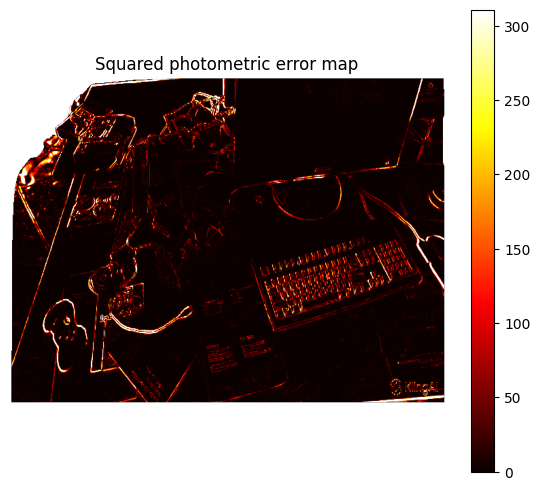

In [69]:
squared_error_map = evaluation["squared_error_map"]
valid_mask = evaluation["valid_mask"]

valid_values = squared_error_map[valid_mask]
vmax_sq = float(np.nanpercentile(valid_values, 99)) if valid_values.size > 0 else 1.0

plt.figure(figsize=(7, 6))
plt.imshow(squared_error_map, cmap="hot", vmin=0, vmax=vmax_sq)
plt.title("Squared photometric error map")
plt.axis("off")
plt.colorbar()
plt.show()


In [70]:
print("Only evaluation metric used in this notebook:")
print("  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels")


Only evaluation metric used in this notebook:
  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels


------
## Scale sur toutes les images

In [71]:
#nombre de frames dans le dossier 
nombre = len(fake_frame_paths)
print("Nombre de frames dans le dossier :", nombre)

Nombre de frames dans le dossier : 121


In [72]:
print(fake_frame_paths[0])

C:\Users\conqu\Videos\Detection_Deep_Fake\Répo_1st_test\Implémentaiton_1\dataset\ai\TUM_fake_frames\frame_00000.png


Sequence fake:
  source size = 1280 x 720
  working size level-0 = 640 x 480
  fx level-0 = 525.0
  fy level-0 = 525.0

[fake] frame 0 -> keyframe de reference: frame_00000.png
lvl:  4  initial error:  62.40405014464803
 error improvement too small, level converged! it:  9  error:  50.53748358124773  lambda:  0.0
lvl:  3  initial error:  51.259715348630166
 error improvement too small, level converged! it:  3  error:  41.44342136363349  lambda:  12.8
lvl:  2  initial error:  42.511807627720245
 error improvement too small, level converged! it:  8  error:  38.6818893977534  lambda:  109951162777.6
[fake] frame 1 -> frame_00001.png | sum error = 5226812.50 | mean abs error = 1.8675 | valid pixels = 293190


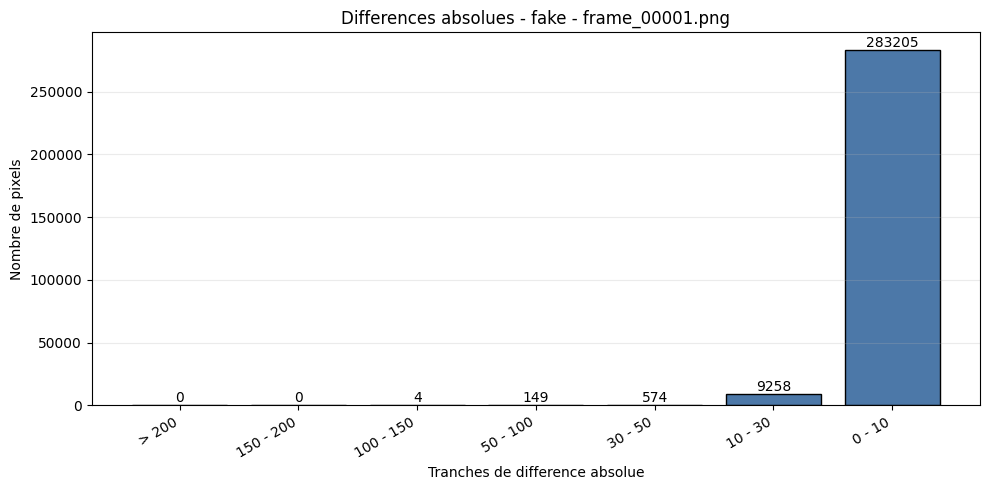

lvl:  4  initial error:  182.92864030858237
 error improvement too small, level converged! it:  5  error:  132.42958031066732  lambda:  0.4
lvl:  3  initial error:  135.88786199525762
 error improvement too small, level converged! it:  4  error:  123.32019094970742  lambda:  0.0
lvl:  2  initial error:  106.04959690342844
 error improvement too small, level converged! it:  2  error:  100.48242247919681  lambda:  0.1
[fake] frame 2 -> frame_00002.png | sum error = 12055114.00 | mean abs error = 2.8916 | valid pixels = 289594


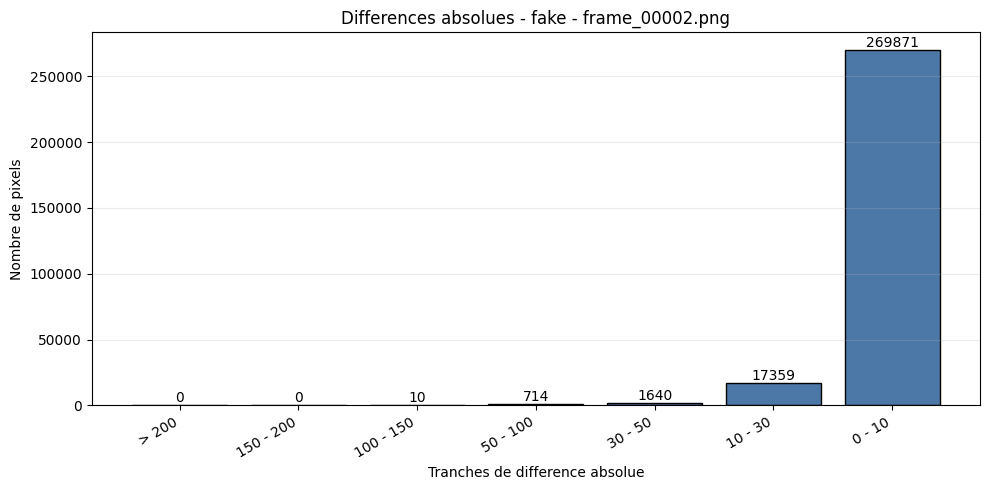

lvl:  4  initial error:  326.0057859209255
 error improvement too small, level converged! it:  5  error:  225.17025541088174  lambda:  0.1
lvl:  3  initial error:  233.62442418831805
 error improvement too small, level converged! it:  3  error:  216.19354756427114  lambda:  0.0
lvl:  2  initial error:  163.42030753445624
 error improvement too small, level converged! it:  2  error:  156.03637213298623  lambda:  0.1
[fake] frame 3 -> frame_00003.png | sum error = 21317232.00 | mean abs error = 3.7751 | valid pixels = 287270


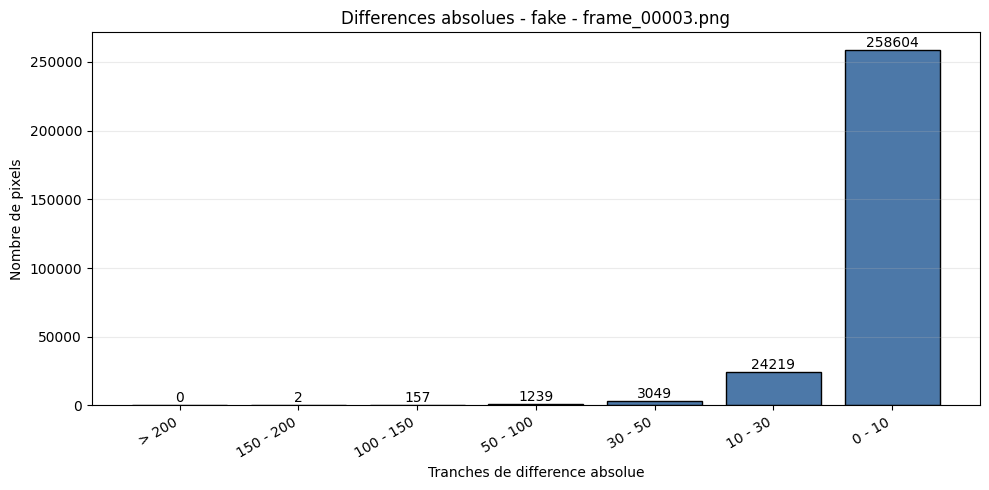

lvl:  4  initial error:  454.0954676952746
 error improvement too small, level converged! it:  4  error:  319.4222180322754  lambda:  0.1
lvl:  3  initial error:  307.11049677233717
 error improvement too small, level converged! it:  3  error:  280.5545066744513  lambda:  0.0
lvl:  2  initial error:  193.77887582812923
 error improvement too small, level converged! it:  2  error:  187.80428753158253  lambda:  0.4
[fake] frame 4 -> frame_00004.png | sum error = 30354392.00 | mean abs error = 4.4684 | valid pixels = 285077


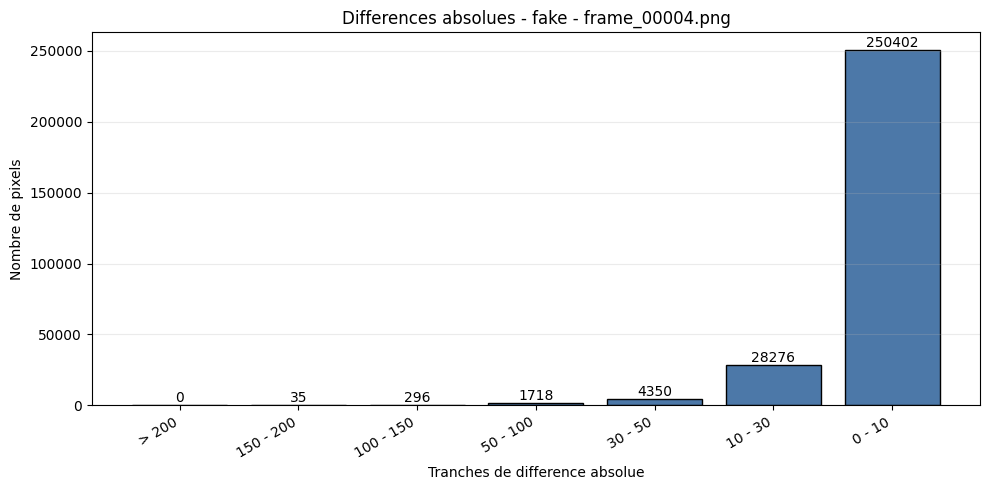

lvl:  4  initial error:  591.0800385728057
 error improvement too small, level converged! it:  3  error:  440.9599398194279  lambda:  0.0
lvl:  3  initial error:  374.6067186144675
 error improvement too small, level converged! it:  3  error:  337.83284270763954  lambda:  219902325555.2
lvl:  2  initial error:  224.4668025843539
 error improvement too small, level converged! it:  5  error:  215.00918442732666  lambda:  0.0
[fake] frame 5 -> frame_00005.png | sum error = 41248480.00 | mean abs error = 5.2584 | valid pixels = 282566


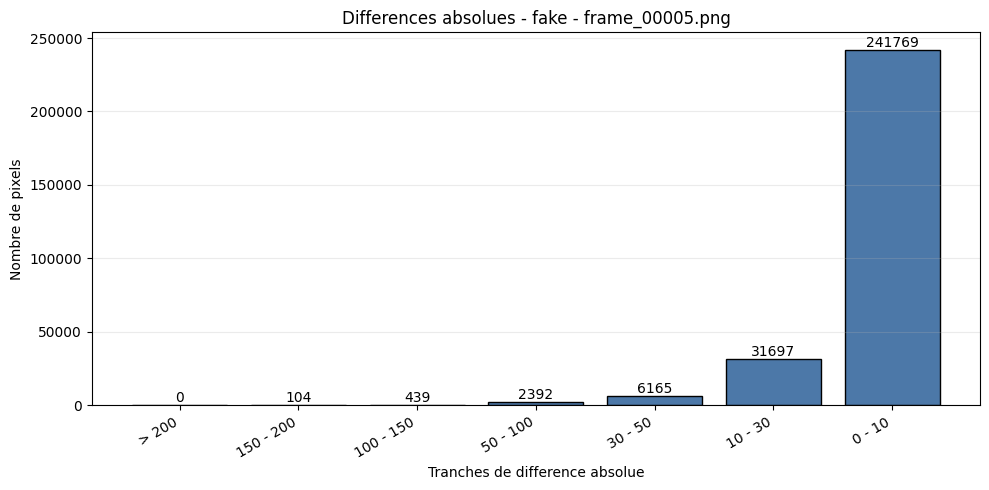

lvl:  4  initial error:  715.6113789778201
update too small, level converged! it:  3  error:  537.4009609477605  lambda:  450359962737049.6
lvl:  3  initial error:  401.5961097996457
 error improvement too small, level converged! it:  3  error:  374.15428641699714  lambda:  439804651110.4
lvl:  2  initial error:  246.7110204206688
 error improvement too small, level converged! it:  6  error:  230.6462645803609  lambda:  1759218604441.6
[fake] frame 6 -> frame_00006.png | sum error = 52860104.00 | mean abs error = 5.9659 | valid pixels = 280296


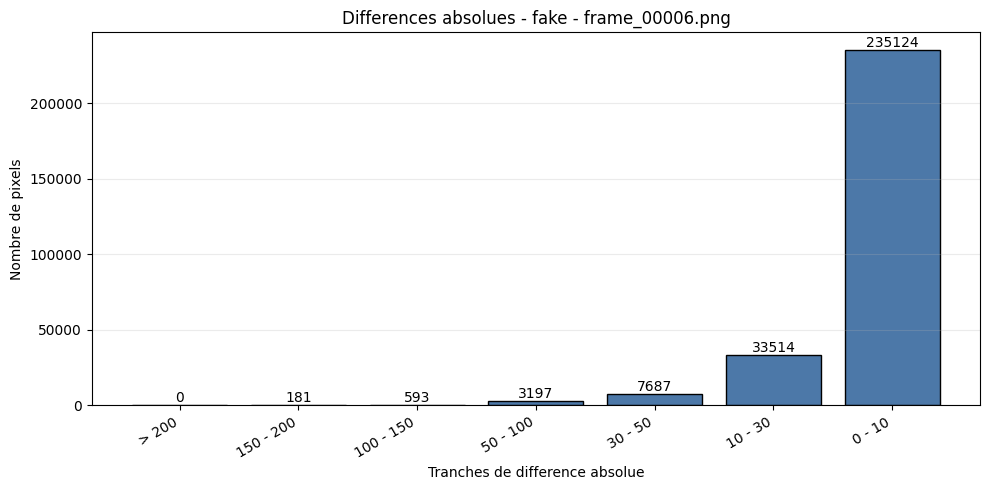

lvl:  4  initial error:  820.2352941176464
 error improvement too small, level converged! it:  3  error:  609.8641117499219  lambda:  0.2
lvl:  3  initial error:  424.4749878318257
 error improvement too small, level converged! it:  3  error:  395.0194844260466  lambda:  1.6
lvl:  2  initial error:  258.5232683854687
 error improvement too small, level converged! it:  4  error:  243.23543386445272  lambda:  0.1
[fake] frame 7 -> frame_00007.png | sum error = 63416204.00 | mean abs error = 6.4834 | valid pixels = 278568


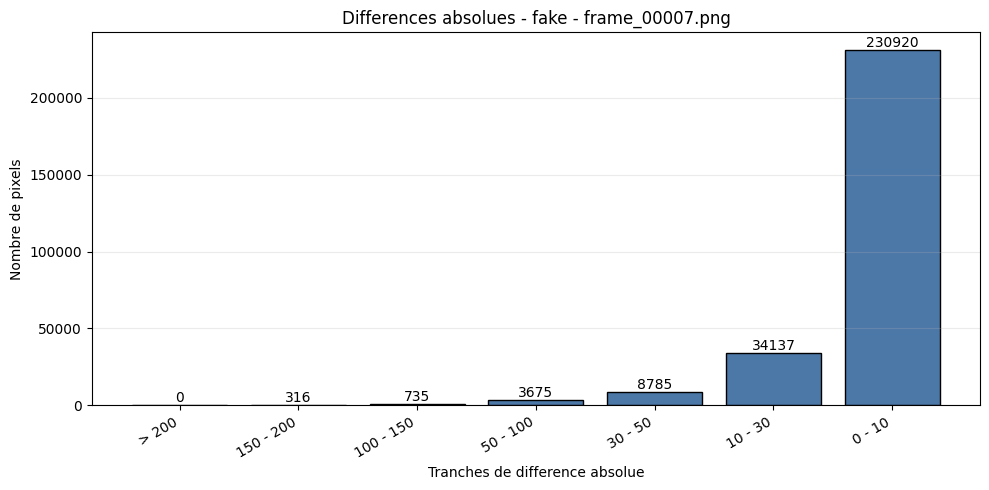

lvl:  4  initial error:  931.9363548698161
update too small, level converged! it:  4  error:  666.6672639833287  lambda:  112589990684262.4
lvl:  3  initial error:  434.61928193929447
 error improvement too small, level converged! it:  2  error:  412.0006248625585  lambda:  0.1
lvl:  2  initial error:  278.3082621009901
 error improvement too small, level converged! it:  4  error:  268.4351805288114  lambda:  0.0
[fake] frame 8 -> frame_00008.png | sum error = 73219296.00 | mean abs error = 7.0577 | valid pixels = 276831


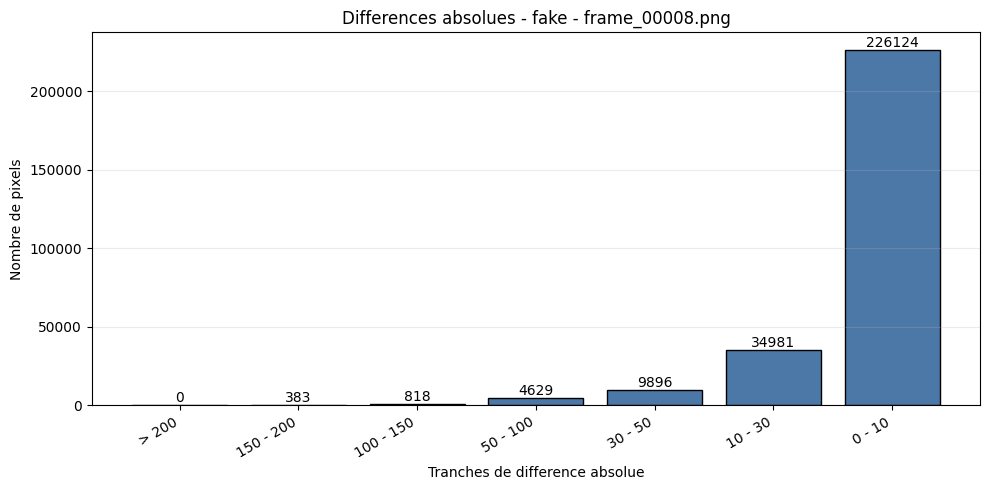

lvl:  4  initial error:  1075.704918032786
update too small, level converged! it:  4  error:  713.5867245663538  lambda:  225179981368524.8
lvl:  3  initial error:  477.0613829558059
 error improvement too small, level converged! it:  6  error:  427.8004732059058  lambda:  0.0
lvl:  2  initial error:  308.80875002151987
 error improvement too small, level converged! it:  5  error:  298.24622492086274  lambda:  0.0
[fake] frame 9 -> frame_00009.png | sum error = 82880272.00 | mean abs error = 7.6230 | valid pixels = 274815


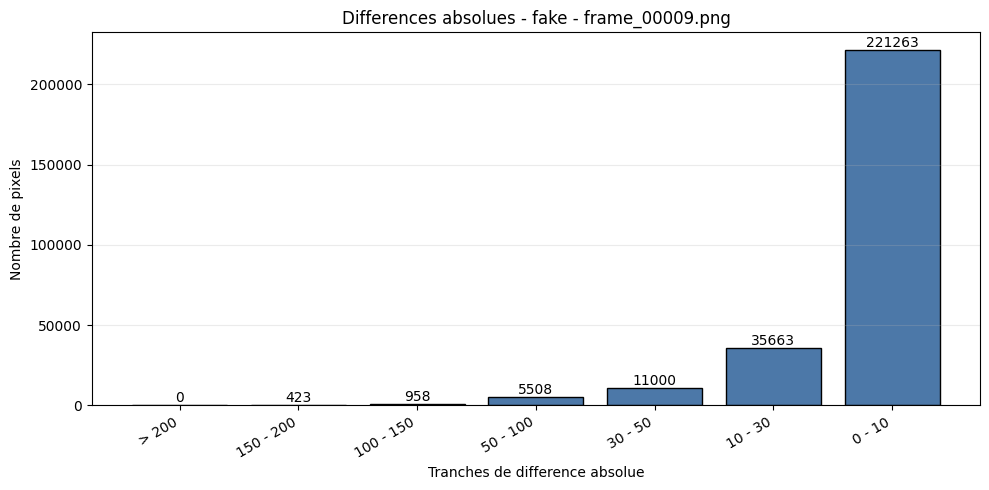

lvl:  4  initial error:  1213.14175506268
 error improvement too small, level converged! it:  4  error:  738.0855000268732  lambda:  28147497671065.6
lvl:  3  initial error:  493.63780880918415
 error improvement too small, level converged! it:  3  error:  445.6863256521143  lambda:  0.0
lvl:  2  initial error:  322.7784972288515
 error improvement too small, level converged! it:  2  error:  320.43834248287453  lambda:  0.1
[fake] frame 10 -> frame_00010.png | sum error = 90499888.00 | mean abs error = 7.9762 | valid pixels = 272742


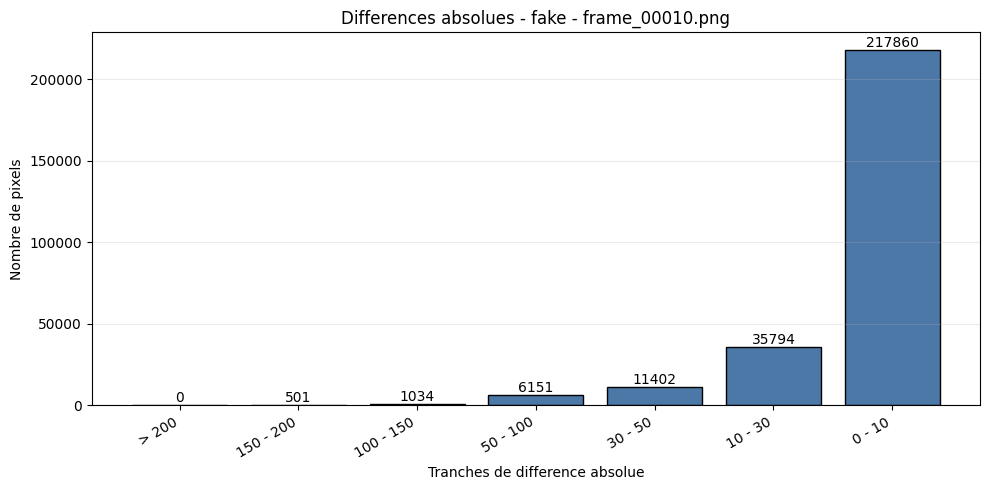

lvl:  4  initial error:  1320.5998071359681
 error improvement too small, level converged! it:  4  error:  756.526666084134  lambda:  225179981368524.8
lvl:  3  initial error:  501.7124296207892
 error improvement too small, level converged! it:  4  error:  455.14534345782954  lambda:  0.0
lvl:  2  initial error:  346.44397294546576
 error improvement too small, level converged! it:  1  error:  346.43324966274264  lambda:  25.6
[fake] frame 11 -> frame_00011.png | sum error = 98462928.00 | mean abs error = 8.3339 | valid pixels = 270066


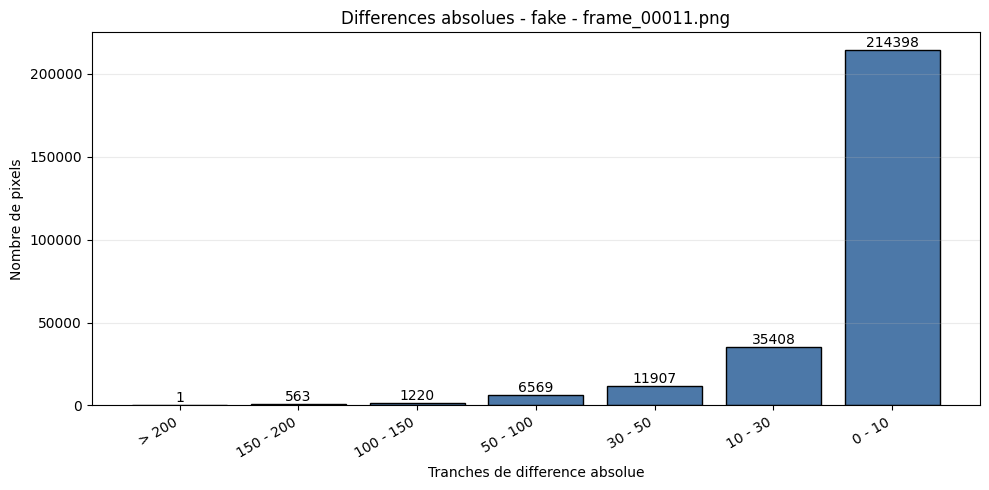

lvl:  4  initial error:  1391.594985535197
 error improvement too small, level converged! it:  6  error:  768.0098936504712  lambda:  0.0
lvl:  3  initial error:  537.5972348062005
 error improvement too small, level converged! it:  5  error:  467.77178958430727  lambda:  0.0
lvl:  2  initial error:  369.0598579915173
 error improvement too small, level converged! it:  4  error:  351.2466351606637  lambda:  0.0
[fake] frame 12 -> frame_00012.png | sum error = 107023624.00 | mean abs error = 8.8939 | valid pixels = 269303


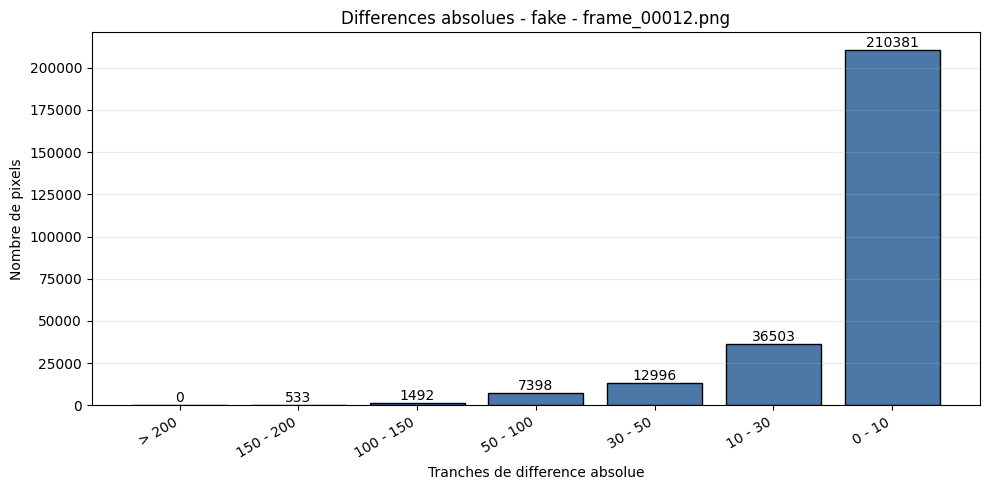

lvl:  4  initial error:  1470.7936354869812
 error improvement too small, level converged! it:  4  error:  781.1325228329968  lambda:  3518437208883.2
lvl:  3  initial error:  534.4859078725735
 error improvement too small, level converged! it:  4  error:  476.8546556741407  lambda:  0.0
lvl:  2  initial error:  397.1634165823614
update too small, level converged! it:  2  error:  377.67968488493096  lambda:  112589990684262.4
[fake] frame 13 -> frame_00013.png | sum error = 115761384.00 | mean abs error = 9.3090 | valid pixels = 267861


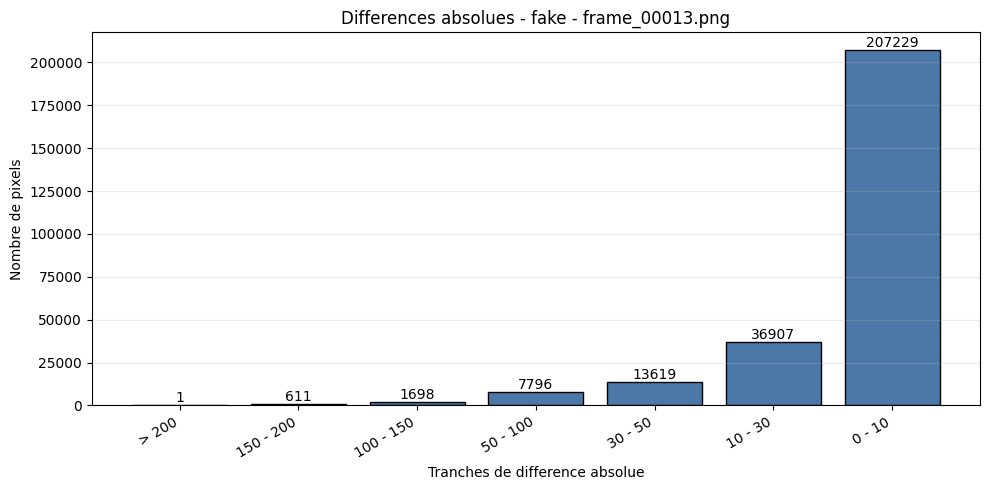

lvl:  4  initial error:  1565.502410800385
 error improvement too small, level converged! it:  4  error:  820.0981095632701  lambda:  12.8
lvl:  3  initial error:  576.5414408187183
 error improvement too small, level converged! it:  4  error:  482.2521383810048  lambda:  0.0
lvl:  2  initial error:  420.82213760108874
 error improvement too small, level converged! it:  3  error:  409.534063512293  lambda:  0.0
[fake] frame 14 -> frame_00014.png | sum error = 125764376.00 | mean abs error = 9.8466 | valid pixels = 266352


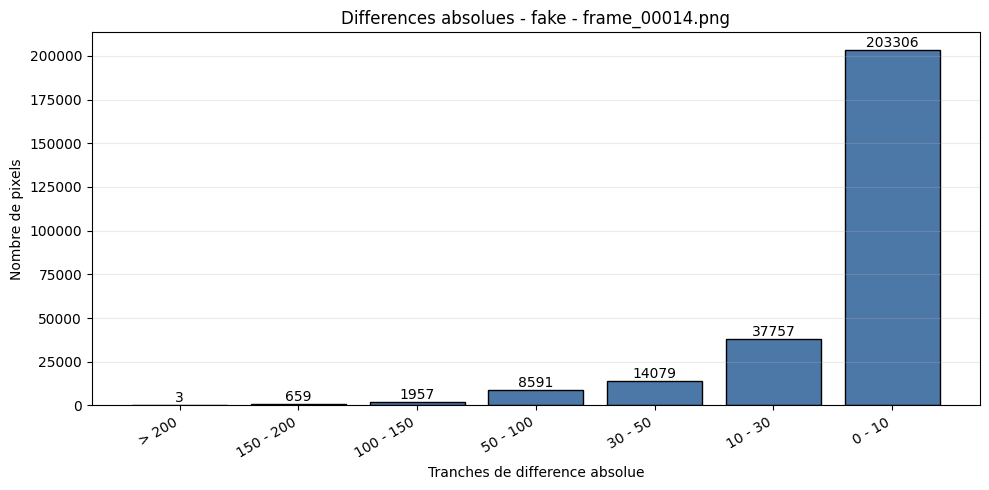

lvl:  4  initial error:  1665.015429122468
 error improvement too small, level converged! it:  4  error:  871.1039139890206  lambda:  1.6
lvl:  3  initial error:  614.4257697359399
 error improvement too small, level converged! it:  5  error:  487.3927287543402  lambda:  879609302220.8
lvl:  2  initial error:  454.58134093423035
update too small, level converged! it:  2  error:  442.98131235793744  lambda:  225179981368524.8
[fake] frame 15 -> frame_00015.png | sum error = 133184144.00 | mean abs error = 10.2007 | valid pixels = 264406


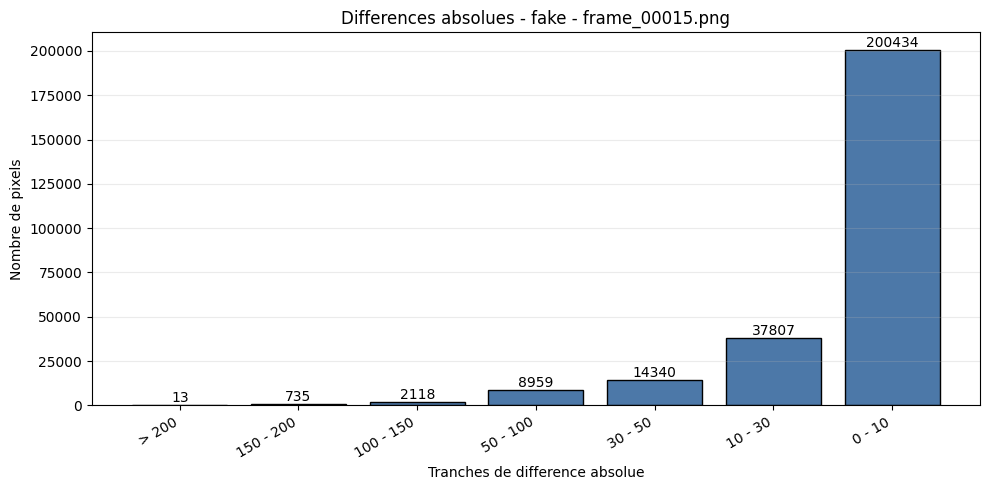

lvl:  4  initial error:  1760.5351976856307
 error improvement too small, level converged! it:  4  error:  879.1332663642722  lambda:  0.8
lvl:  3  initial error:  595.9749712736293
 error improvement too small, level converged! it:  3  error:  507.61948022221566  lambda:  0.0
lvl:  2  initial error:  489.05984897394274
 error improvement too small, level converged! it:  2  error:  483.14768624913626  lambda:  25.6
[fake] frame 16 -> frame_00016.png | sum error = 142466080.00 | mean abs error = 10.6609 | valid pixels = 262390


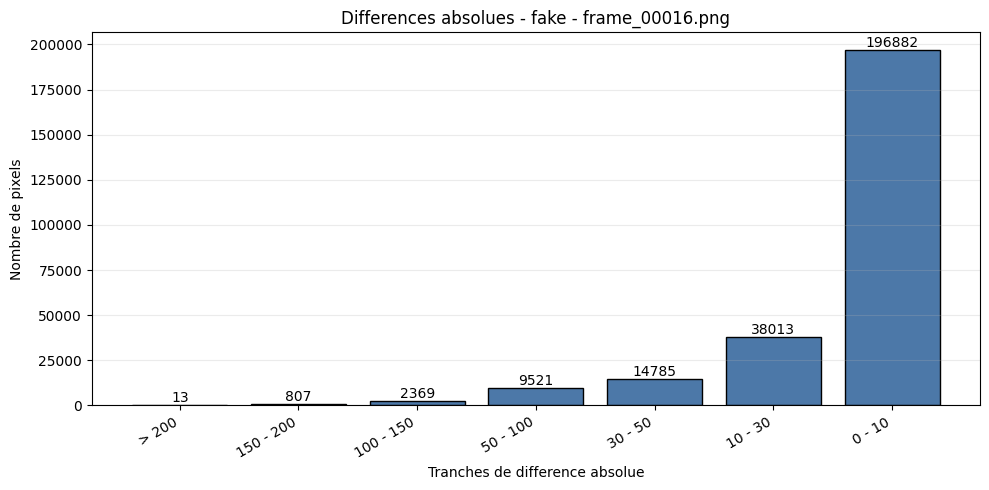

lvl:  4  initial error:  1880.1745419479257
update too small, level converged! it:  4  error:  907.8338918298177  lambda:  900719925474099.2
lvl:  3  initial error:  620.585731620511
 error improvement too small, level converged! it:  3  error:  535.8998198501797  lambda:  0.0
lvl:  2  initial error:  521.8856180621852
 error improvement too small, level converged! it:  2  error:  513.7033797859331  lambda:  219902325555.2
[fake] frame 17 -> frame_00017.png | sum error = 152303408.00 | mean abs error = 11.1814 | valid pixels = 260993


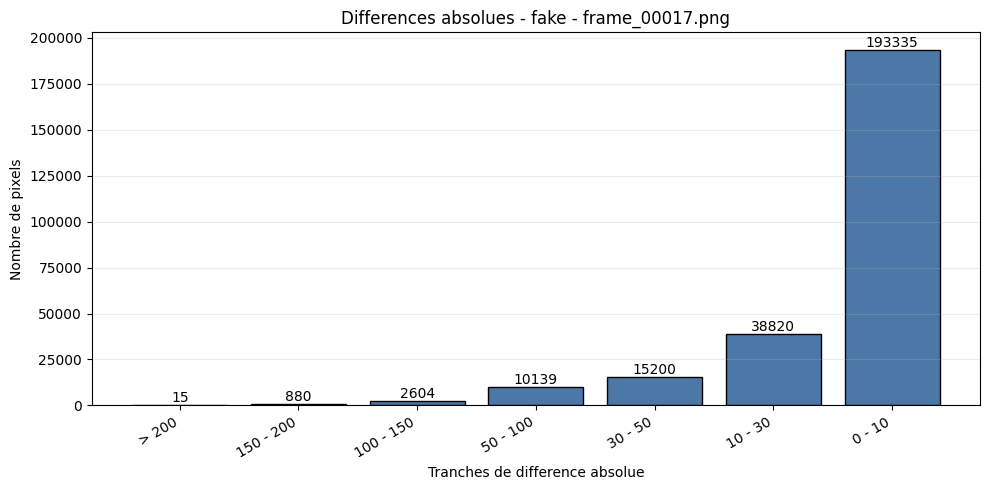

lvl:  4  initial error:  1961.122468659594
update too small, level converged! it:  3  error:  919.0868054886481  lambda:  1801439850948198.5
lvl:  3  initial error:  624.1335396733849
 error improvement too small, level converged! it:  3  error:  565.7526437672092  lambda:  0.0
lvl:  2  initial error:  549.3708412776522
 error improvement too small, level converged! it:  2  error:  536.5114203231668  lambda:  879609302220.8
[fake] frame 18 -> frame_00018.png | sum error = 160718544.00 | mean abs error = 11.5761 | valid pixels = 259418


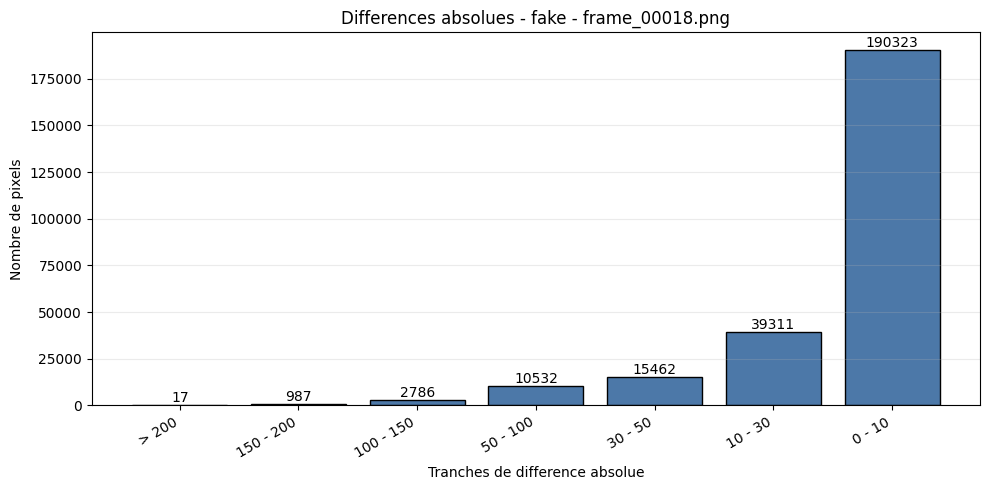

lvl:  4  initial error:  2025.8100289296037
 error improvement too small, level converged! it:  3  error:  926.547732550675  lambda:  0.2
lvl:  3  initial error:  672.801334976525
 error improvement too small, level converged! it:  4  error:  587.1066068681405  lambda:  0.0
lvl:  2  initial error:  578.7631183819266
update too small, level converged! it:  4  error:  558.4624163150754  lambda:  112589990684262.4
[fake] frame 19 -> frame_00019.png | sum error = 167232944.00 | mean abs error = 11.8544 | valid pixels = 257103


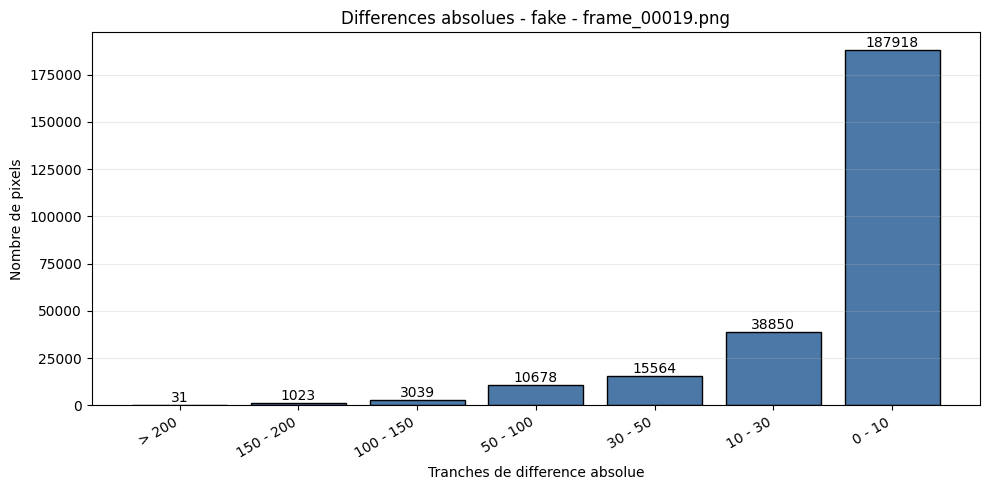

lvl:  4  initial error:  2109.9710703953706
update too small, level converged! it:  4  error:  928.7923079489318  lambda:  450359962737049.6
lvl:  3  initial error:  719.9606097179824
 error improvement too small, level converged! it:  4  error:  609.3770913412602  lambda:  0.0
lvl:  2  initial error:  594.8347185640533
 error improvement too small, level converged! it:  2  error:  575.5948795262591  lambda:  3518437208883.2
[fake] frame 20 -> frame_00020.png | sum error = 173716064.00 | mean abs error = 12.1472 | valid pixels = 255742


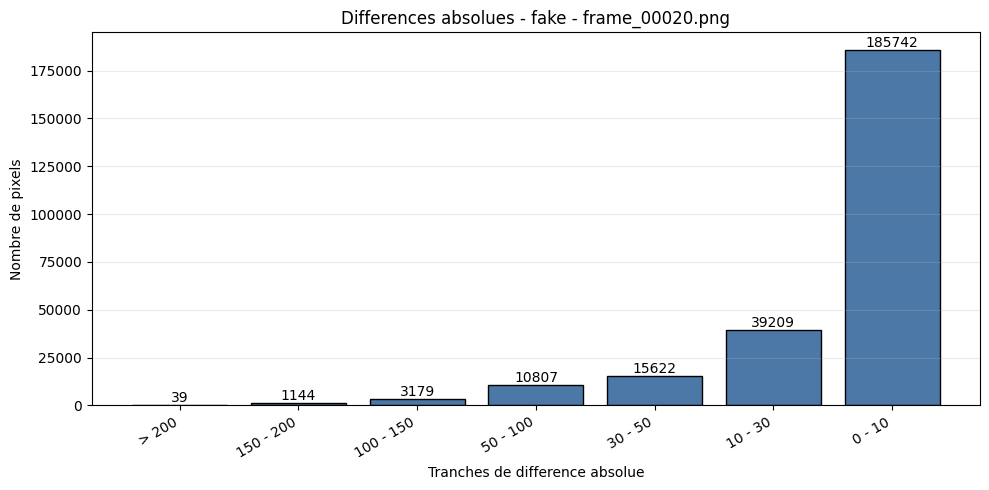

lvl:  4  initial error:  2257.885245901638
 error improvement too small, level converged! it:  4  error:  918.1836131970249  lambda:  1759218604441.6
lvl:  3  initial error:  757.1247213014996
 error improvement too small, level converged! it:  5  error:  615.4298872170504  lambda:  0.0
lvl:  2  initial error:  635.5962164397527
 error improvement too small, level converged! it:  4  error:  610.386151843244  lambda:  0.0
[fake] frame 21 -> frame_00021.png | sum error = 186058000.00 | mean abs error = 12.6969 | valid pixels = 254264


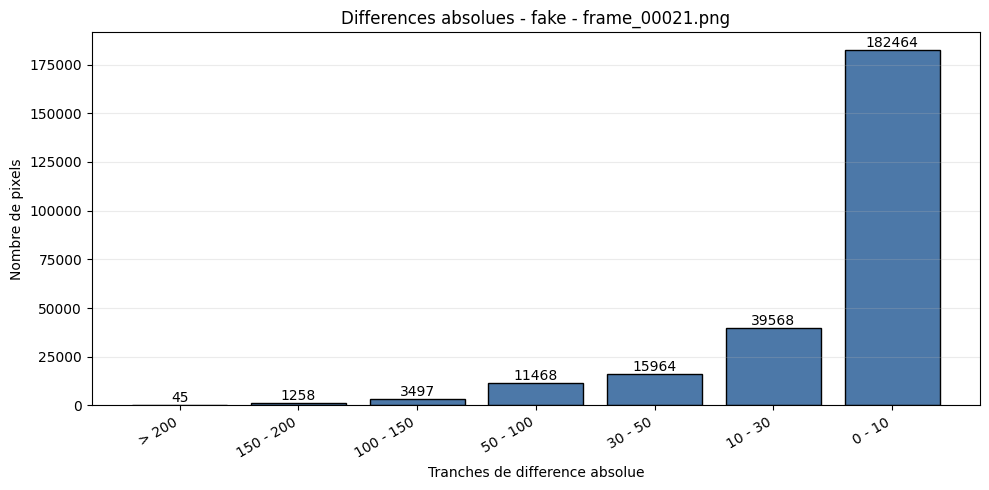

lvl:  4  initial error:  2468.0790742526506
 error improvement too small, level converged! it:  6  error:  868.030245209294  lambda:  0.2
lvl:  3  initial error:  690.14010882916
 error improvement too small, level converged! it:  3  error:  620.1573569185397  lambda:  0.1
lvl:  2  initial error:  694.0213041150772
 error improvement too small, level converged! it:  7  error:  663.0887192572043  lambda:  0.0
[fake] frame 22 -> frame_00022.png | sum error = 197744576.00 | mean abs error = 13.2631 | valid pixels = 252710


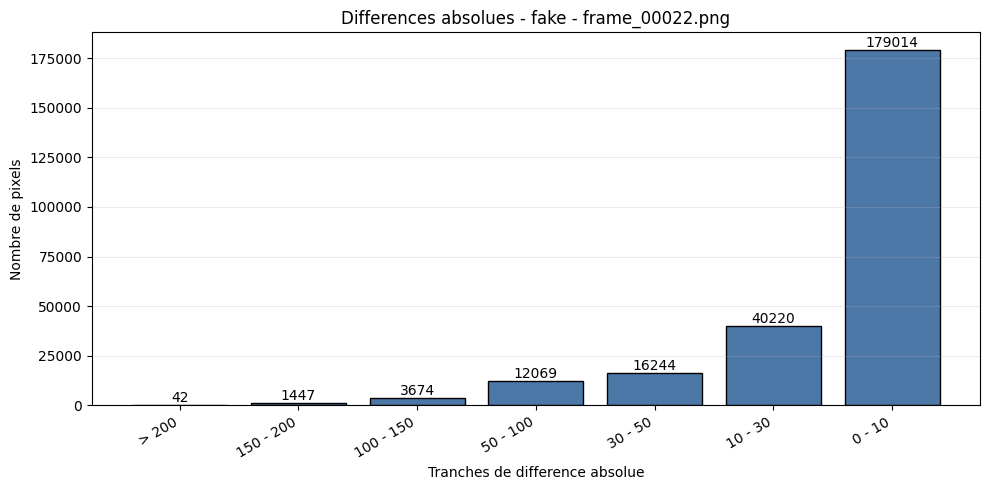

lvl:  4  initial error:  2603.44744455159
 error improvement too small, level converged! it:  4  error:  889.852085247756  lambda:  3.2
lvl:  3  initial error:  700.3026811224456
 error improvement too small, level converged! it:  3  error:  666.5807018347864  lambda:  6.4
lvl:  2  initial error:  728.1438485723835
 error improvement too small, level converged! it:  4  error:  716.4086236810705  lambda:  0.0
[fake] frame 23 -> frame_00023.png | sum error = 208502000.00 | mean abs error = 13.7709 | valid pixels = 251281


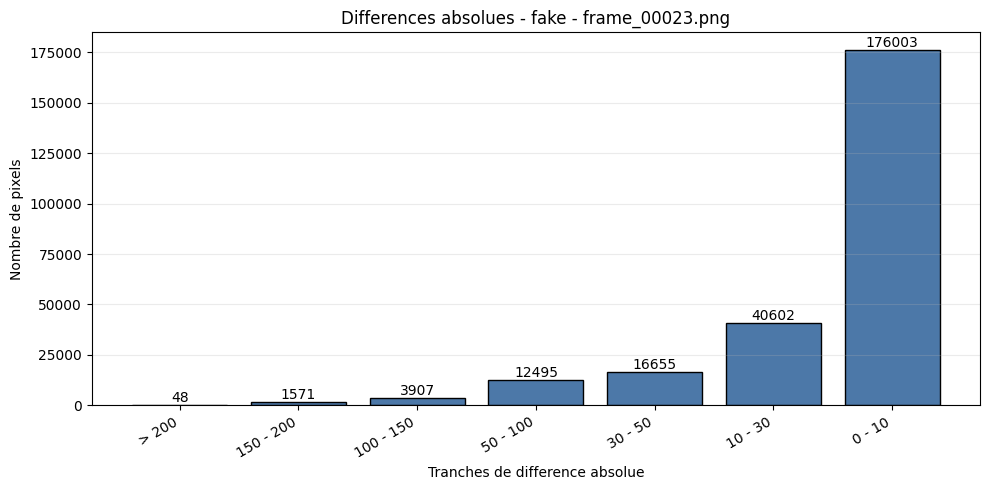

lvl:  4  initial error:  2698.0221793635465
 error improvement too small, level converged! it:  4  error:  928.3261784042849  lambda:  1.6
lvl:  3  initial error:  750.9531101588057
 error improvement too small, level converged! it:  4  error:  708.8380421769389  lambda:  0.0
lvl:  2  initial error:  743.6064735712114
 error improvement too small, level converged! it:  3  error:  727.3215580746673  lambda:  0.0
[fake] frame 24 -> frame_00024.png | sum error = 216644336.00 | mean abs error = 14.1032 | valid pixels = 249469


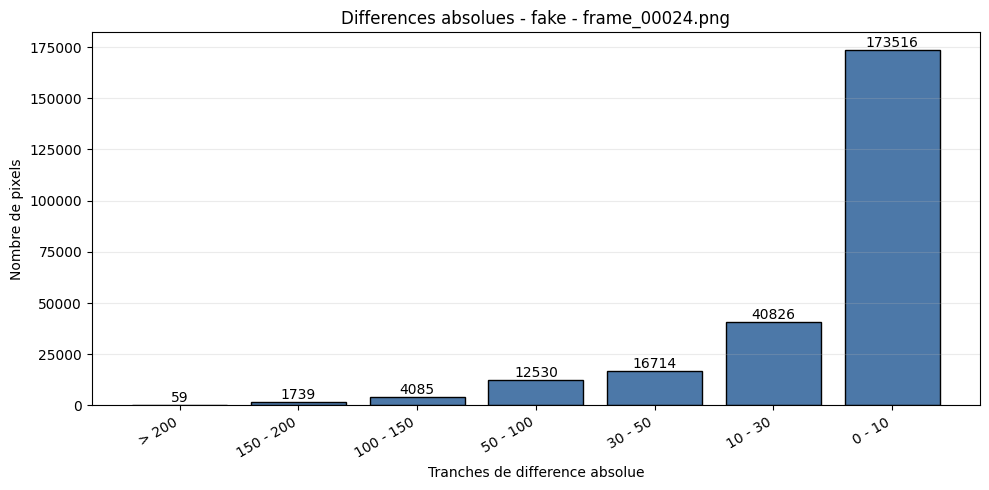

lvl:  4  initial error:  2771.80038572806
update too small, level converged! it:  5  error:  906.5940235290184  lambda:  1801439850948198.5
lvl:  3  initial error:  773.2251934922078
 error improvement too small, level converged! it:  6  error:  737.3513459635734  lambda:  0.0
lvl:  2  initial error:  784.7824825261678
update too small, level converged! it:  4  error:  759.5216792947988  lambda:  56294995342131.2
[fake] frame 25 -> frame_00025.png | sum error = 225646464.00 | mean abs error = 14.5515 | valid pixels = 248454


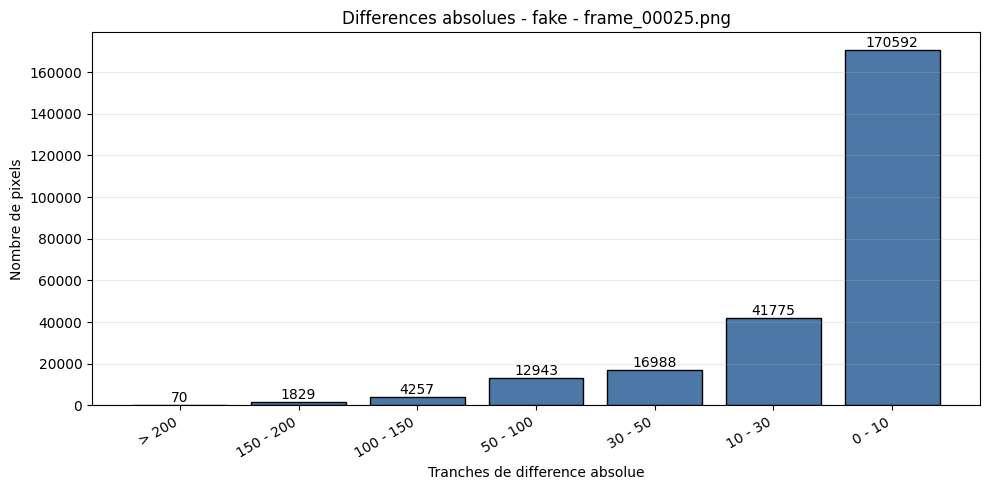

lvl:  4  initial error:  2856.764705882351
 error improvement too small, level converged! it:  5  error:  877.7514244417383  lambda:  12.8
lvl:  3  initial error:  801.2461554901597
 error improvement too small, level converged! it:  5  error:  748.9402104703469  lambda:  0.0
lvl:  2  initial error:  829.2354669524838
 error improvement too small, level converged! it:  5  error:  788.1655368893381  lambda:  0.0
[fake] frame 26 -> frame_00026.png | sum error = 232833920.00 | mean abs error = 14.8886 | valid pixels = 247272


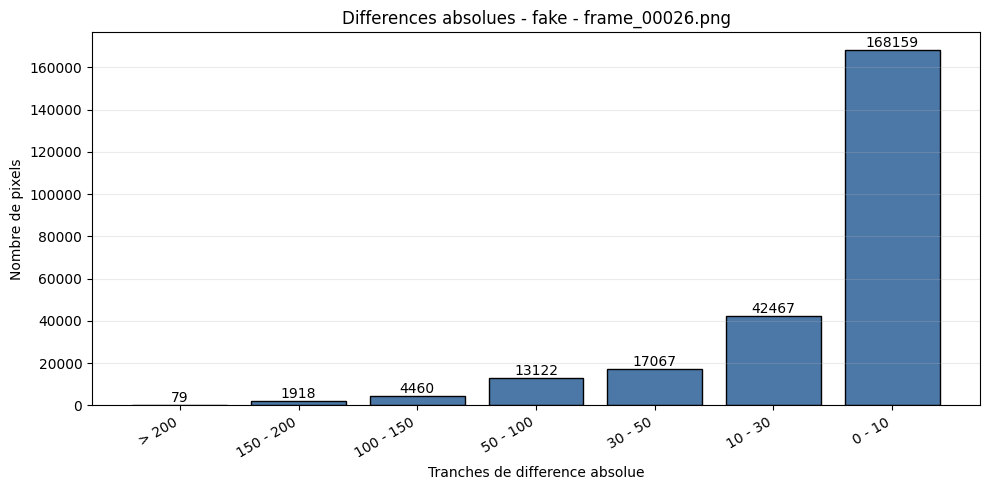

lvl:  4  initial error:  2954.513982642236
 error improvement too small, level converged! it:  4  error:  870.2651978211765  lambda:  0.2
lvl:  3  initial error:  838.3725923499608
 error improvement too small, level converged! it:  6  error:  735.1499255676604  lambda:  439804651110.4
lvl:  2  initial error:  856.8504910005737
 error improvement too small, level converged! it:  4  error:  826.360244724872  lambda:  0.0
[fake] frame 27 -> frame_00027.png | sum error = 241251744.00 | mean abs error = 15.2916 | valid pixels = 245785


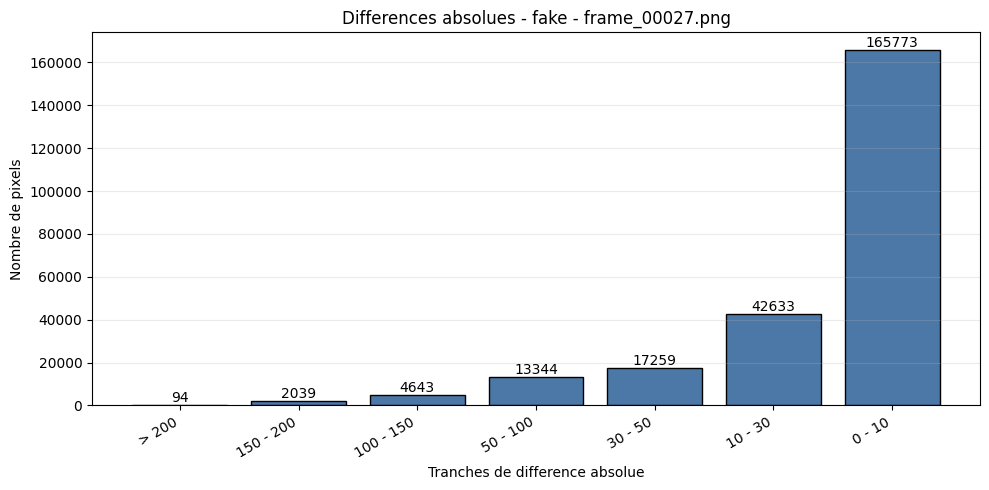

lvl:  4  initial error:  3100.0819672131124
 error improvement too small, level converged! it:  4  error:  877.1857882026408  lambda:  1759218604441.6
lvl:  3  initial error:  825.8791541518369
 error improvement too small, level converged! it:  5  error:  752.2397105091836  lambda:  12.8
lvl:  2  initial error:  897.7473599317444
 error improvement too small, level converged! it:  7  error:  859.8849500716669  lambda:  0.0
[fake] frame 28 -> frame_00028.png | sum error = 250379184.00 | mean abs error = 15.7443 | valid pixels = 245275


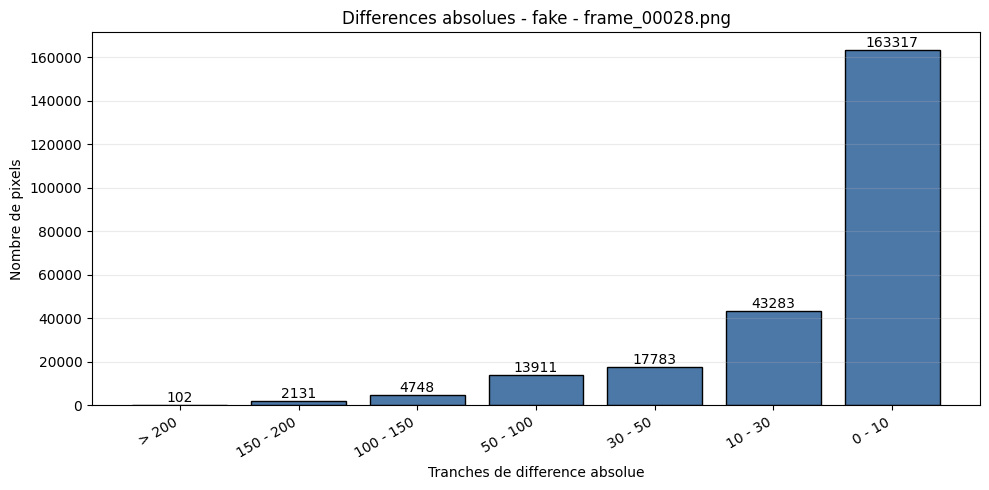

lvl:  4  initial error:  3143.5033751205387
 error improvement too small, level converged! it:  5  error:  918.8426501021663  lambda:  1.6
lvl:  3  initial error:  899.3285049394609
 error improvement too small, level converged! it:  6  error:  787.149905890704  lambda:  0.1
lvl:  2  initial error:  940.6655324042654
 error improvement too small, level converged! it:  6  error:  899.0546908416275  lambda:  0.0
[fake] frame 29 -> frame_00029.png | sum error = 257581936.00 | mean abs error = 16.1245 | valid pixels = 244531


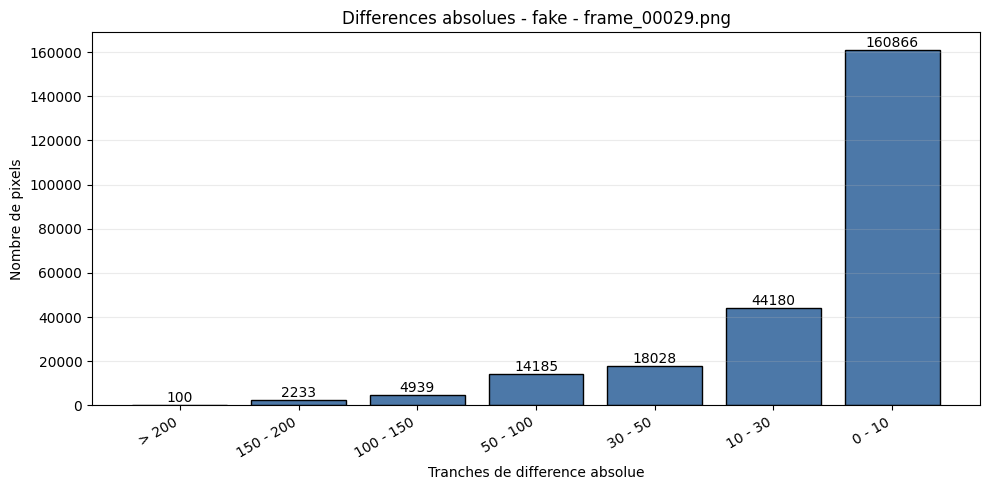

lvl:  4  initial error:  3204.722275795563
 error improvement too small, level converged! it:  4  error:  996.7671250212802  lambda:  56294995342131.2
lvl:  3  initial error:  929.1011501776084
 error improvement too small, level converged! it:  4  error:  821.3207619579252  lambda:  0.0
lvl:  2  initial error:  972.8059231500334
 error improvement too small, level converged! it:  6  error:  927.242383399025  lambda:  0.0
[fake] frame 30 -> frame_00030.png | sum error = 265118160.00 | mean abs error = 16.4752 | valid pixels = 243007


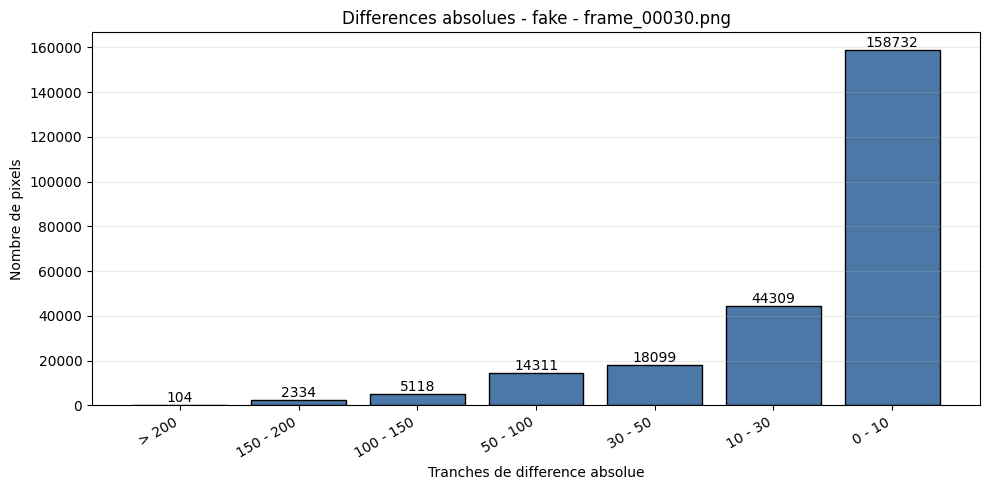

lvl:  4  initial error:  3250.945998071358
 error improvement too small, level converged! it:  3  error:  1061.7494355383196  lambda:  0.1
lvl:  3  initial error:  969.0214333327519
 error improvement too small, level converged! it:  6  error:  829.1057612195477  lambda:  0.0
lvl:  2  initial error:  1007.2825711483773
 error improvement too small, level converged! it:  5  error:  970.4460465566119  lambda:  0.0
[fake] frame 31 -> frame_00031.png | sum error = 272848736.00 | mean abs error = 16.8279 | valid pixels = 241488


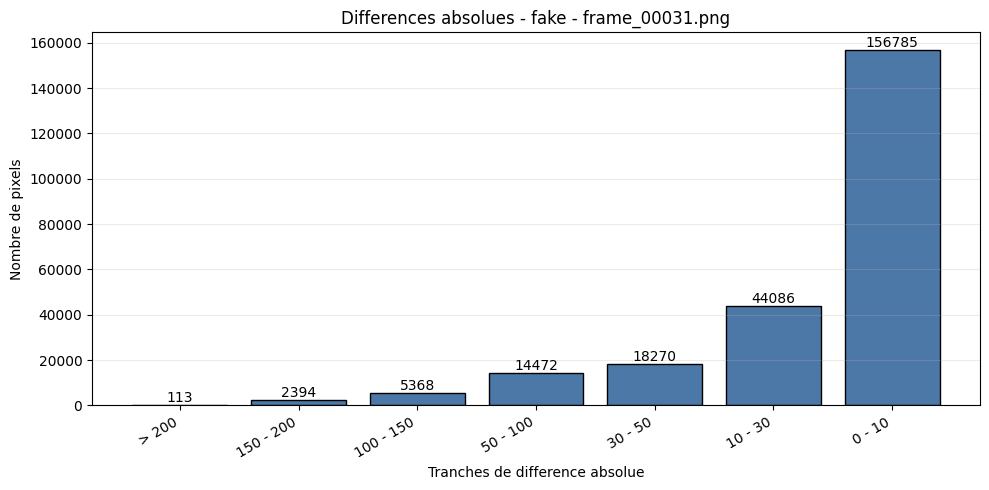

lvl:  4  initial error:  3274.518804243007
update too small, level converged! it:  5  error:  1090.428958964941  lambda:  450359962737049.6
lvl:  3  initial error:  993.0068008829433
 error improvement too small, level converged! it:  6  error:  851.2076050446756  lambda:  0.0
lvl:  2  initial error:  1038.2702813879134
 error improvement too small, level converged! it:  8  error:  1001.3807068244641  lambda:  13743895347.2
[fake] frame 32 -> frame_00032.png | sum error = 279040352.00 | mean abs error = 17.1469 | valid pixels = 240364


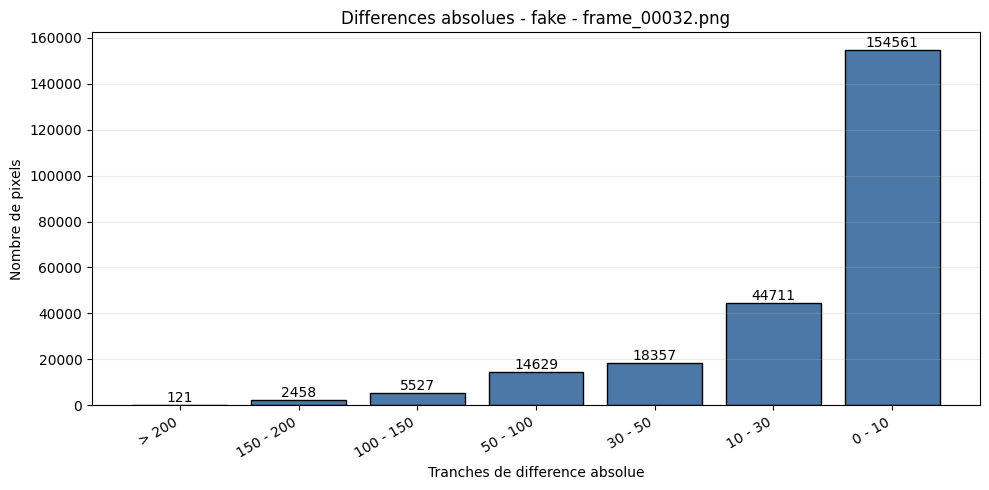

lvl:  4  initial error:  3325.9276759884265
 error improvement too small, level converged! it:  5  error:  1063.7415994314927  lambda:  51.2
lvl:  3  initial error:  960.857191878763
 error improvement too small, level converged! it:  6  error:  886.2271918656262  lambda:  0.0
lvl:  2  initial error:  1064.0251524523203
 error improvement too small, level converged! it:  7  error:  1012.8859100273253  lambda:  0.0
[fake] frame 33 -> frame_00033.png | sum error = 283423040.00 | mean abs error = 17.4022 | valid pixels = 239428


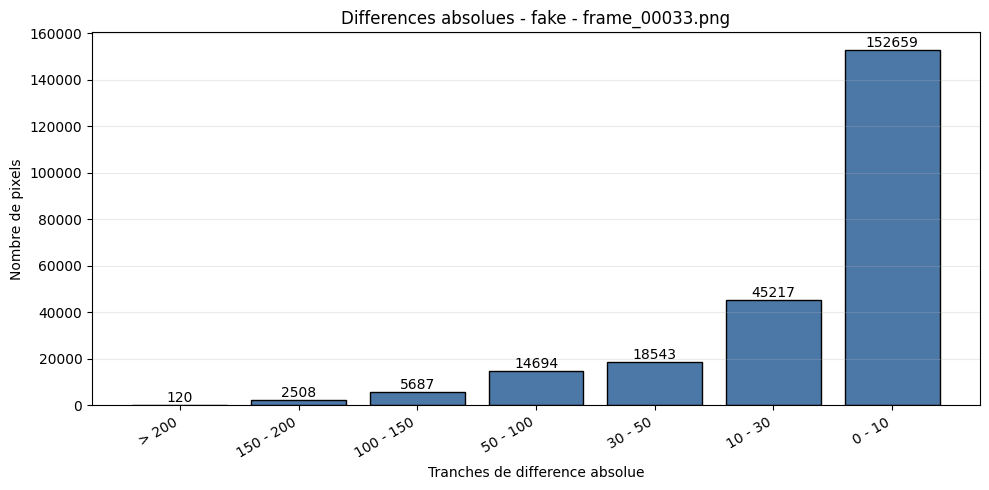

lvl:  4  initial error:  3428.0954676952733
 error improvement too small, level converged! it:  6  error:  998.9559649009288  lambda:  0.1
lvl:  3  initial error:  979.2842438330686
 error improvement too small, level converged! it:  4  error:  925.9131563593717  lambda:  14073748835532.8
lvl:  2  initial error:  1097.9137150509544
 error improvement too small, level converged! it:  9  error:  1026.9124115440363  lambda:  0.0
[fake] frame 34 -> frame_00034.png | sum error = 287317376.00 | mean abs error = 17.6351 | valid pixels = 237939


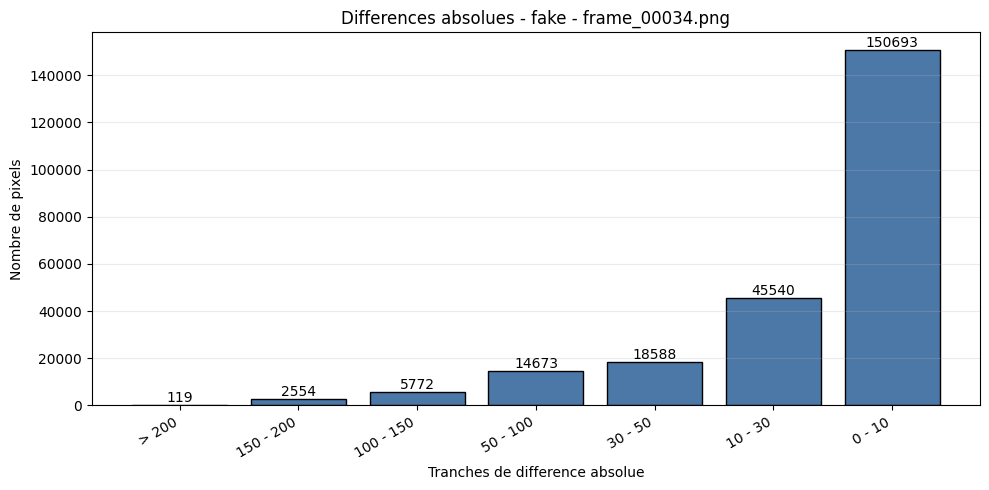

lvl:  4  initial error:  3504.026036644164
 error improvement too small, level converged! it:  6  error:  1042.052704548657  lambda:  3518437208883.2
lvl:  3  initial error:  1049.2294277609667
 error improvement too small, level converged! it:  4  error:  984.8751537666013  lambda:  6.4
lvl:  2  initial error:  1134.1488019666276
 error improvement too small, level converged! it:  6  error:  1070.568522666714  lambda:  0.0
[fake] frame 35 -> frame_00035.png | sum error = 294046112.00 | mean abs error = 18.0331 | valid pixels = 236142


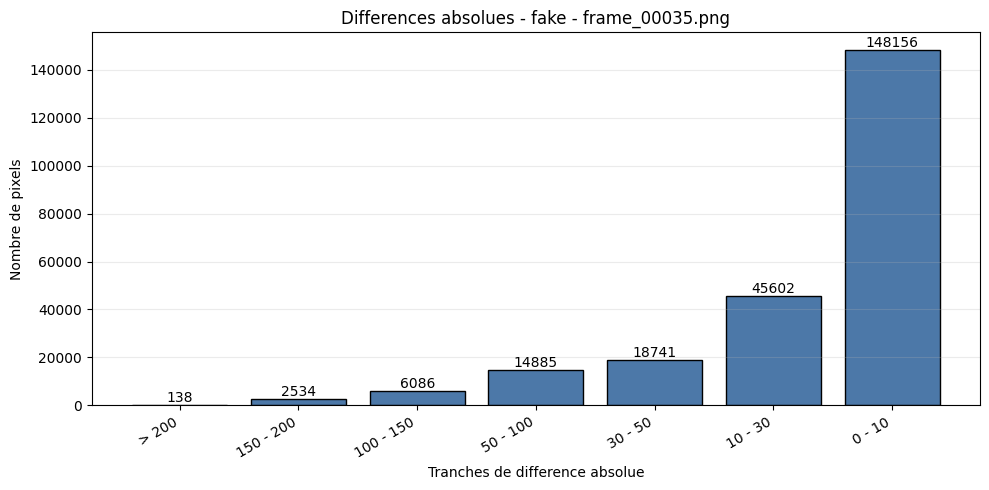

lvl:  4  initial error:  3566.5525554484075
 error improvement too small, level converged! it:  5  error:  1068.9501018670987  lambda:  6.4
lvl:  3  initial error:  1044.234824107307
 error improvement too small, level converged! it:  2  error:  1024.0831382530896  lambda:  12.8
lvl:  2  initial error:  1132.1662529175144
 error improvement too small, level converged! it:  6  error:  1093.735313024843  lambda:  0.0
[fake] frame 36 -> frame_00036.png | sum error = 295860576.00 | mean abs error = 18.1891 | valid pixels = 233900


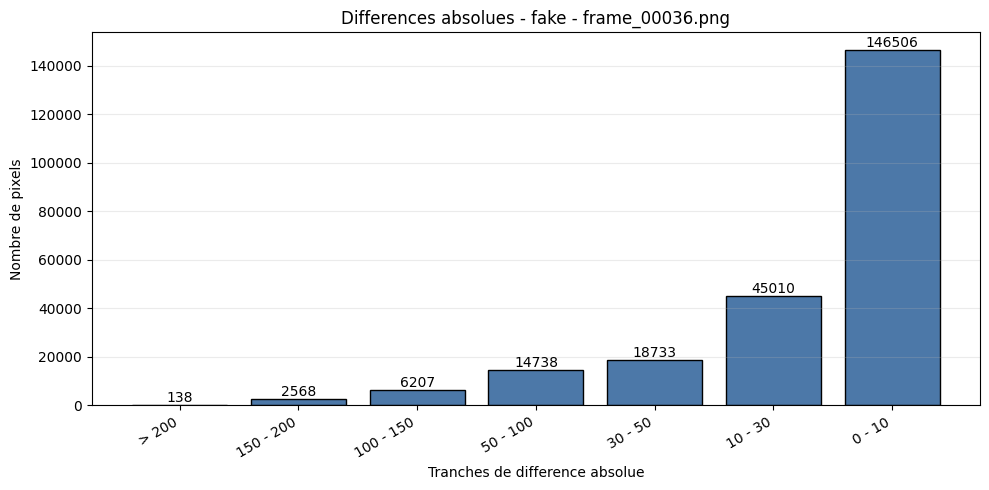

lvl:  4  initial error:  3679.225650916103
 error improvement too small, level converged! it:  4  error:  1088.4714472169646  lambda:  1.6
lvl:  3  initial error:  1038.7407455379869
 error improvement too small, level converged! it:  2  error:  1028.4108361493622  lambda:  6.4
lvl:  2  initial error:  1158.5438678544265
 error improvement too small, level converged! it:  5  error:  1120.4106128000951  lambda:  0.0
[fake] frame 37 -> frame_00037.png | sum error = 304062144.00 | mean abs error = 18.6306 | valid pixels = 232890


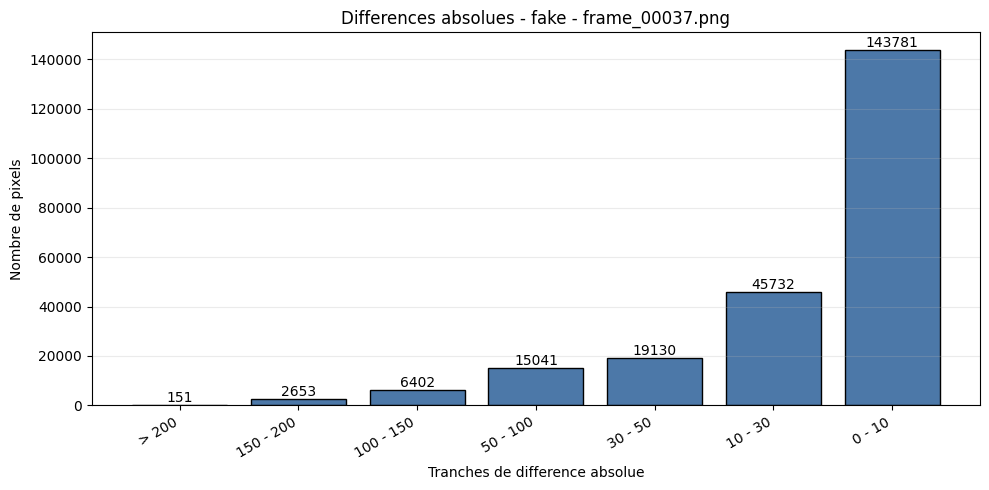

lvl:  4  initial error:  3783.9662487945984
 error improvement too small, level converged! it:  4  error:  1131.8989343322799  lambda:  6.4
lvl:  3  initial error:  1087.638364890421
update too small, level converged! it:  2  error:  1067.3280239609437  lambda:  1801439850948198.5
lvl:  2  initial error:  1213.6344259168986
 error improvement too small, level converged! it:  6  error:  1148.1972104015517  lambda:  0.0
[fake] frame 38 -> frame_00038.png | sum error = 310070304.00 | mean abs error = 18.9308 | valid pixels = 231372


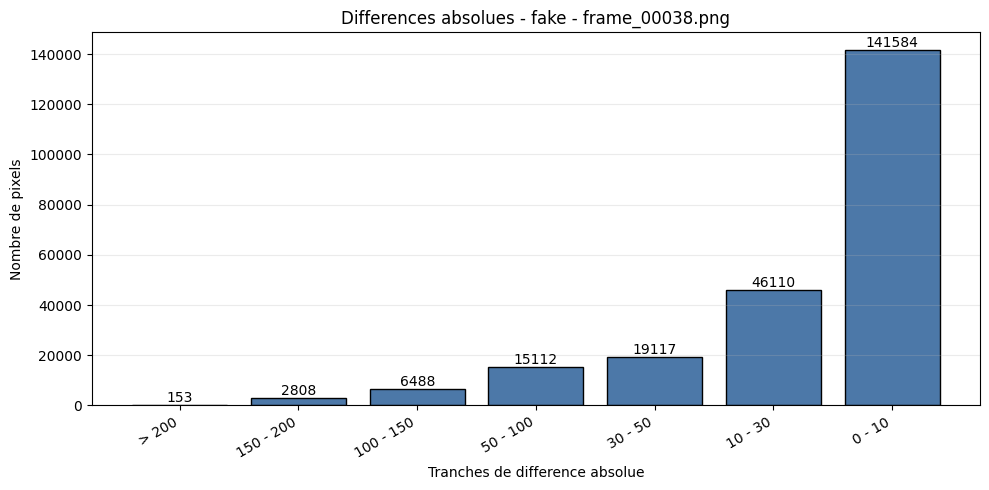

lvl:  4  initial error:  3843.940212150432
 error improvement too small, level converged! it:  4  error:  1095.8766040153637  lambda:  56294995342131.2
lvl:  3  initial error:  1085.7015003595263
 error improvement too small, level converged! it:  3  error:  1057.4466206675654  lambda:  0.0
lvl:  2  initial error:  1230.4670667764103
 error improvement too small, level converged! it:  5  error:  1195.8781193491752  lambda:  0.0
[fake] frame 39 -> frame_00039.png | sum error = 316467840.00 | mean abs error = 19.2610 | valid pixels = 229762


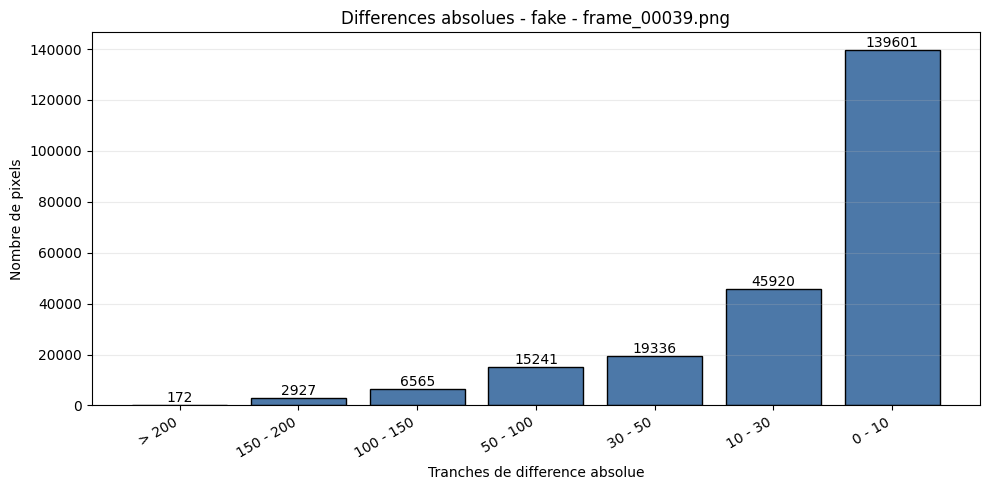

lvl:  4  initial error:  3959.0906460945016
 error improvement too small, level converged! it:  6  error:  1134.5589126067173  lambda:  7036874417766.4
lvl:  3  initial error:  1198.231639569318
 error improvement too small, level converged! it:  13  error:  1091.329561800251  lambda:  0.0
lvl:  2  initial error:  1225.5976057603489
 error improvement too small, level converged! it:  25  error:  1111.9354521273672  lambda:  0.1
[fake] frame 40 -> frame_00040.png | sum error = 299986272.00 | mean abs error = 18.8148 | valid pixels = 224576


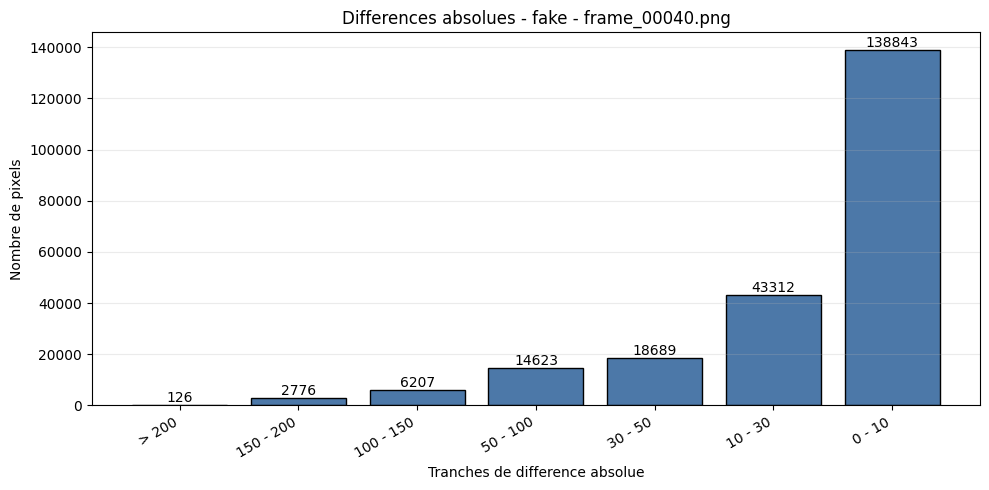

lvl:  4  initial error:  4100.598842815813
update too small, level converged! it:  5  error:  1118.1387010449068  lambda:  1801439850948198.5
lvl:  3  initial error:  1220.603691013087
 error improvement too small, level converged! it:  11  error:  1033.8653093053185  lambda:  0.1
lvl:  2  initial error:  1210.5948195310457
 error improvement too small, level converged! it:  6  error:  1139.2105665737308  lambda:  0.0
[fake] frame 41 -> frame_00041.png | sum error = 302600864.00 | mean abs error = 19.0522 | valid pixels = 223258


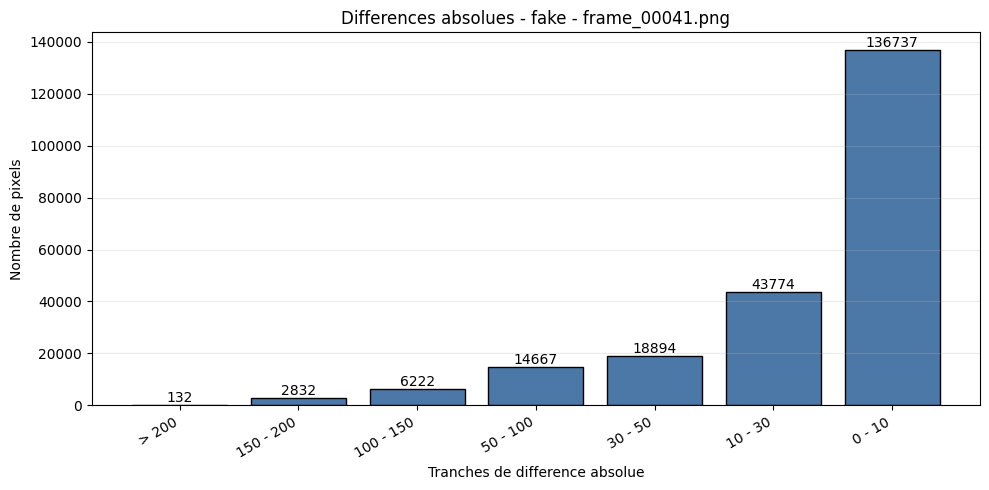

lvl:  4  initial error:  3982.0867888138846
 error improvement too small, level converged! it:  4  error:  1109.252188622676  lambda:  56294995342131.2
lvl:  3  initial error:  1211.7908902647994
 error improvement too small, level converged! it:  9  error:  1016.3301563559036  lambda:  0.1
lvl:  2  initial error:  1245.9909119683257
update too small, level converged! it:  5  error:  1176.6151739175993  lambda:  225179981368524.8
[fake] frame 42 -> frame_00042.png | sum error = 307198688.00 | mean abs error = 19.4302 | valid pixels = 221985


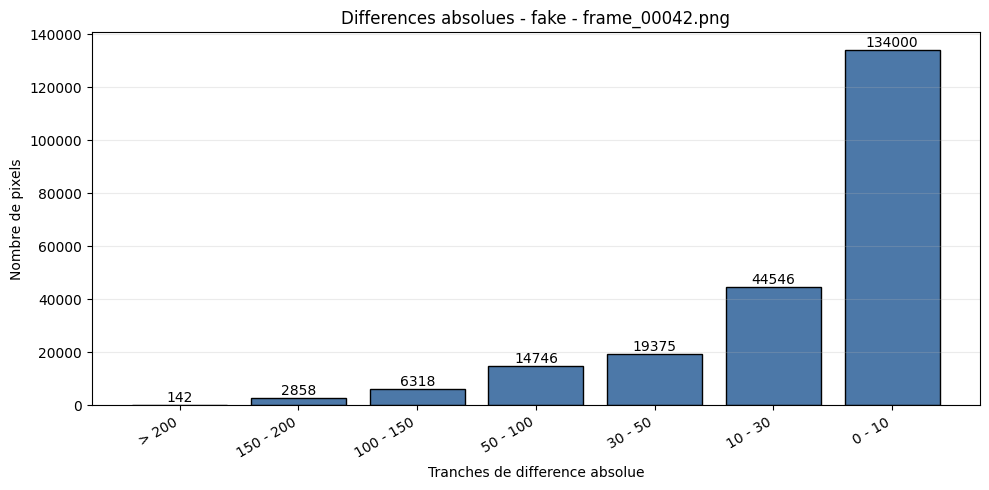

lvl:  4  initial error:  3949.0713596914156
update too small, level converged! it:  5  error:  1133.0191944492135  lambda:  1801439850948198.5
lvl:  3  initial error:  1191.4527562833043
 error improvement too small, level converged! it:  7  error:  1001.9755392223627  lambda:  0.0
lvl:  2  initial error:  1269.7078008632682
 error improvement too small, level converged! it:  8  error:  1169.4356936524664  lambda:  0.0
[fake] frame 43 -> frame_00043.png | sum error = 302145152.00 | mean abs error = 19.4778 | valid pixels = 219195


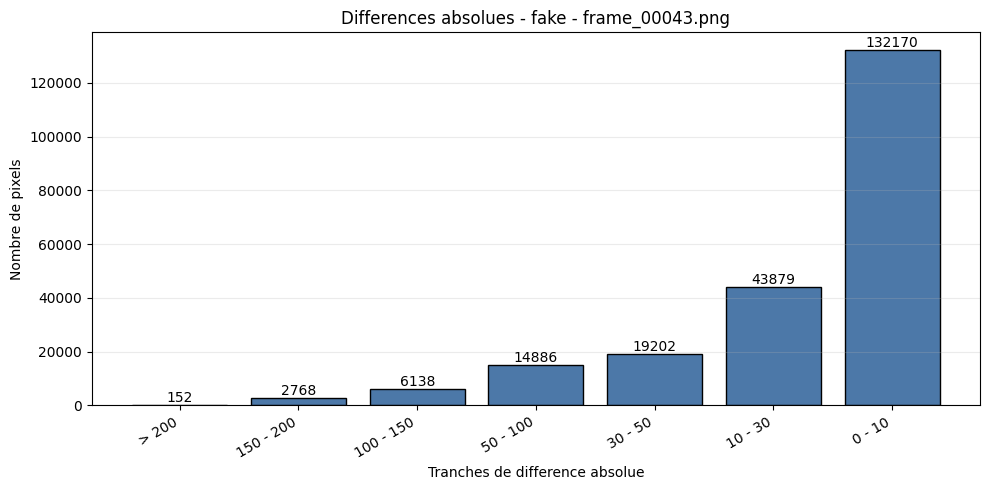

lvl:  4  initial error:  3914.2459016393427
 error improvement too small, level converged! it:  6  error:  1065.5367724449723  lambda:  14073748835532.8
lvl:  3  initial error:  1042.399072810082
 error improvement too small, level converged! it:  2  error:  991.5212218578761  lambda:  0.0
lvl:  2  initial error:  1242.0800892293062
 error improvement too small, level converged! it:  14  error:  1124.8806441153115  lambda:  0.0
[fake] frame 44 -> frame_00044.png | sum error = 286325408.00 | mean abs error = 19.0929 | valid pixels = 214538


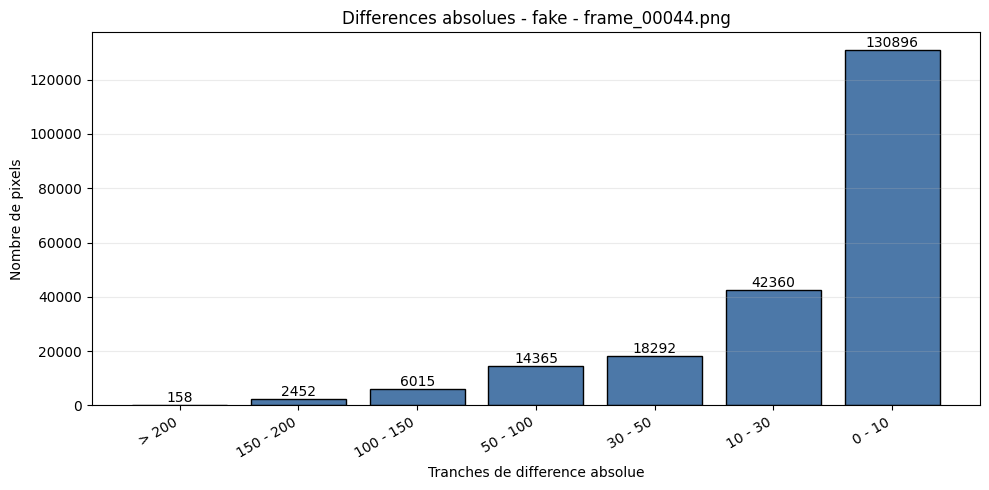

lvl:  4  initial error:  4031.9961427193816
 error improvement too small, level converged! it:  5  error:  1107.4474604473041  lambda:  3518437208883.2
lvl:  3  initial error:  1081.7652751937337
 error improvement too small, level converged! it:  2  error:  1005.9141009930526  lambda:  14073748835532.8
lvl:  2  initial error:  1242.0204222026216
 error improvement too small, level converged! it:  9  error:  1132.5473398943573  lambda:  0.0
[fake] frame 45 -> frame_00045.png | sum error = 283888192.00 | mean abs error = 19.1660 | valid pixels = 212036


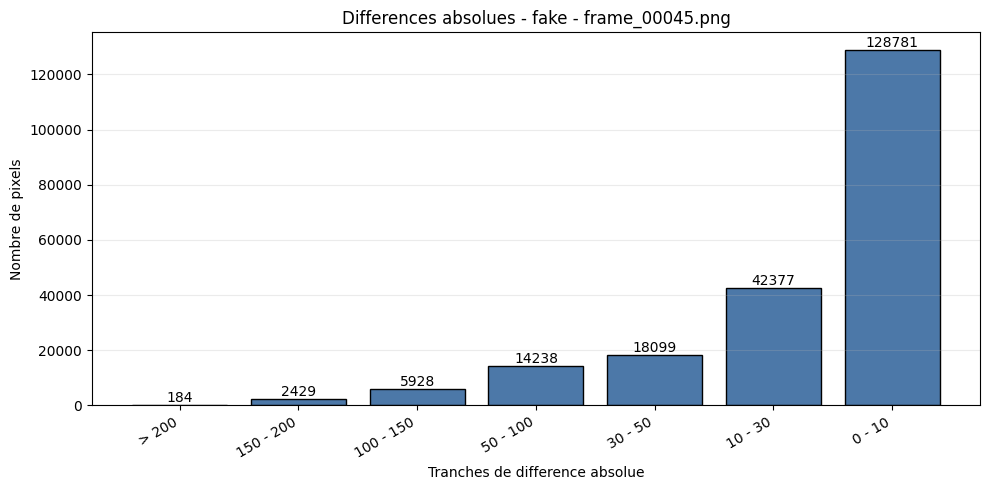

lvl:  4  initial error:  4106.15525554484
 error improvement too small, level converged! it:  4  error:  1102.099418406137  lambda:  0.4
lvl:  3  initial error:  1052.7269923388972
 error improvement too small, level converged! it:  2  error:  1023.0006268951549  lambda:  7036874417766.4
lvl:  2  initial error:  1229.8444163352144
 error improvement too small, level converged! it:  13  error:  1121.588511811558  lambda:  0.1
[fake] frame 46 -> frame_00046.png | sum error = 279391776.00 | mean abs error = 19.2168 | valid pixels = 209631


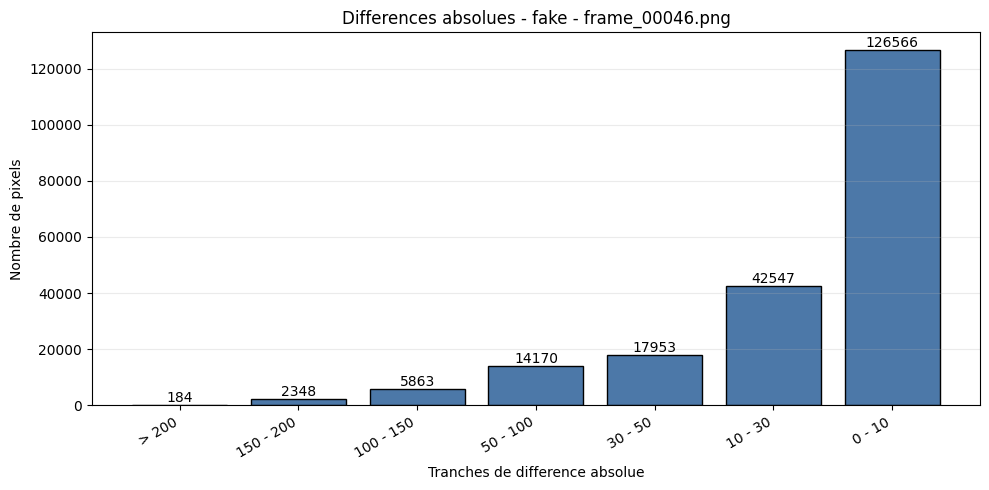

lvl:  4  initial error:  4163.69913211186
 error improvement too small, level converged! it:  4  error:  1111.7405474641187  lambda:  3518437208883.2
lvl:  3  initial error:  1054.8958300936254
update too small, level converged! it:  2  error:  1023.5906274478436  lambda:  450359962737049.6
lvl:  2  initial error:  1259.830778822054
 error improvement too small, level converged! it:  7  error:  1144.8308758144256  lambda:  0.0
[fake] frame 47 -> frame_00047.png | sum error = 283598368.00 | mean abs error = 19.5378 | valid pixels = 208709


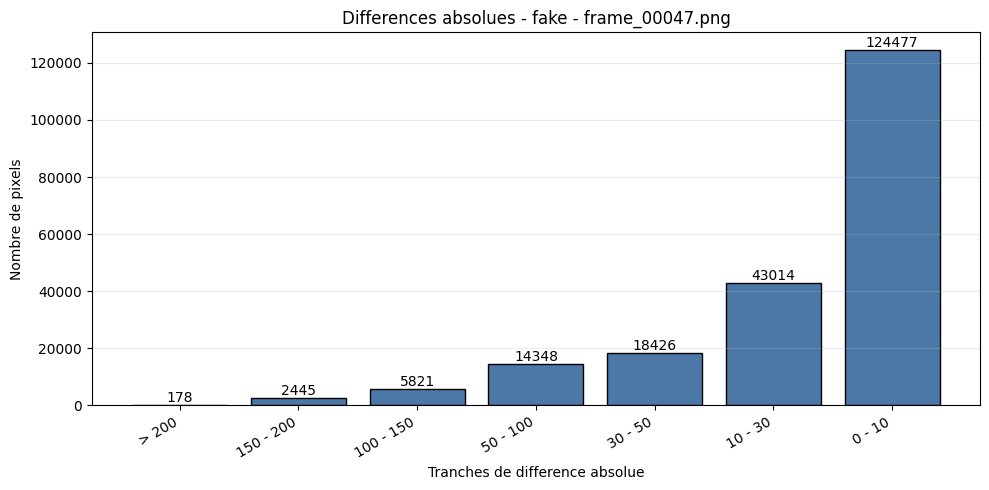

lvl:  4  initial error:  4277.337512054
 error improvement too small, level converged! it:  5  error:  1186.9591216726064  lambda:  0.4
lvl:  3  initial error:  1026.7987850390998
 error improvement too small, level converged! it:  3  error:  1009.6779645205448  lambda:  0.0
lvl:  2  initial error:  1252.8392617234106
 error improvement too small, level converged! it:  9  error:  1179.7812383063526  lambda:  7036874417766.4
[fake] frame 48 -> frame_00048.png | sum error = 285028448.00 | mean abs error = 19.7693 | valid pixels = 206337


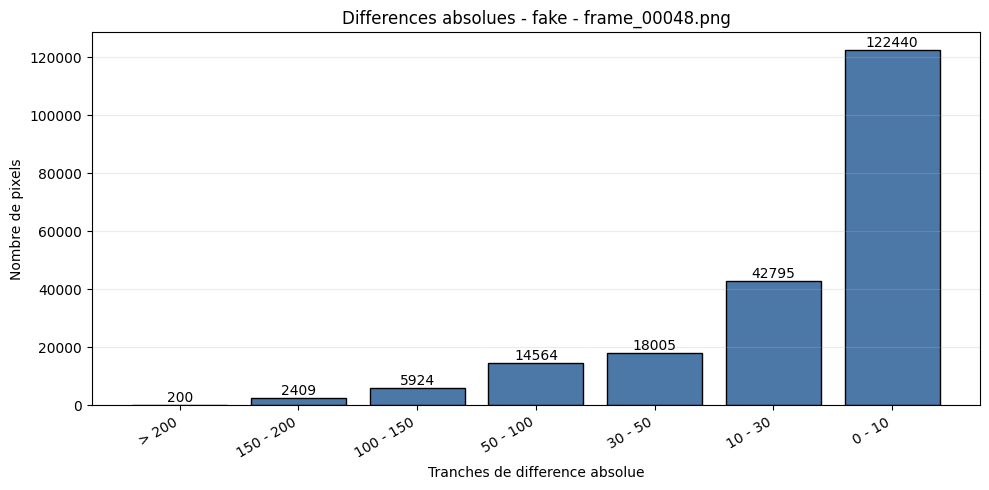

lvl:  4  initial error:  8138.653809064609
 error improvement too small, level converged! it:  5  error:  5118.649349795741  lambda:  0.2
lvl:  3  initial error:  5242.55173740931
 error improvement too small, level converged! it:  5  error:  5096.500172919133  lambda:  109951162777.6
lvl:  2  initial error:  5326.0314584574135
 error improvement too small, level converged! it:  1  error:  5325.61491832791  lambda:  3.2
[fake] frame 49 -> frame_00049.png | sum error = 1132658048.00 | mean abs error = 52.8857 | valid pixels = 205768


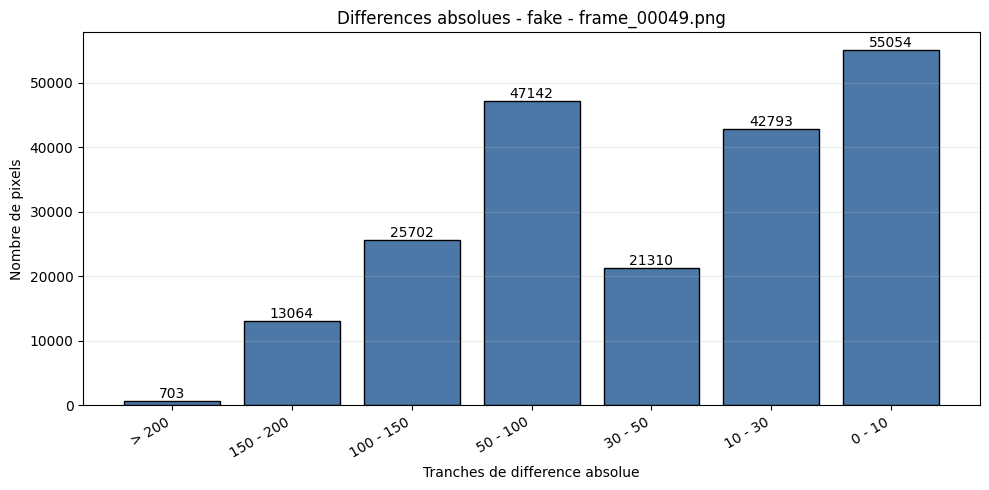

lvl:  4  initial error:  8287.886210221794
 error improvement too small, level converged! it:  5  error:  5347.160739508908  lambda:  0.8
lvl:  3  initial error:  5285.0433598728005
 error improvement too small, level converged! it:  1  error:  5284.032644641657  lambda:  0.1
lvl:  2  initial error:  5513.885170096706
 error improvement too small, level converged! it:  1  error:  5512.701470081341  lambda:  0.8
[fake] frame 50 -> frame_00050.png | sum error = 1202351872.00 | mean abs error = 54.3238 | valid pixels = 209762


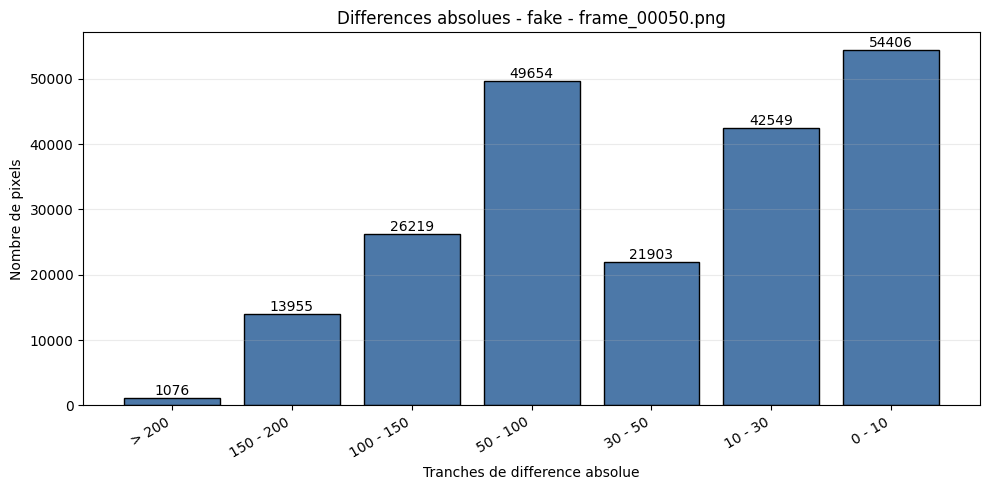

lvl:  4  initial error:  8234.97974927676
 error improvement too small, level converged! it:  3  error:  5437.927202739409  lambda:  1759218604441.6
lvl:  3  initial error:  5444.926536215373
 error improvement too small, level converged! it:  2  error:  5426.555923066366  lambda:  0.2
lvl:  2  initial error:  5637.409325258538
 error improvement too small, level converged! it:  2  error:  5631.036962946484  lambda:  51.2
[fake] frame 51 -> frame_00051.png | sum error = 1228787712.00 | mean abs error = 55.2331 | valid pixels = 210025


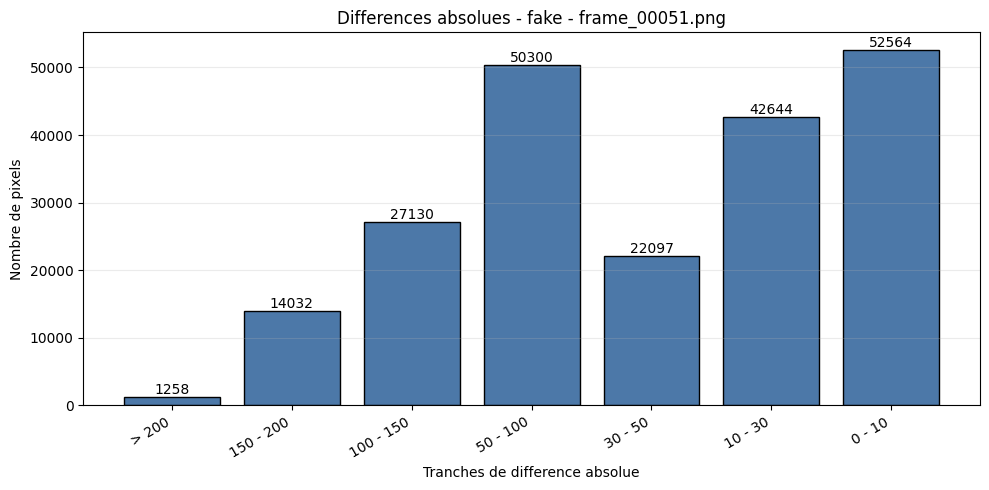

lvl:  4  initial error:  8230.700096432016
 error improvement too small, level converged! it:  3  error:  5526.373985794092  lambda:  1.6
lvl:  3  initial error:  5654.522050289925
 error improvement too small, level converged! it:  1  error:  5650.5552955998155  lambda:  0.0
lvl:  2  initial error:  5819.305252017499
 error improvement too small, level converged! it:  1  error:  5815.5430572655005  lambda:  0.1
[fake] frame 52 -> frame_00052.png | sum error = 1279870336.00 | mean abs error = 56.3913 | valid pixels = 212401


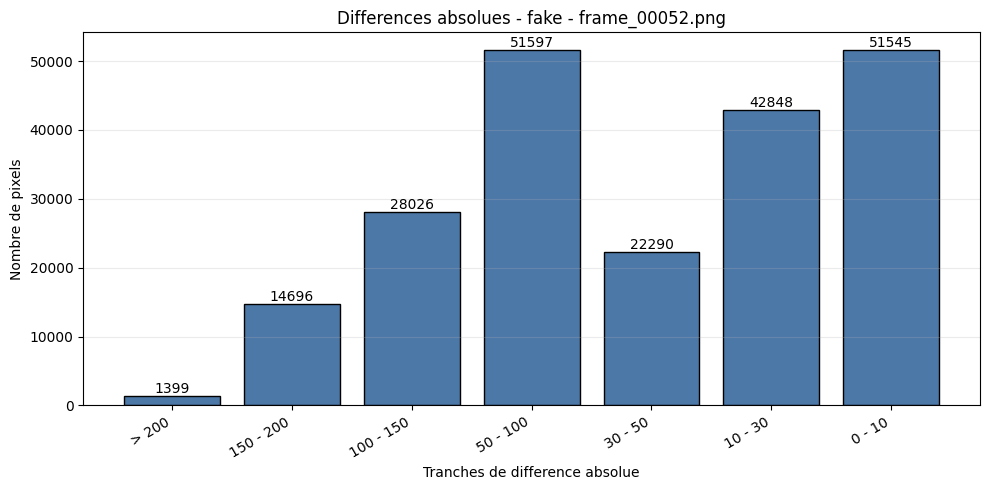

lvl:  4  initial error:  8168.466730954677
 error improvement too small, level converged! it:  5  error:  5808.202366942461  lambda:  25.6
lvl:  3  initial error:  5721.114622106809
 error improvement too small, level converged! it:  2  error:  5693.753766588596  lambda:  0.1
lvl:  2  initial error:  5940.081232136771
 error improvement too small, level converged! it:  1  error:  5938.2496092314195  lambda:  0.1
[fake] frame 53 -> frame_00053.png | sum error = 1317284096.00 | mean abs error = 57.3205 | valid pixels = 214283


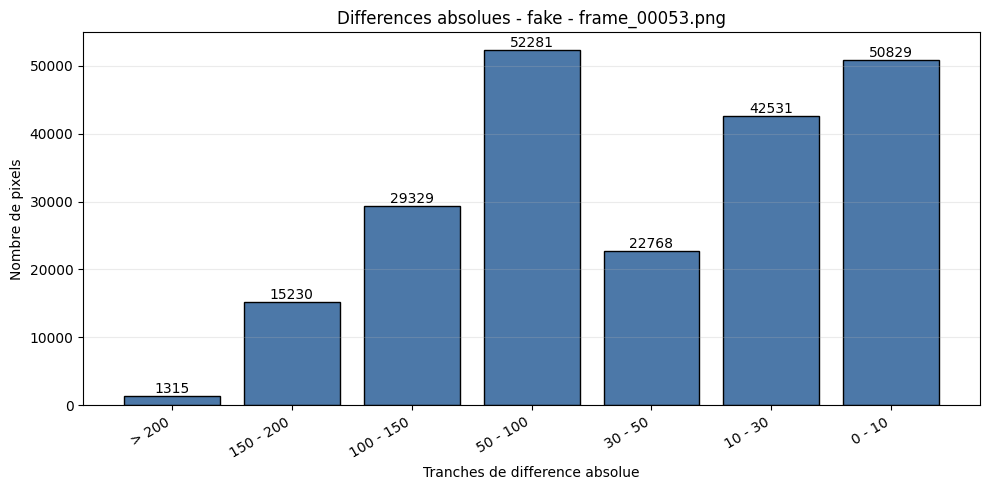

lvl:  4  initial error:  8354.28736740598
 error improvement too small, level converged! it:  6  error:  5939.36453384075  lambda:  0.1
lvl:  3  initial error:  5915.206486351223
 error improvement too small, level converged! it:  3  error:  5844.785281010734  lambda:  25.6
lvl:  2  initial error:  6082.594583188256
 error improvement too small, level converged! it:  1  error:  6082.124178115895  lambda:  0.1
[fake] frame 54 -> frame_00054.png | sum error = 1345773056.00 | mean abs error = 58.2338 | valid pixels = 214059


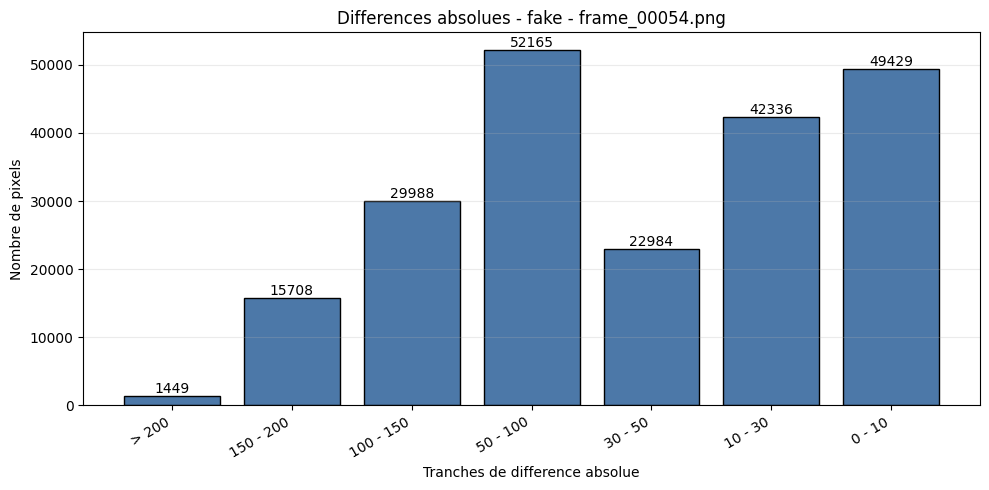

lvl:  4  initial error:  8497.771456123433
 error improvement too small, level converged! it:  5  error:  5820.636158971233  lambda:  0.0
lvl:  3  initial error:  5926.792874376621
 error improvement too small, level converged! it:  2  error:  5903.253880150216  lambda:  0.1
lvl:  2  initial error:  6087.41879755883
 error improvement too small, level converged! it:  1  error:  6082.736601107176  lambda:  0.2
[fake] frame 55 -> frame_00055.png | sum error = 1315492096.00 | mean abs error = 58.2491 | valid pixels = 210331


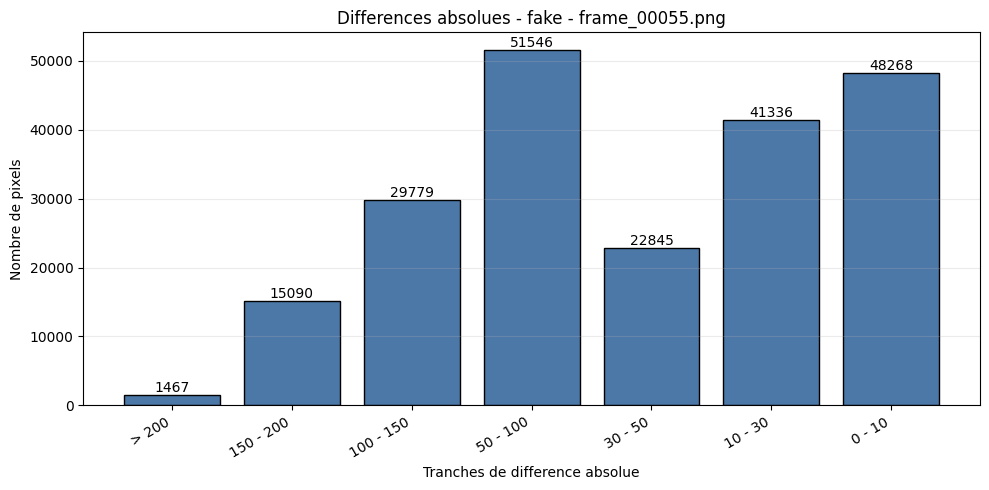

lvl:  4  initial error:  8517.948891031823
 error improvement too small, level converged! it:  3  error:  6057.542417160151  lambda:  204.8
lvl:  3  initial error:  6019.6385276236015
 error improvement too small, level converged! it:  1  error:  6016.727515617048  lambda:  0.0
lvl:  2  initial error:  6236.336816863283
 error improvement too small, level converged! it:  1  error:  6235.738992049725  lambda:  0.4
[fake] frame 56 -> frame_00056.png | sum error = 1378911616.00 | mean abs error = 59.2906 | valid pixels = 214453


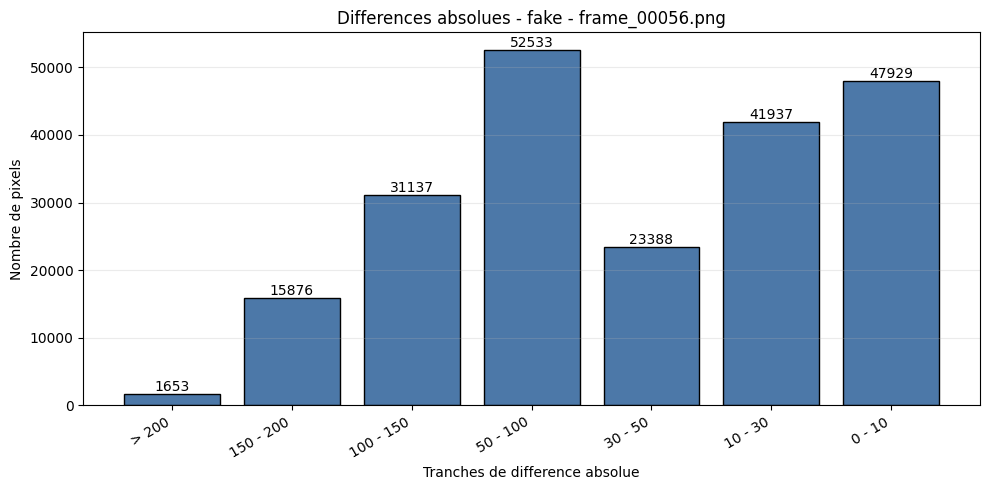

lvl:  4  initial error:  8378.308582449374
 error improvement too small, level converged! it:  5  error:  6116.190821070941  lambda:  0.4
lvl:  3  initial error:  6075.7409928495035
 error improvement too small, level converged! it:  5  error:  6032.629707262555  lambda:  0.0
lvl:  2  initial error:  6265.145689578671
 error improvement too small, level converged! it:  2  error:  6257.2030143004895  lambda:  204.8
[fake] frame 57 -> frame_00057.png | sum error = 1384703232.00 | mean abs error = 59.5653 | valid pixels = 213944


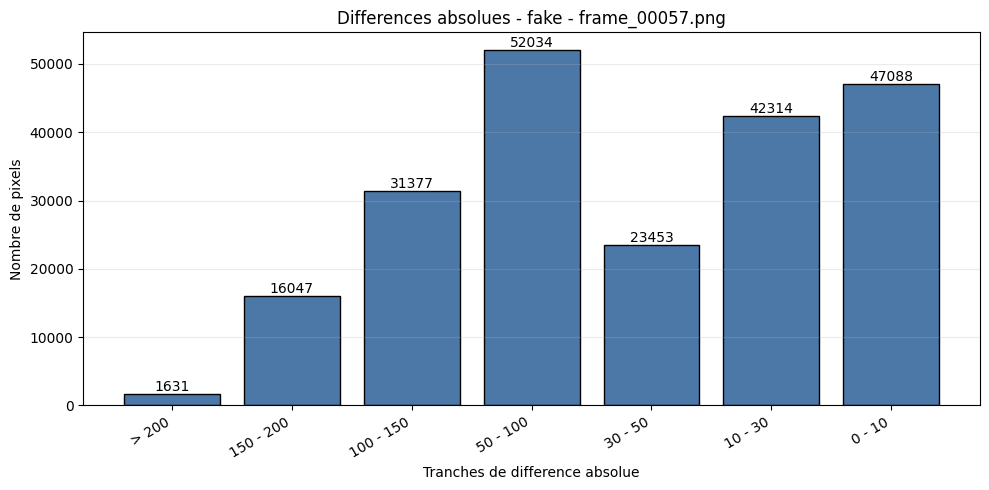

lvl:  4  initial error:  8329.324975891994
 error improvement too small, level converged! it:  6  error:  6107.71418420997  lambda:  1.6
lvl:  3  initial error:  6140.299944643172
 error improvement too small, level converged! it:  5  error:  6029.841706206349  lambda:  3.2
lvl:  2  initial error:  6263.653403992553
 error improvement too small, level converged! it:  1  error:  6262.625355181954  lambda:  0.0
[fake] frame 58 -> frame_00058.png | sum error = 1368479616.00 | mean abs error = 59.6055 | valid pixels = 211583


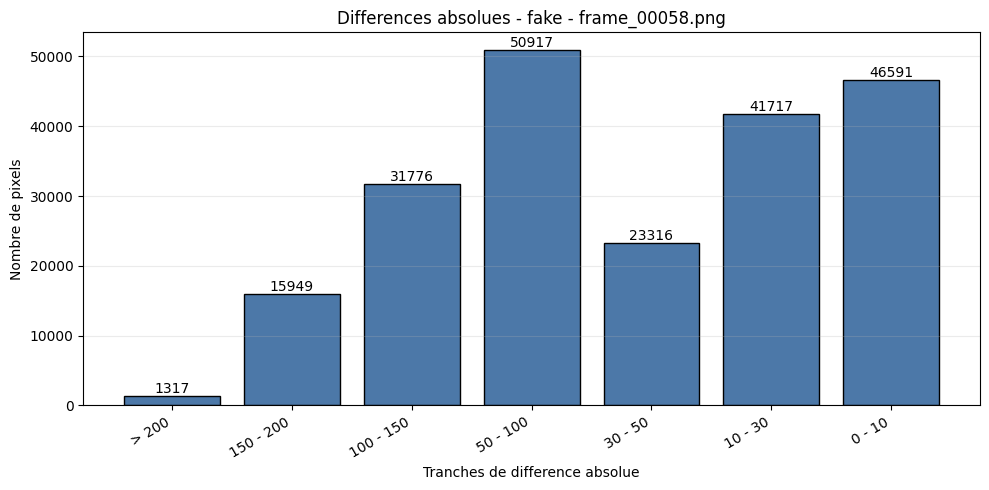

lvl:  4  initial error:  8346.101253616198
 error improvement too small, level converged! it:  7  error:  6199.841044029573  lambda:  0.4
lvl:  3  initial error:  6123.366469964893
 error improvement too small, level converged! it:  2  error:  6111.277646813706  lambda:  0.1
lvl:  2  initial error:  6282.797901301963
 error improvement too small, level converged! it:  1  error:  6282.7522424329145  lambda:  51.2
[fake] frame 59 -> frame_00059.png | sum error = 1365091712.00 | mean abs error = 59.7761 | valid pixels = 210422


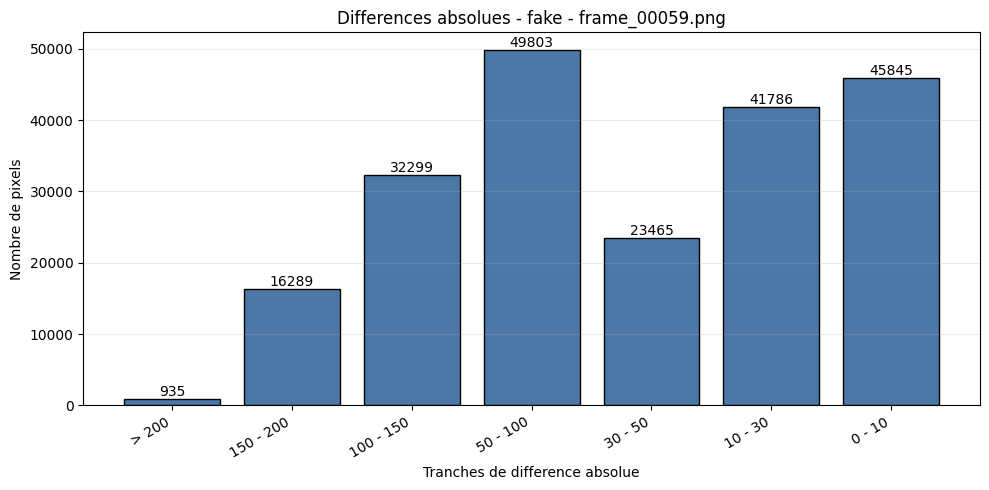

lvl:  4  initial error:  8420.830279652844
 error improvement too small, level converged! it:  5  error:  6184.373607635361  lambda:  6.4
lvl:  3  initial error:  6192.064416768277
 error improvement too small, level converged! it:  2  error:  6147.641822355669  lambda:  0.0
lvl:  2  initial error:  6364.057279930059
 error improvement too small, level converged! it:  1  error:  6359.483022725272  lambda:  0.0
[fake] frame 60 -> frame_00060.png | sum error = 1370355840.00 | mean abs error = 60.1139 | valid pixels = 209026


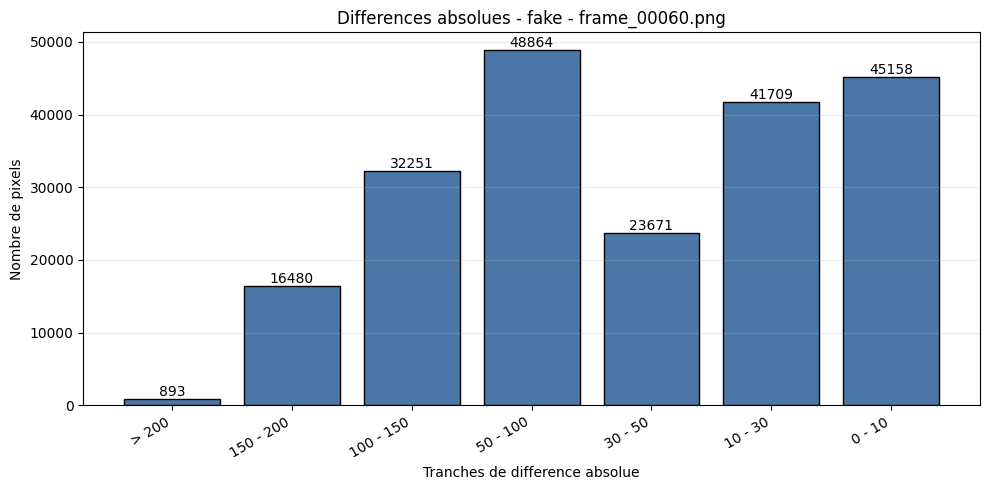

lvl:  4  initial error:  8354.310511089681
 error improvement too small, level converged! it:  6  error:  6181.59504621527  lambda:  3.2
lvl:  3  initial error:  6211.139965174289
 error improvement too small, level converged! it:  3  error:  6151.024903696195  lambda:  0.0
lvl:  2  initial error:  6357.2352738433165
 error improvement too small, level converged! it:  1  error:  6355.269327231517  lambda:  0.1
[fake] frame 61 -> frame_00061.png | sum error = 1354094464.00 | mean abs error = 60.0239 | valid pixels = 206698


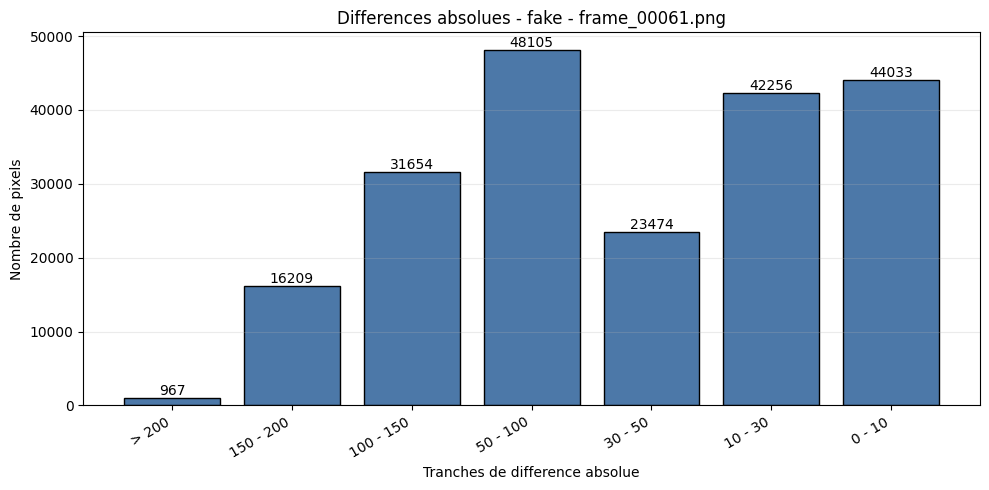

lvl:  4  initial error:  8222.108968177434
 error improvement too small, level converged! it:  8  error:  6140.541326046578  lambda:  6.4
lvl:  3  initial error:  6230.259778037646
 error improvement too small, level converged! it:  2  error:  6221.700528860886  lambda:  3.2
lvl:  2  initial error:  6482.428450941352
 error improvement too small, level converged! it:  1  error:  6482.374756476736  lambda:  25.6
[fake] frame 62 -> frame_00062.png | sum error = 1405312000.00 | mean abs error = 61.1838 | valid pixels = 210609


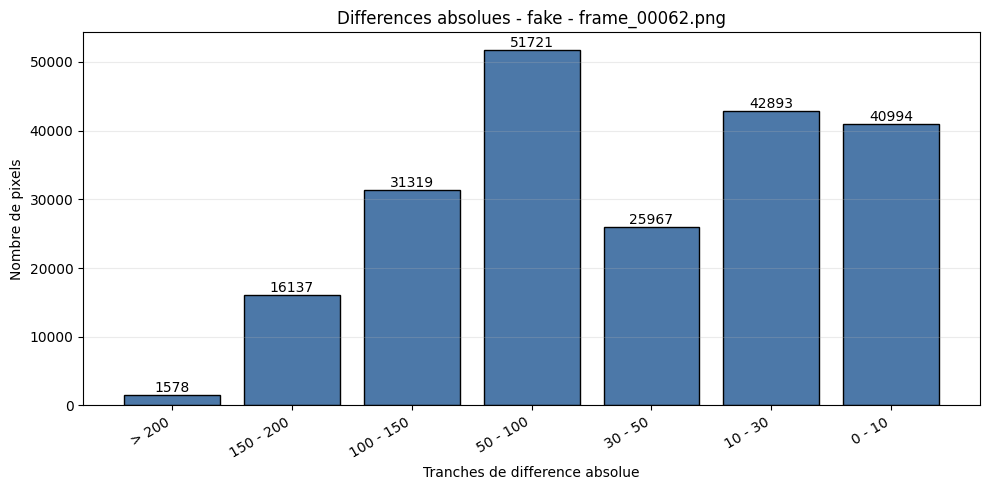

lvl:  4  initial error:  8172.479267116682
 error improvement too small, level converged! it:  9  error:  6139.634491662682  lambda:  3.2
lvl:  3  initial error:  6272.802795514237
 error improvement too small, level converged! it:  5  error:  6152.174325140973  lambda:  0.2
lvl:  2  initial error:  6398.445374573585
 error improvement too small, level converged! it:  1  error:  6397.370565289246  lambda:  0.4
[fake] frame 63 -> frame_00063.png | sum error = 1333458432.00 | mean abs error = 61.1363 | valid pixels = 203093


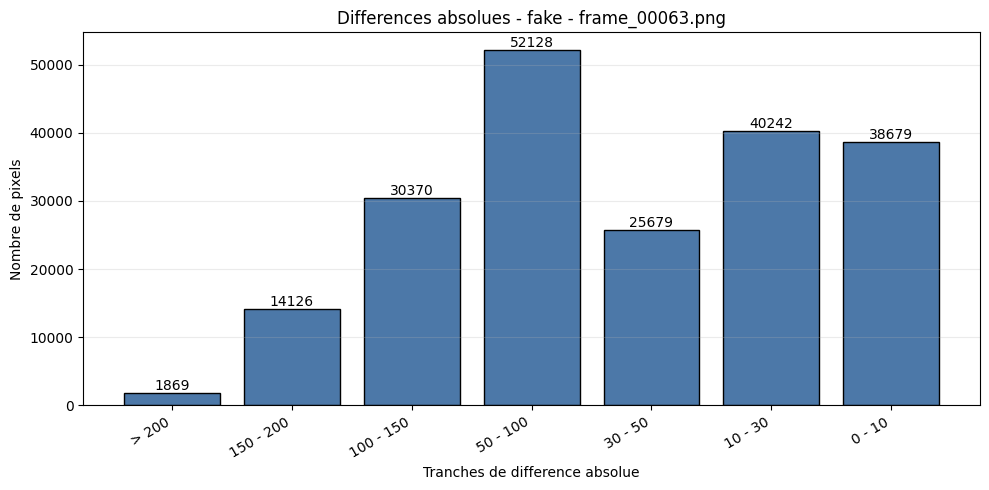

lvl:  4  initial error:  8276.115718418516
 error improvement too small, level converged! it:  5  error:  6013.261613395155  lambda:  3.2
lvl:  3  initial error:  6295.751592379355
 error improvement too small, level converged! it:  2  error:  6273.631273032795  lambda:  0.0
lvl:  2  initial error:  6454.767499301026
 error improvement too small, level converged! it:  1  error:  6453.232819676531  lambda:  0.0
[fake] frame 64 -> frame_00064.png | sum error = 1367105536.00 | mean abs error = 61.6367 | valid pixels = 206237


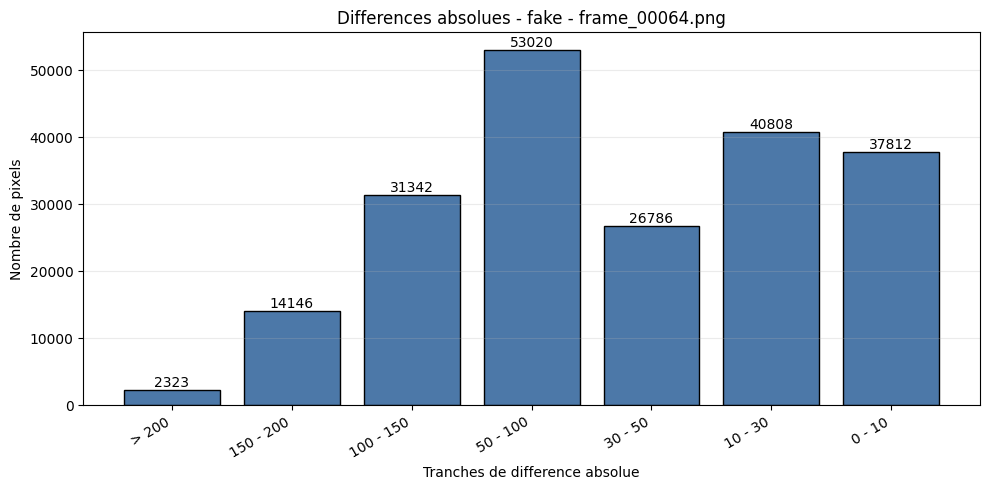

lvl:  4  initial error:  8374.000964320154
 error improvement too small, level converged! it:  3  error:  6169.7636625968535  lambda:  12.8
lvl:  3  initial error:  6401.274386081394
 error improvement too small, level converged! it:  1  error:  6400.513743003431  lambda:  6.4
lvl:  2  initial error:  6578.131148959776
 error improvement too small, level converged! it:  3  error:  6549.664497106191  lambda:  0.0
[fake] frame 65 -> frame_00065.png | sum error = 1404290944.00 | mean abs error = 61.9205 | valid pixels = 208666


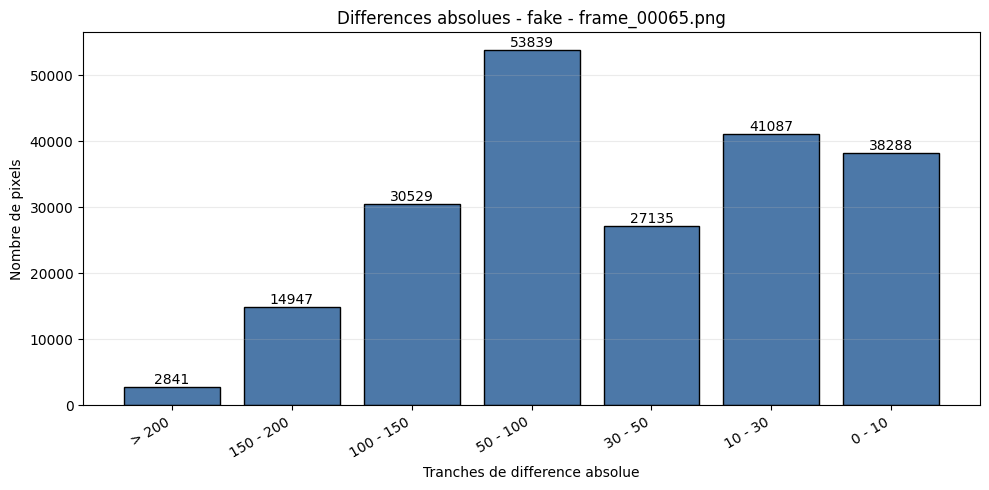

lvl:  4  initial error:  8607.437801350048
 error improvement too small, level converged! it:  6  error:  6303.446879803417  lambda:  0.0
lvl:  3  initial error:  6588.210776123134
 error improvement too small, level converged! it:  1  error:  6586.693073518884  lambda:  0.0
lvl:  2  initial error:  6732.620056479174
 error improvement too small, level converged! it:  3  error:  6704.067428694465  lambda:  0.0
[fake] frame 66 -> frame_00066.png | sum error = 1464289152.00 | mean abs error = 62.8978 | valid pixels = 212418


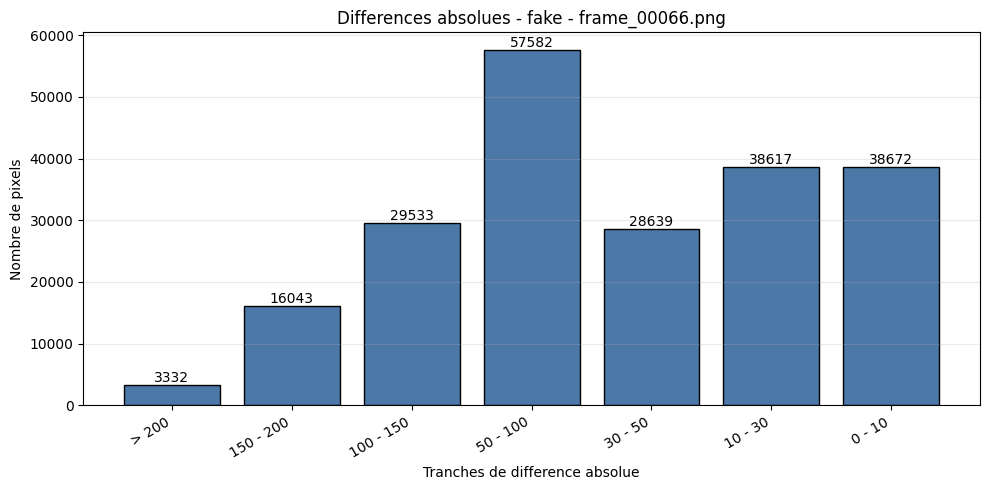

lvl:  4  initial error:  8765.228543876565
 error improvement too small, level converged! it:  3  error:  6490.784854253213  lambda:  1.6
lvl:  3  initial error:  6728.380243002349
 error improvement too small, level converged! it:  1  error:  6722.393244348354  lambda:  0.0
lvl:  2  initial error:  6912.587572172061
 error improvement too small, level converged! it:  10  error:  6802.363539844257  lambda:  0.0
[fake] frame 67 -> frame_00067.png | sum error = 1464363776.00 | mean abs error = 63.1488 | valid pixels = 209556


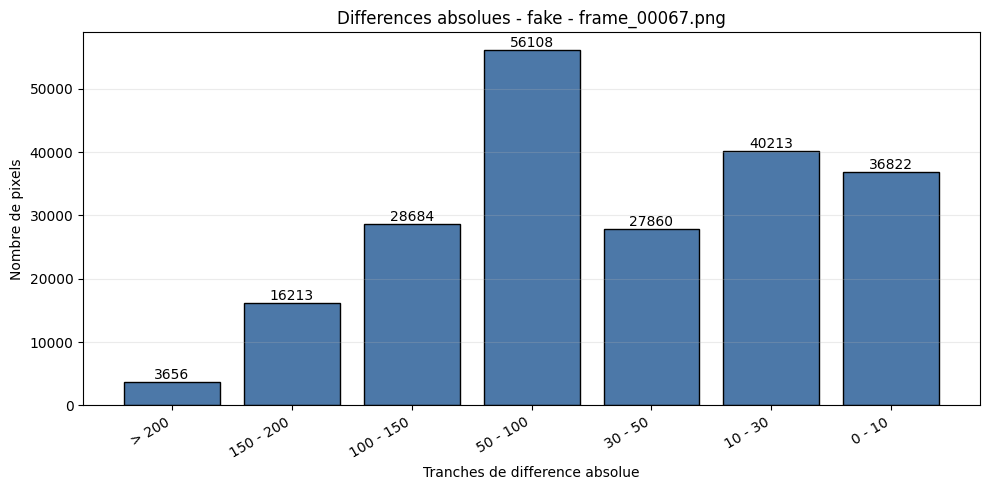

lvl:  4  initial error:  9046.681774349083
 error improvement too small, level converged! it:  3  error:  6915.093432774813  lambda:  0.2
lvl:  3  initial error:  7051.616887856964
 error improvement too small, level converged! it:  6  error:  6778.909018611553  lambda:  0.0
lvl:  2  initial error:  6955.735419348346
 error improvement too small, level converged! it:  1  error:  6955.728070789732  lambda:  25.6
[fake] frame 68 -> frame_00068.png | sum error = 1463112448.00 | mean abs error = 63.5960 | valid pixels = 205384


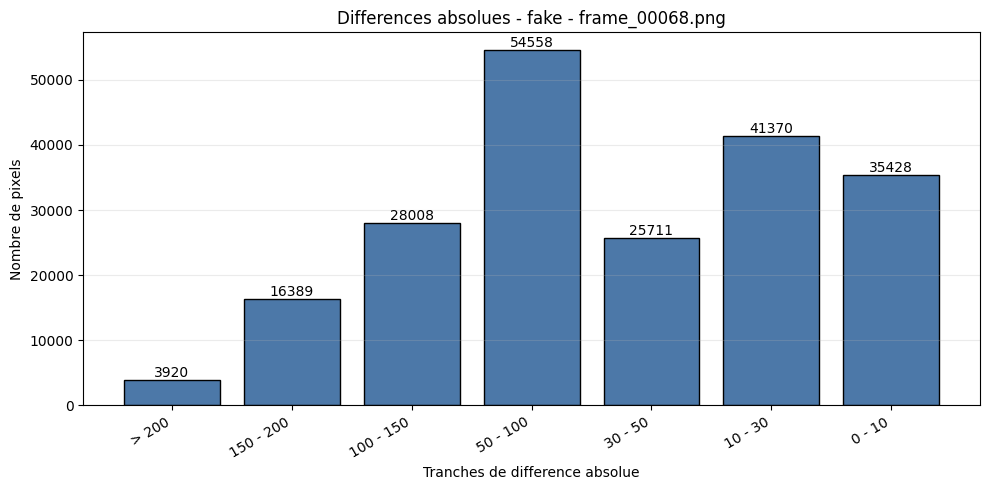

lvl:  4  initial error:  9182.11668273867
update too small, level converged! it:  4  error:  7046.411545505736  lambda:  3602879701896397.0
lvl:  3  initial error:  7212.863881734727
 error improvement too small, level converged! it:  10  error:  6943.136339449801  lambda:  109951162777.6
lvl:  2  initial error:  7141.310618432131
 error improvement too small, level converged! it:  1  error:  7140.877234776643  lambda:  0.2
[fake] frame 69 -> frame_00069.png | sum error = 1459959680.00 | mean abs error = 64.3265 | valid pixels = 200454


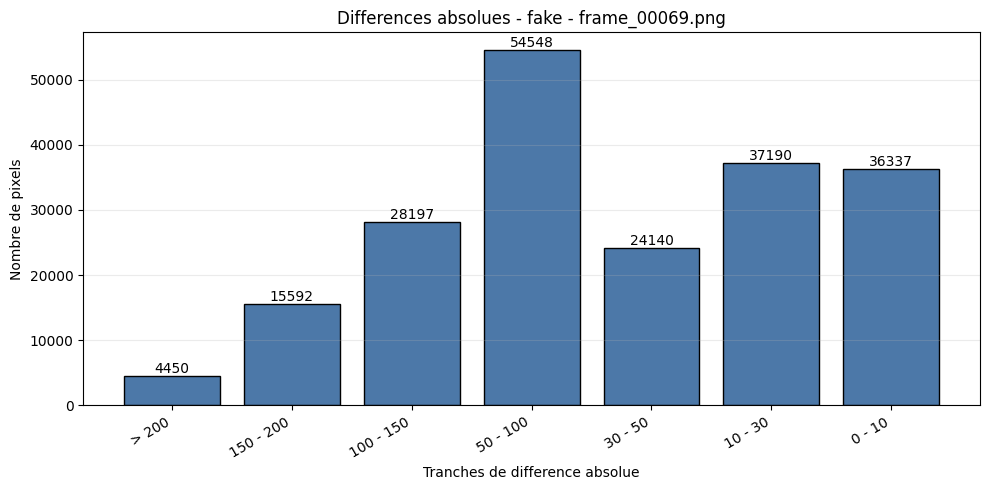

lvl:  4  initial error:  8991.71263259402
 error improvement too small, level converged! it:  3  error:  6998.130982181961  lambda:  6.4
lvl:  3  initial error:  7033.882662089925
 error improvement too small, level converged! it:  4  error:  6975.9644062803245  lambda:  219902325555.2
lvl:  2  initial error:  7177.53404191893
 error improvement too small, level converged! it:  2  error:  7162.67491011188  lambda:  0.0
[fake] frame 70 -> frame_00070.png | sum error = 1482363008.00 | mean abs error = 64.7015 | valid pixels = 202335


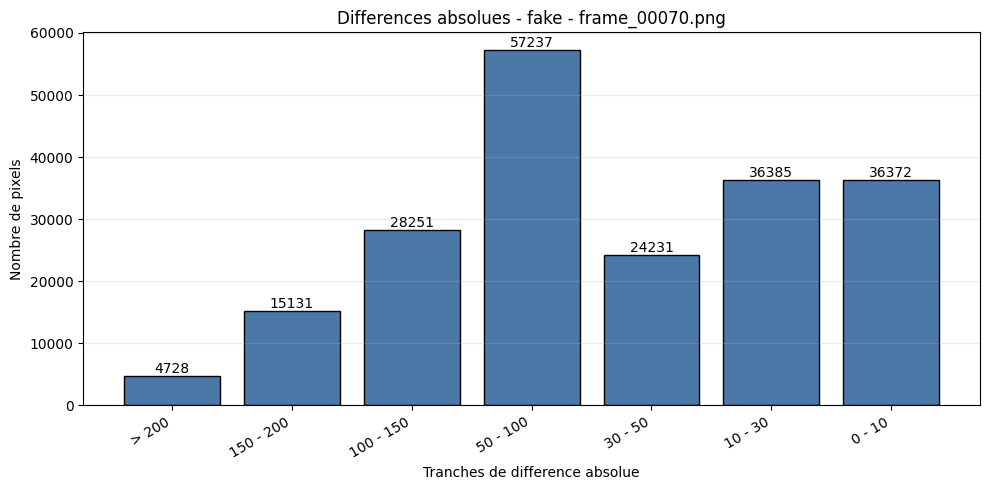

lvl:  4  initial error:  8537.220829315333
 error improvement too small, level converged! it:  9  error:  5874.486467414992  lambda:  0.1
lvl:  3  initial error:  6263.18847639797
 error improvement too small, level converged! it:  5  error:  6152.636233475123  lambda:  0.0
lvl:  2  initial error:  6363.019361094873
 error improvement too small, level converged! it:  1  error:  6361.398612691374  lambda:  0.0
[fake] frame 71 -> frame_00071.png | sum error = 1451136512.00 | mean abs error = 61.5745 | valid pixels = 221061


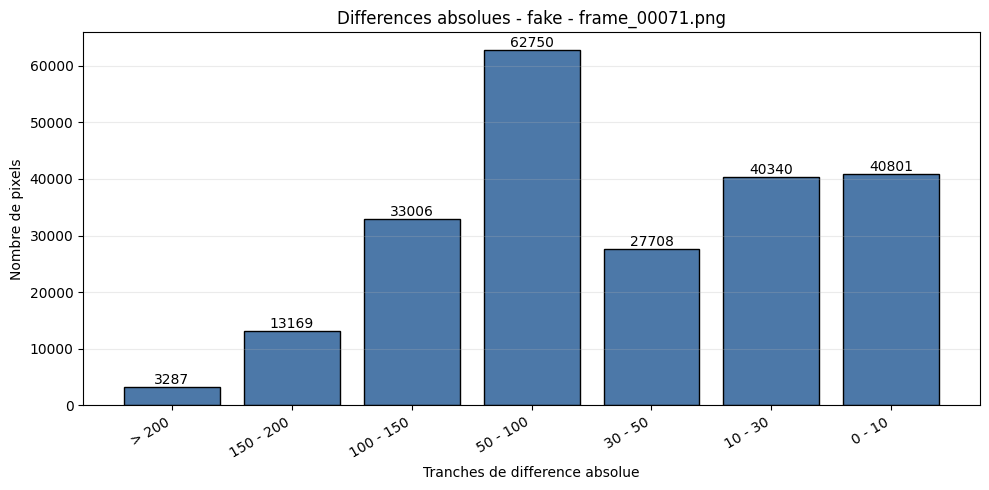

lvl:  4  initial error:  8185.515911282546
 error improvement too small, level converged! it:  7  error:  5404.987837258006  lambda:  0.1
lvl:  3  initial error:  5772.115265509006
 error improvement too small, level converged! it:  7  error:  5535.1853622351055  lambda:  0.0
lvl:  2  initial error:  5764.208814596852
 error improvement too small, level converged! it:  2  error:  5749.054563815671  lambda:  0.0
[fake] frame 72 -> frame_00072.png | sum error = 1290872704.00 | mean abs error = 57.9688 | valid pixels = 216699


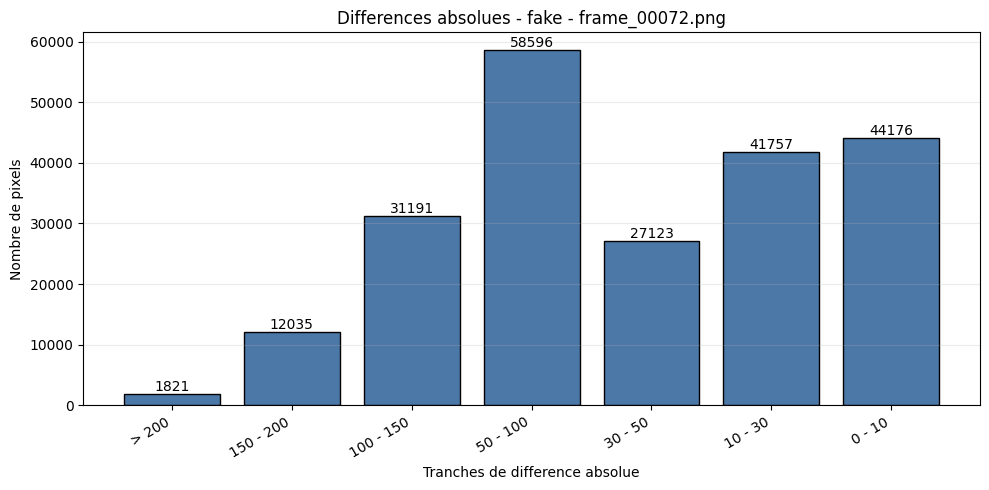

lvl:  4  initial error:  7631.565091610414
 error improvement too small, level converged! it:  6  error:  4894.271791069701  lambda:  3518437208883.2
lvl:  3  initial error:  5236.28394571186
 error improvement too small, level converged! it:  5  error:  5074.890854293589  lambda:  0.0
lvl:  2  initial error:  5246.317746474845
 error improvement too small, level converged! it:  9  error:  5159.988072993314  lambda:  0.0
[fake] frame 73 -> frame_00073.png | sum error = 1061423168.00 | mean abs error = 53.9275 | valid pixels = 197947


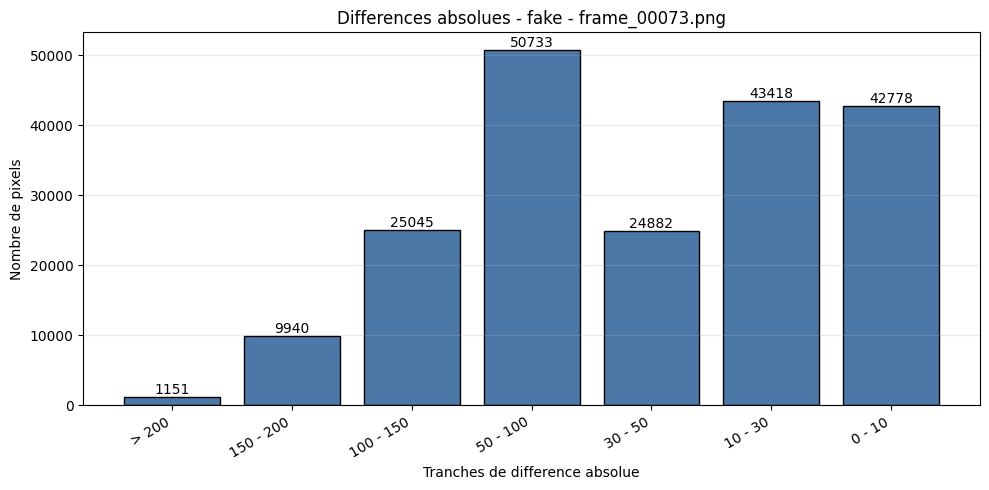

lvl:  4  initial error:  7170.084860173578
 error improvement too small, level converged! it:  6  error:  4440.616160861309  lambda:  25.6
lvl:  3  initial error:  4782.2691629503015
 error improvement too small, level converged! it:  2  error:  4754.800283837764  lambda:  0.0
lvl:  2  initial error:  4993.956254325485
 error improvement too small, level converged! it:  3  error:  4966.065588382163  lambda:  0.0
[fake] frame 74 -> frame_00074.png | sum error = 997832960.00 | mean abs error = 52.2076 | valid pixels = 193592


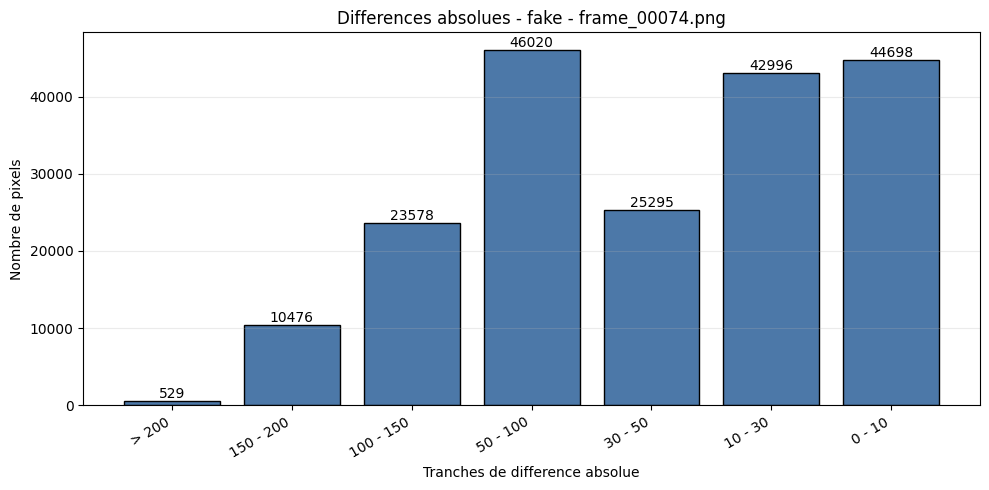

lvl:  4  initial error:  7095.522661523626
 error improvement too small, level converged! it:  5  error:  4532.863776457065  lambda:  0.4
lvl:  3  initial error:  4821.6937280919965
 error improvement too small, level converged! it:  7  error:  4706.625913483363  lambda:  6.4
lvl:  2  initial error:  4910.175049772971
 error improvement too small, level converged! it:  2  error:  4899.973752025643  lambda:  0.0
[fake] frame 75 -> frame_00075.png | sum error = 948479232.00 | mean abs error = 51.3576 | valid pixels = 186381


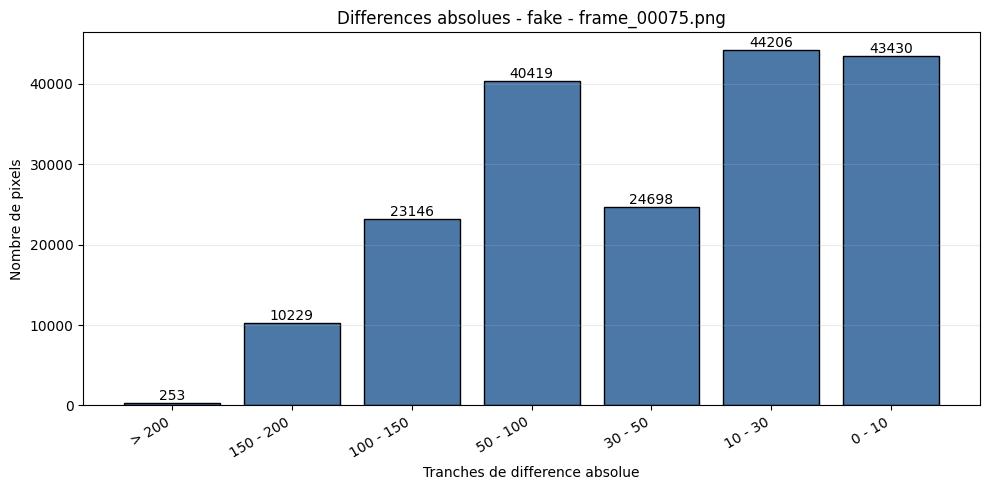

lvl:  4  initial error:  6869.663452266152
 error improvement too small, level converged! it:  8  error:  4185.839602183767  lambda:  0.1
lvl:  3  initial error:  4524.392551301936
 error improvement too small, level converged! it:  4  error:  4422.064741124298  lambda:  0.1
lvl:  2  initial error:  4674.507362062358
 error improvement too small, level converged! it:  2  error:  4663.43520659013  lambda:  0.0
[fake] frame 76 -> frame_00076.png | sum error = 899125696.00 | mean abs error = 49.6087 | valid pixels = 184796


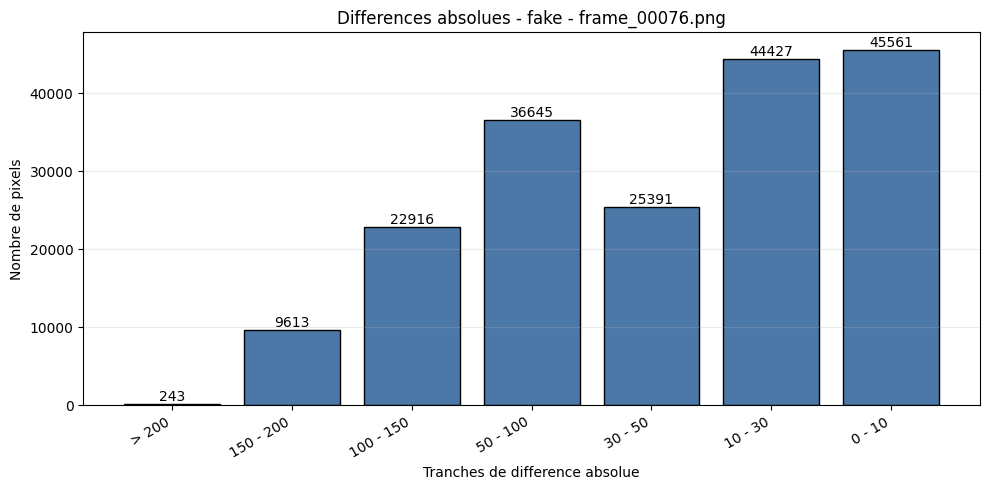

lvl:  4  initial error:  6760.679845708774
 error improvement too small, level converged! it:  5  error:  4409.664287220234  lambda:  0.2
lvl:  3  initial error:  4674.270997906643
 error improvement too small, level converged! it:  9  error:  4534.650483808189  lambda:  6.4
lvl:  2  initial error:  4784.186686722446
 error improvement too small, level converged! it:  1  error:  4783.3936633855865  lambda:  0.0
[fake] frame 77 -> frame_00077.png | sum error = 935675200.00 | mean abs error = 49.9806 | valid pixels = 187544


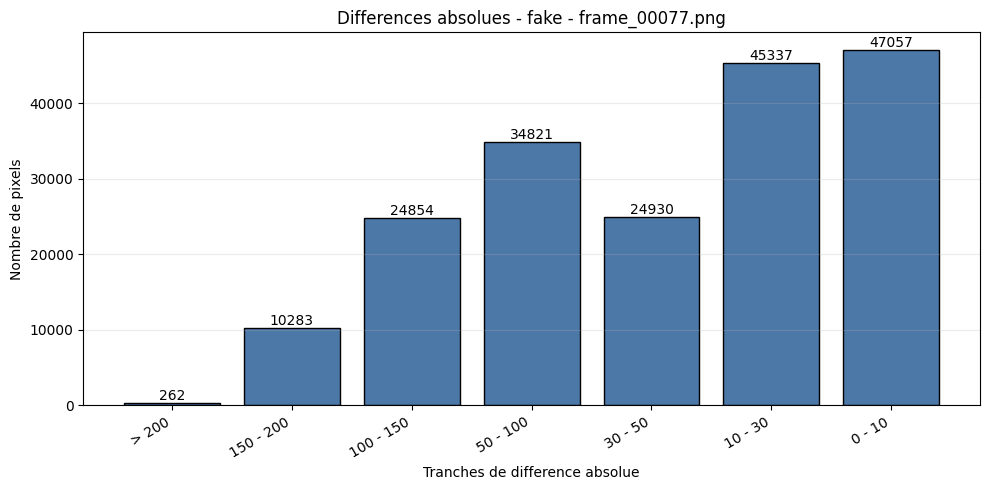

lvl:  4  initial error:  6502.61137897782
 error improvement too small, level converged! it:  3  error:  4354.854697706271  lambda:  0.1
lvl:  3  initial error:  4659.10739572384
 error improvement too small, level converged! it:  2  error:  4640.676311265324  lambda:  0.1
lvl:  2  initial error:  4900.999355582807
 error improvement too small, level converged! it:  1  error:  4899.359738908148  lambda:  0.2
[fake] frame 78 -> frame_00078.png | sum error = 988236288.00 | mean abs error = 50.2697 | valid pixels = 194365


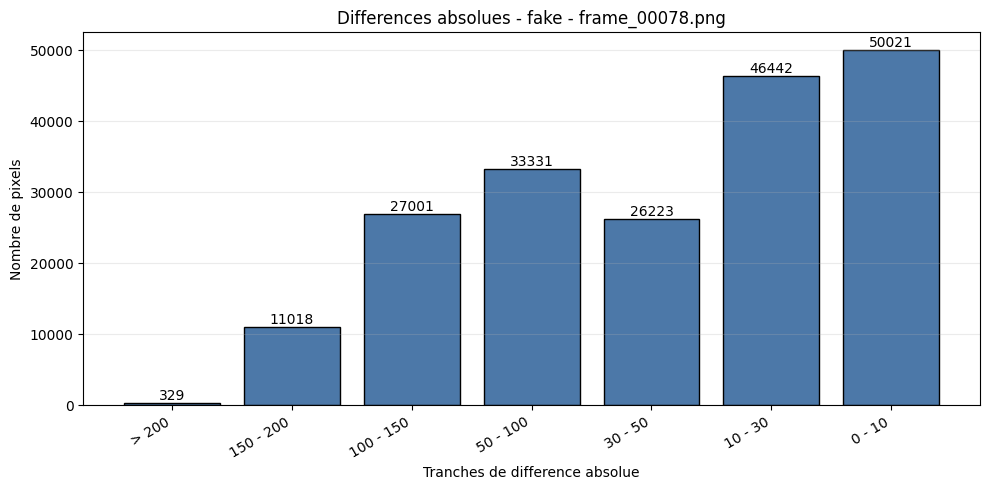

lvl:  4  initial error:  6353.142719382833
 error improvement too small, level converged! it:  5  error:  4314.059097748966  lambda:  1.6
lvl:  3  initial error:  4690.907402156825
 error improvement too small, level converged! it:  3  error:  4645.010196206828  lambda:  0.2
lvl:  2  initial error:  4859.385630714799
 error improvement too small, level converged! it:  1  error:  4855.822360187805  lambda:  0.1
[fake] frame 79 -> frame_00079.png | sum error = 983809984.00 | mean abs error = 50.1119 | valid pixels = 194506


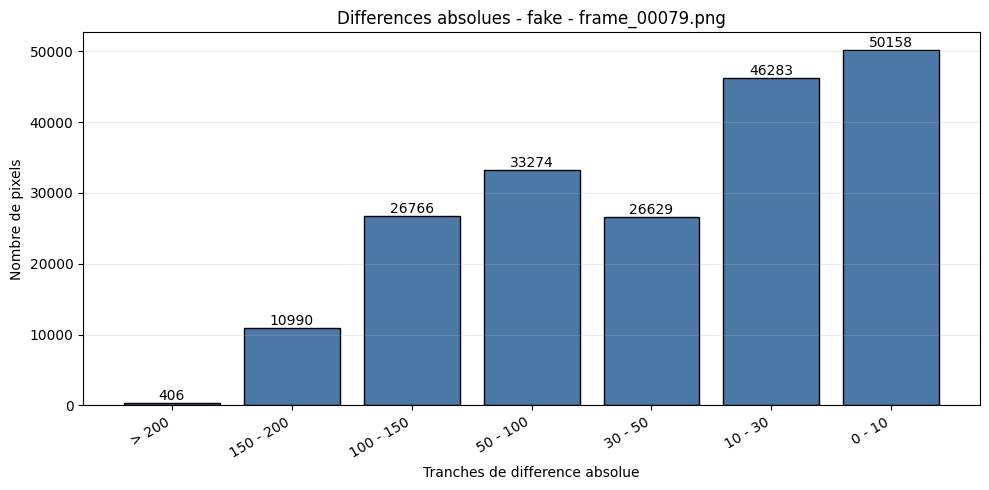

xFormers not available
xFormers not available


Depth Anything loaded on cpu (97.47M parameters)
lvl:  4  initial error:  6415.049180327868
 error improvement too small, level converged! it:  8  error:  4402.373362699145  lambda:  0.0
lvl:  3  initial error:  4625.769855097692
 error improvement too small, level converged! it:  3  error:  4575.929549215903  lambda:  0.1
lvl:  2  initial error:  4821.895625674632
 error improvement too small, level converged! it:  2  error:  4813.640489720384  lambda:  0.0
[fake] frame 80 -> frame_00080.png | sum error = 967907392.00 | mean abs error = 49.9861 | valid pixels = 193473


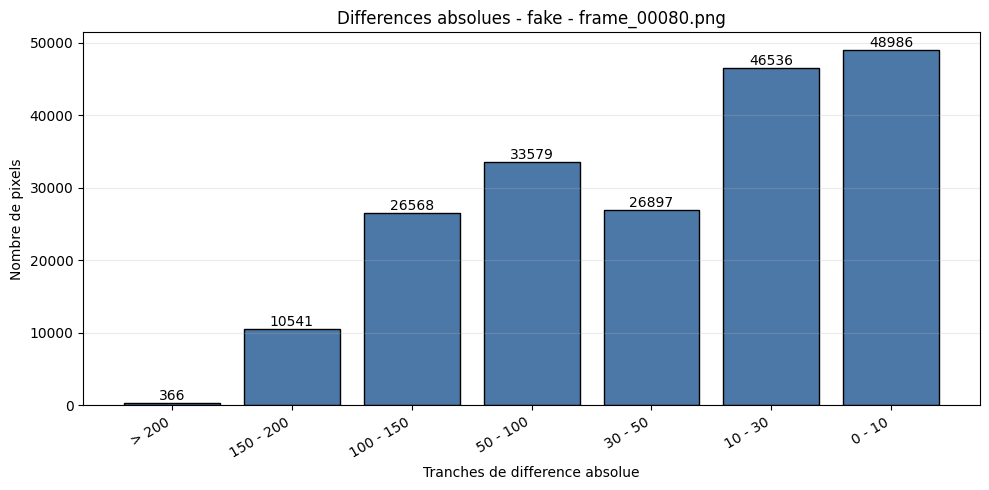

lvl:  4  initial error:  6456.267116682739
 error improvement too small, level converged! it:  4  error:  4479.005575489945  lambda:  12.8
lvl:  3  initial error:  4597.649103046986
 error improvement too small, level converged! it:  5  error:  4497.985595639277  lambda:  6.4
lvl:  2  initial error:  4756.244413919098
 error improvement too small, level converged! it:  1  error:  4755.526179533056  lambda:  0.1
[fake] frame 81 -> frame_00081.png | sum error = 950579712.00 | mean abs error = 49.9523 | valid pixels = 191983


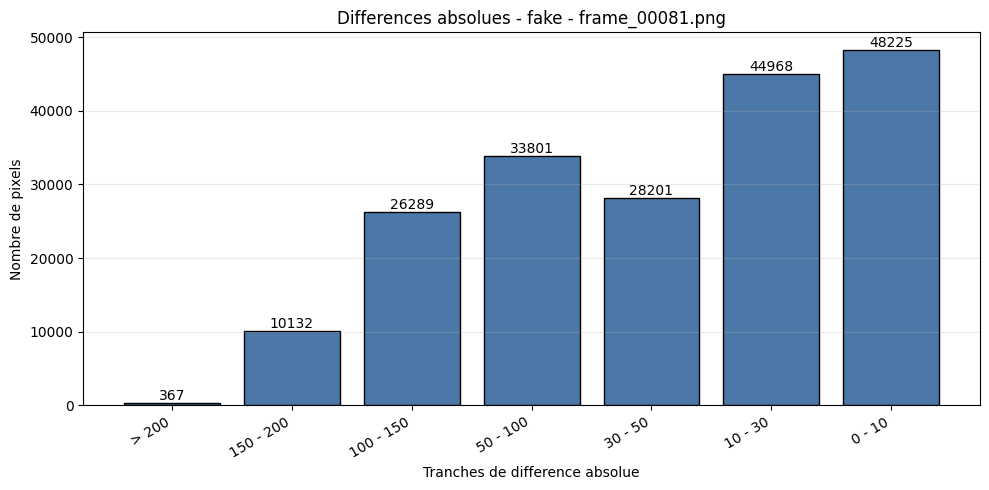

lvl:  4  initial error:  6411.070395371264
update too small, level converged! it:  3  error:  4508.740576373455  lambda:  3602879701896397.0
lvl:  3  initial error:  4602.363811155063
 error improvement too small, level converged! it:  3  error:  4507.24883295146  lambda:  0.2
lvl:  2  initial error:  4773.309893935491
 error improvement too small, level converged! it:  1  error:  4770.490896354996  lambda:  0.0
[fake] frame 82 -> frame_00082.png | sum error = 943692096.00 | mean abs error = 50.1401 | valid pixels = 190767


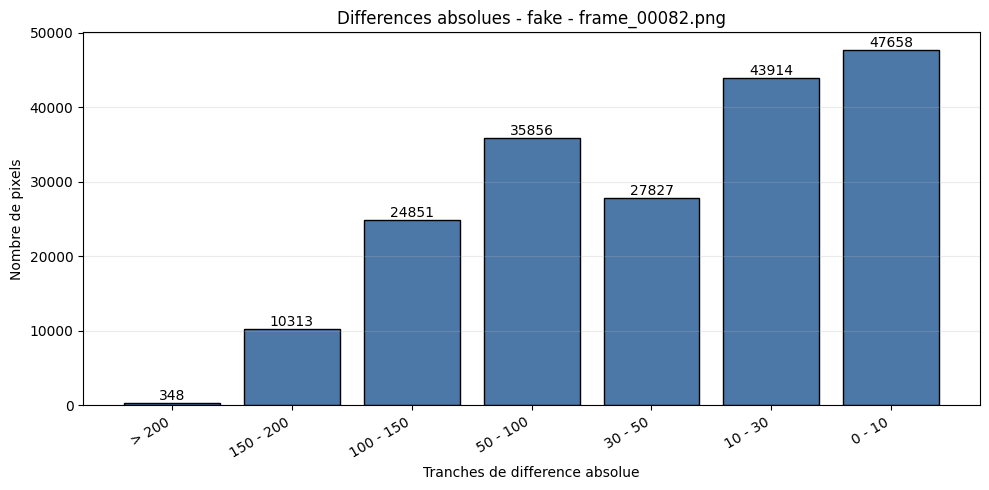

lvl:  4  initial error:  6349.216007714561
 error improvement too small, level converged! it:  3  error:  4762.112670427033  lambda:  3.2
lvl:  3  initial error:  4735.944144463411
 error improvement too small, level converged! it:  6  error:  4619.112993980616  lambda:  439804651110.4
lvl:  2  initial error:  4870.33782305103
 error improvement too small, level converged! it:  2  error:  4861.010437122198  lambda:  0.2
[fake] frame 83 -> frame_00083.png | sum error = 962722560.00 | mean abs error = 50.6297 | valid pixels = 190956


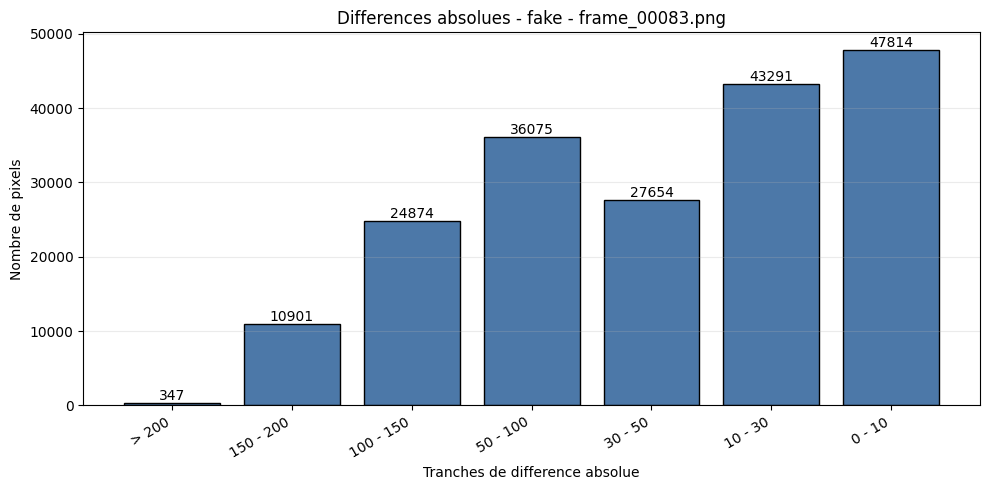

lvl:  4  initial error:  6342.859209257474
 error improvement too small, level converged! it:  3  error:  4748.07468109146  lambda:  3.2
lvl:  3  initial error:  4862.8245708816185
 error improvement too small, level converged! it:  3  error:  4803.618386414635  lambda:  6.4
lvl:  2  initial error:  5057.32129527336
 error improvement too small, level converged! it:  1  error:  5056.784084795085  lambda:  0.0
[fake] frame 84 -> frame_00084.png | sum error = 1025785984.00 | mean abs error = 51.9037 | valid pixels = 195435


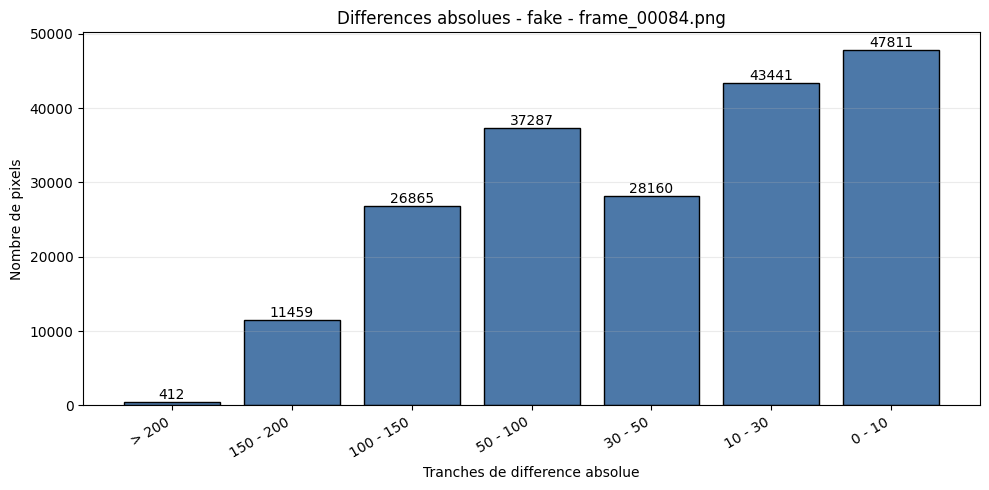

lvl:  4  initial error:  6409.0289296046285
 error improvement too small, level converged! it:  4  error:  4892.5376138974625  lambda:  0.4
lvl:  3  initial error:  4832.687763124923
 error improvement too small, level converged! it:  13  error:  4566.105754343596  lambda:  0.0
lvl:  2  initial error:  4851.959336656581
 error improvement too small, level converged! it:  1  error:  4851.820762896161  lambda:  6.4
[fake] frame 85 -> frame_00085.png | sum error = 973345152.00 | mean abs error = 50.8272 | valid pixels = 192666


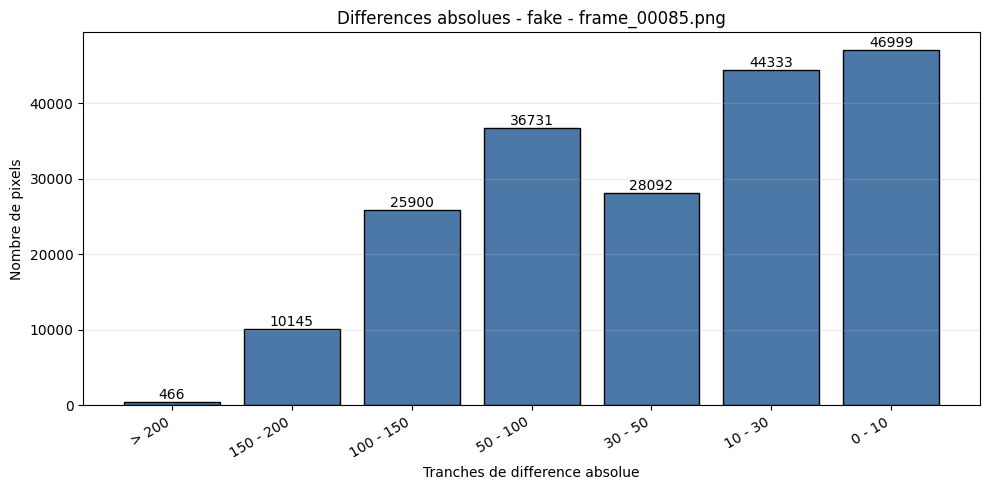

lvl:  4  initial error:  6534.368370298939
 error improvement too small, level converged! it:  4  error:  4628.916331575567  lambda:  6.4
lvl:  3  initial error:  4682.539738481381
 error improvement too small, level converged! it:  3  error:  4630.672135463539  lambda:  102.4
lvl:  2  initial error:  4883.916896056784
 error improvement too small, level converged! it:  1  error:  4883.8028717375355  lambda:  25.6
[fake] frame 86 -> frame_00086.png | sum error = 978925440.00 | mean abs error = 51.1759 | valid pixels = 192616


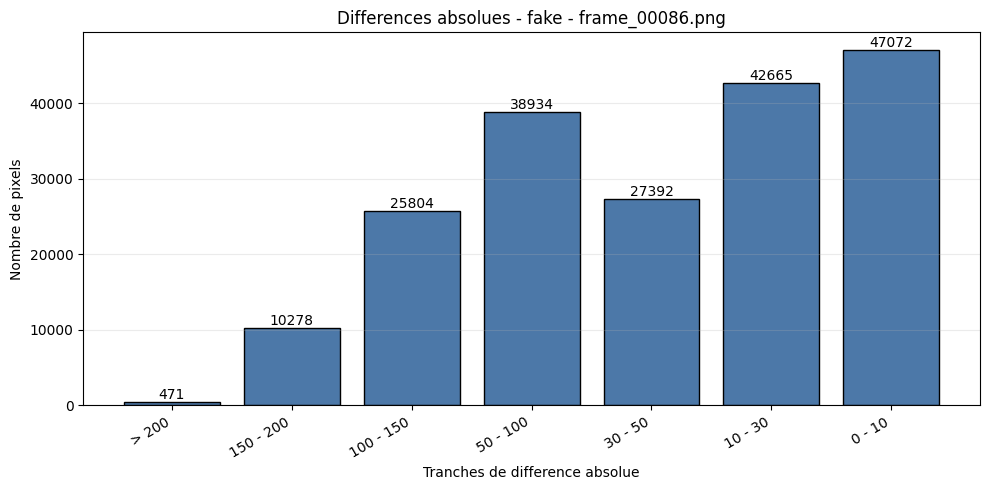

lvl:  4  initial error:  6678.553519768562
 error improvement too small, level converged! it:  4  error:  4675.020462186301  lambda:  0.1
lvl:  3  initial error:  4660.51273646929
 error improvement too small, level converged! it:  2  error:  4652.998096778962  lambda:  25.6
lvl:  2  initial error:  4927.186647778581
 error improvement too small, level converged! it:  1  error:  4926.623678738487  lambda:  0.0
[fake] frame 87 -> frame_00087.png | sum error = 987648960.00 | mean abs error = 51.1211 | valid pixels = 193316


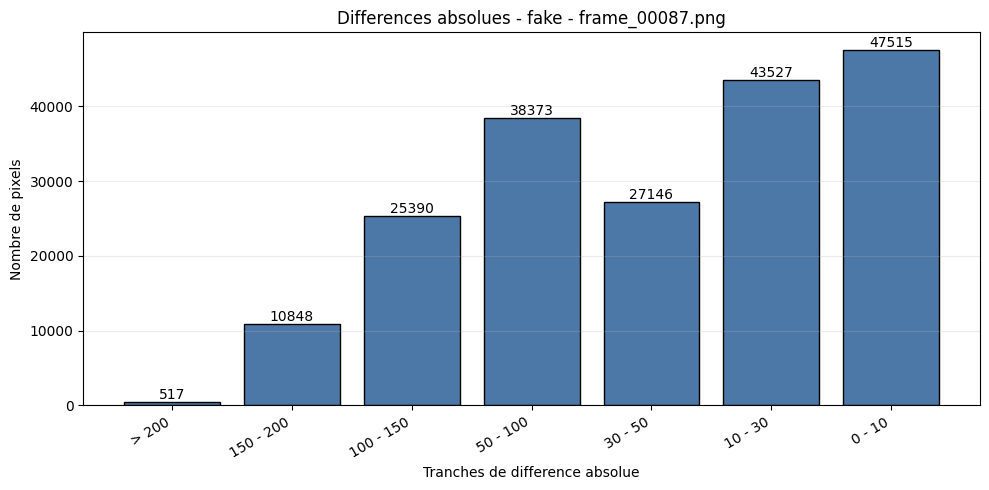

lvl:  4  initial error:  6538.105110896817
 error improvement too small, level converged! it:  2  error:  4693.381925830735  lambda:  0.0
lvl:  3  initial error:  4770.8765265495185
 error improvement too small, level converged! it:  4  error:  4654.022136047184  lambda:  0.1
lvl:  2  initial error:  4934.855870950367
 error improvement too small, level converged! it:  1  error:  4931.6173102428065  lambda:  0.0
[fake] frame 88 -> frame_00088.png | sum error = 979591360.00 | mean abs error = 50.8083 | valid pixels = 192089


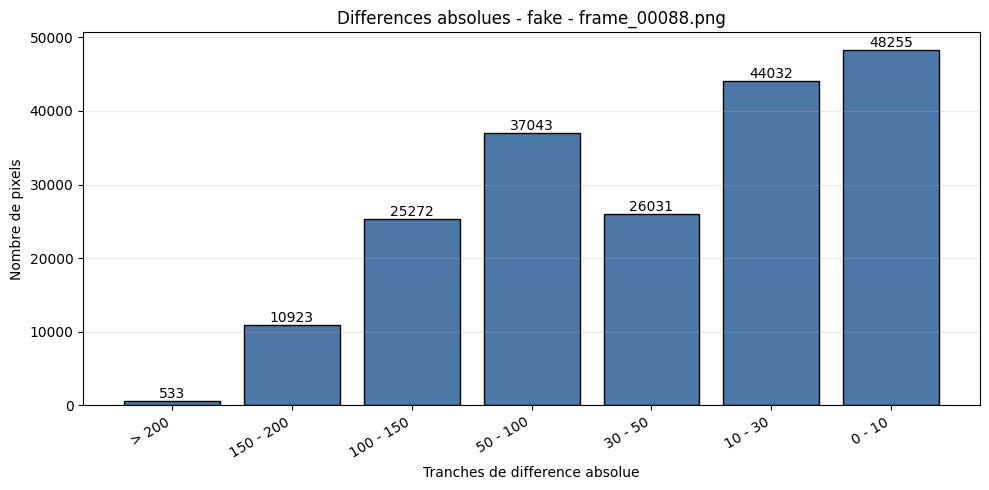

lvl:  4  initial error:  6272.322082931532
 error improvement too small, level converged! it:  5  error:  4660.0665530826445  lambda:  3.2
lvl:  3  initial error:  4845.809327647627
 error improvement too small, level converged! it:  3  error:  4767.320719887243  lambda:  0.0
lvl:  2  initial error:  5060.292337751477
 error improvement too small, level converged! it:  1  error:  5059.824693432226  lambda:  0.1
[fake] frame 89 -> frame_00089.png | sum error = 1046057600.00 | mean abs error = 51.8910 | valid pixels = 198577


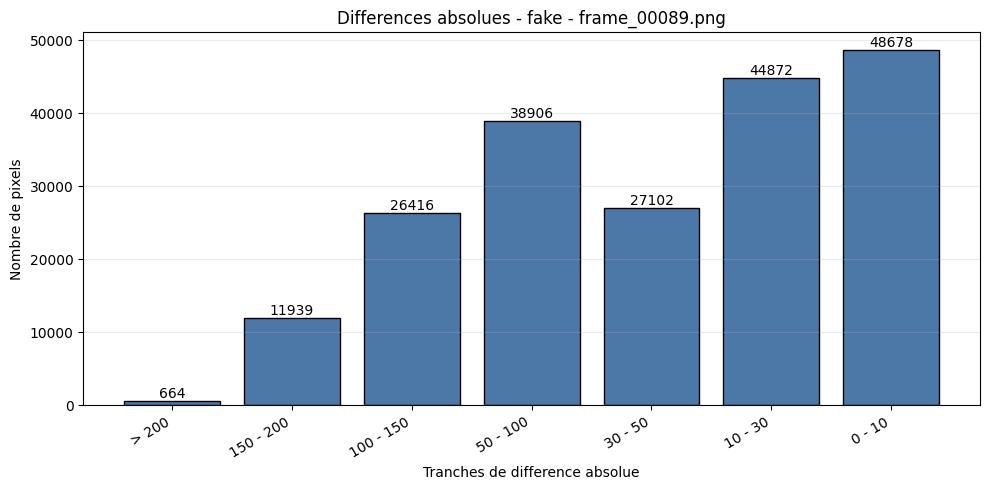

lvl:  4  initial error:  6115.118611378977
 error improvement too small, level converged! it:  4  error:  4551.5246858830915  lambda:  6.4
lvl:  3  initial error:  4756.910932292163
 error improvement too small, level converged! it:  5  error:  4674.558399903911  lambda:  0.4
lvl:  2  initial error:  4990.332453178749
 error improvement too small, level converged! it:  4  error:  4965.906241988449  lambda:  0.0
[fake] frame 90 -> frame_00090.png | sum error = 1036912768.00 | mean abs error = 51.1066 | valid pixels = 200428


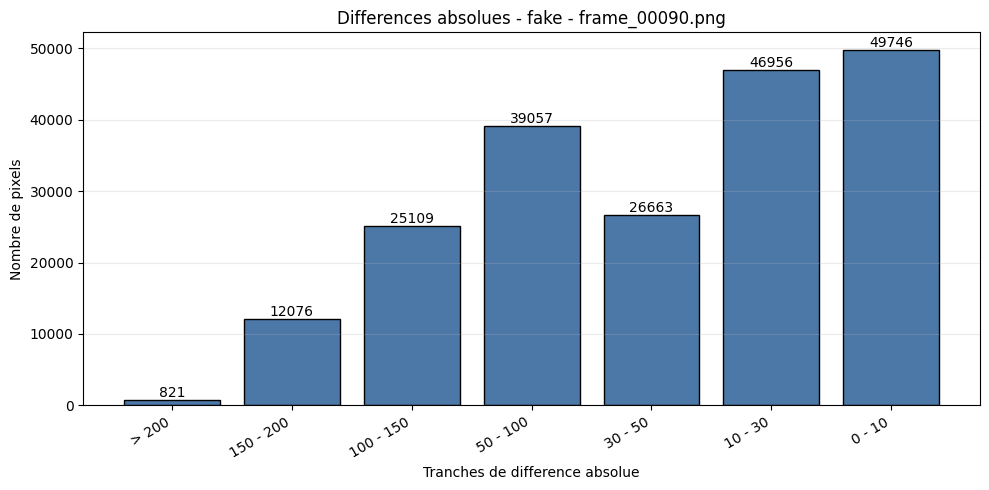

lvl:  4  initial error:  5985.380906460944
 error improvement too small, level converged! it:  5  error:  4431.808352111164  lambda:  1.6
lvl:  3  initial error:  4660.414867260571
 error improvement too small, level converged! it:  4  error:  4595.232716695951  lambda:  0.0
lvl:  2  initial error:  4806.873577998509
 error improvement too small, level converged! it:  1  error:  4806.01392107333  lambda:  0.0
[fake] frame 91 -> frame_00091.png | sum error = 995478080.00 | mean abs error = 50.4057 | valid pixels = 198690


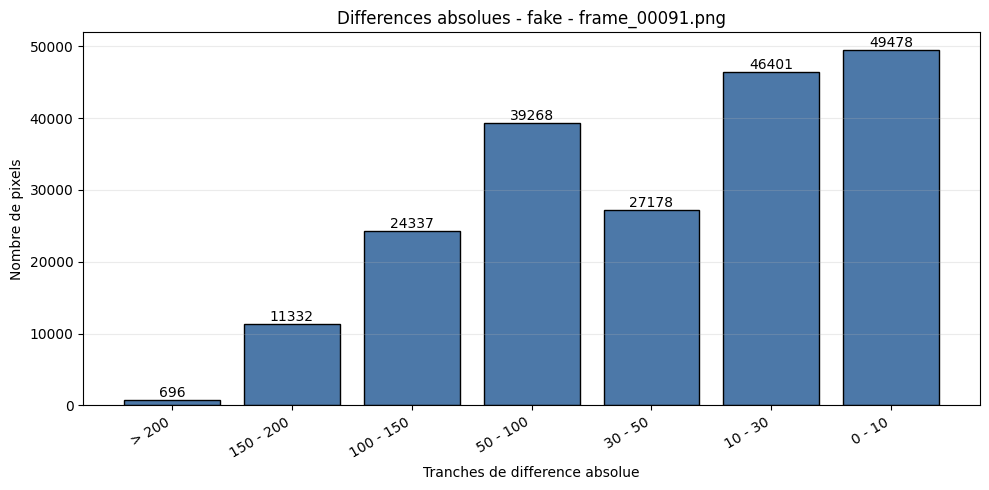

lvl:  4  initial error:  5900.858244937318
 error improvement too small, level converged! it:  5  error:  4269.934304084158  lambda:  6.4
lvl:  3  initial error:  4513.107306377568
 error improvement too small, level converged! it:  2  error:  4491.714509093619  lambda:  0.1
lvl:  2  initial error:  4698.990133467757
 error improvement too small, level converged! it:  1  error:  4698.073583192478  lambda:  0.0
[fake] frame 92 -> frame_00092.png | sum error = 987629056.00 | mean abs error = 50.0694 | valid pixels = 200412


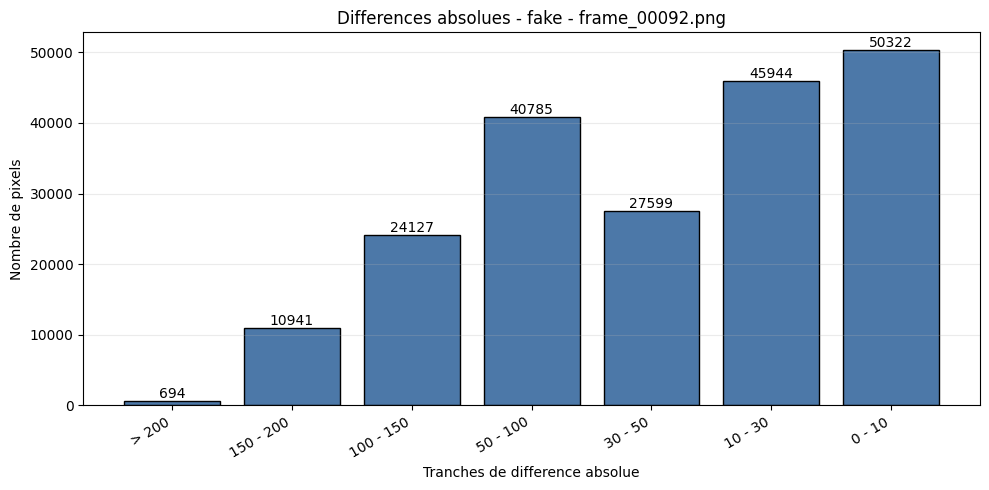

lvl:  4  initial error:  5890.716489874637
 error improvement too small, level converged! it:  4  error:  4210.573037506357  lambda:  3518437208883.2
lvl:  3  initial error:  4401.411479065985
 error improvement too small, level converged! it:  4  error:  4370.34976792036  lambda:  0.2
lvl:  2  initial error:  4654.601529540154
 error improvement too small, level converged! it:  2  error:  4638.674984958508  lambda:  0.0
[fake] frame 93 -> frame_00093.png | sum error = 980015232.00 | mean abs error = 49.8111 | valid pixels = 201715


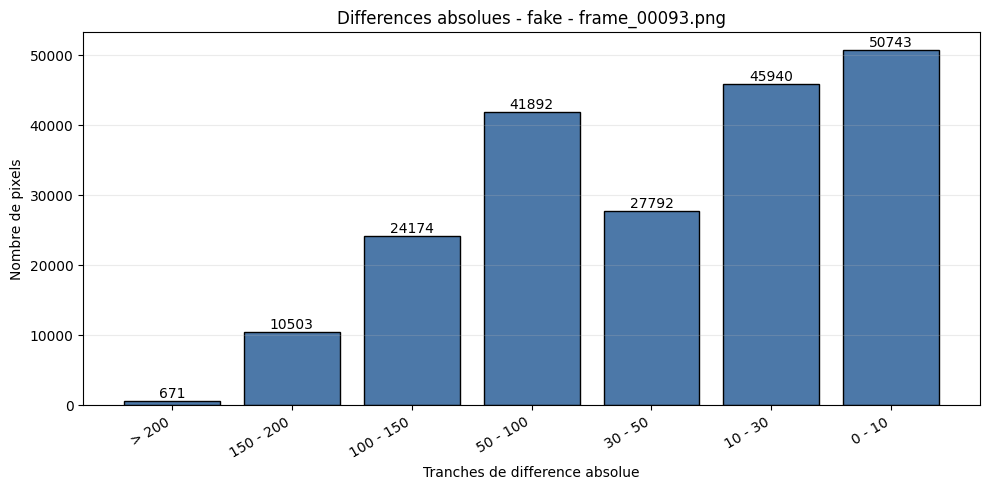

lvl:  4  initial error:  5813.320154291224
 error improvement too small, level converged! it:  4  error:  4122.015439750281  lambda:  6.4
lvl:  3  initial error:  4343.896607707331
 error improvement too small, level converged! it:  2  error:  4333.991058875887  lambda:  879609302220.8
lvl:  2  initial error:  4612.313169675431
 error improvement too small, level converged! it:  5  error:  4578.489756857287  lambda:  0.0
[fake] frame 94 -> frame_00094.png | sum error = 962546304.00 | mean abs error = 49.4714 | valid pixels = 200708


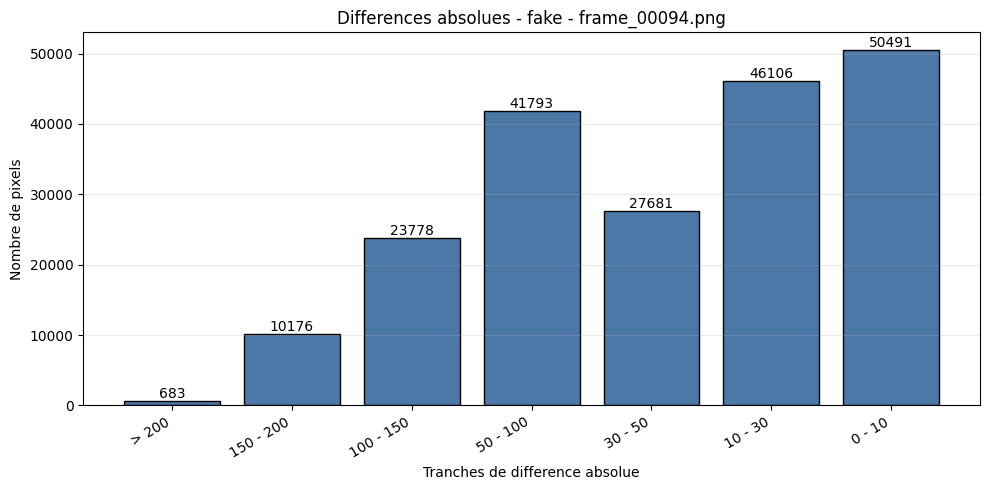

lvl:  4  initial error:  5669.0675024107995
 error improvement too small, level converged! it:  2  error:  4127.887476272086  lambda:  0.1
lvl:  3  initial error:  4326.135219666152
 error improvement too small, level converged! it:  1  error:  4323.34335925349  lambda:  0.0
lvl:  2  initial error:  4595.758155214175
 error improvement too small, level converged! it:  1  error:  4593.572159608687  lambda:  0.0
[fake] frame 95 -> frame_00095.png | sum error = 964217280.00 | mean abs error = 49.6024 | valid pixels = 200769


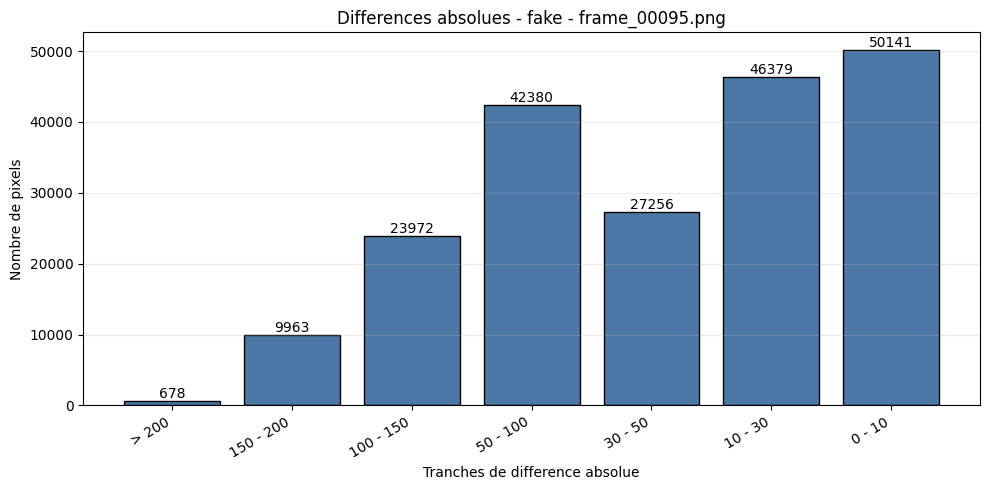

lvl:  4  initial error:  5596.6788813886205
update too small, level converged! it:  11  error:  4034.128071681092  lambda:  900719925474099.2
lvl:  3  initial error:  4223.29511926602
 error improvement too small, level converged! it:  3  error:  4207.953287758725  lambda:  0.0
lvl:  2  initial error:  4419.401986595508
 error improvement too small, level converged! it:  5  error:  4388.716685419672  lambda:  0.0
[fake] frame 96 -> frame_00096.png | sum error = 904277504.00 | mean abs error = 48.0788 | valid pixels = 196768


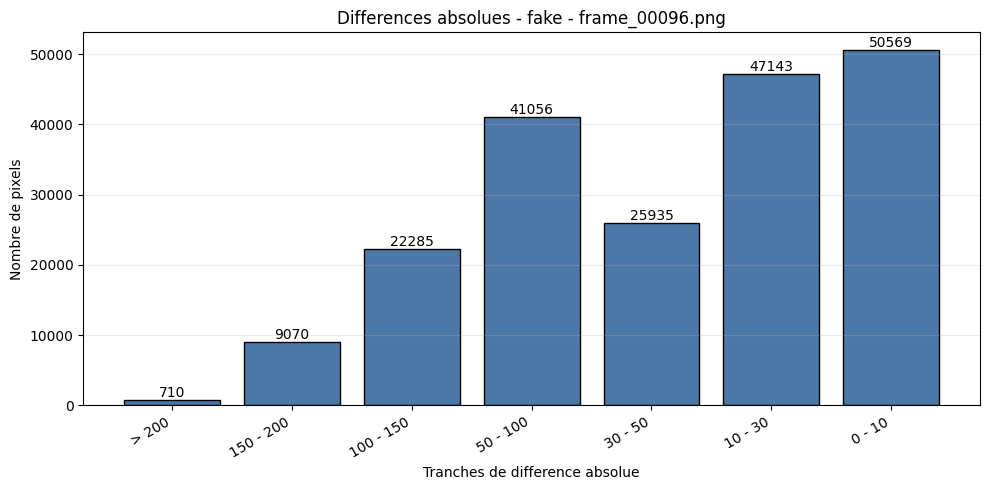

lvl:  4  initial error:  5724.459016393442
 error improvement too small, level converged! it:  3  error:  4075.2450364181464  lambda:  0.1
lvl:  3  initial error:  4251.5553067331
 error improvement too small, level converged! it:  1  error:  4248.214851570403  lambda:  0.0
lvl:  2  initial error:  4487.192089799047
 error improvement too small, level converged! it:  4  error:  4454.962506181373  lambda:  0.0
[fake] frame 97 -> frame_00097.png | sum error = 935232128.00 | mean abs error = 48.6211 | valid pixels = 200539


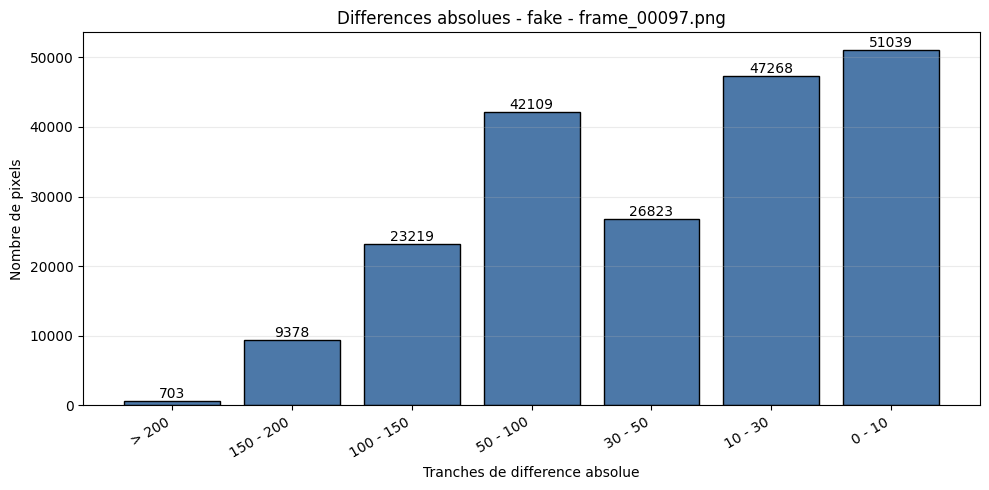

lvl:  4  initial error:  5793.9672131147545
 error improvement too small, level converged! it:  2  error:  4120.302583359892  lambda:  0.0
lvl:  3  initial error:  4248.500951589458
 error improvement too small, level converged! it:  2  error:  4224.343781431047  lambda:  0.8
lvl:  2  initial error:  4492.396485935648
 error improvement too small, level converged! it:  2  error:  4487.546381295672  lambda:  0.0
[fake] frame 98 -> frame_00098.png | sum error = 931953344.00 | mean abs error = 48.7110 | valid pixels = 199080


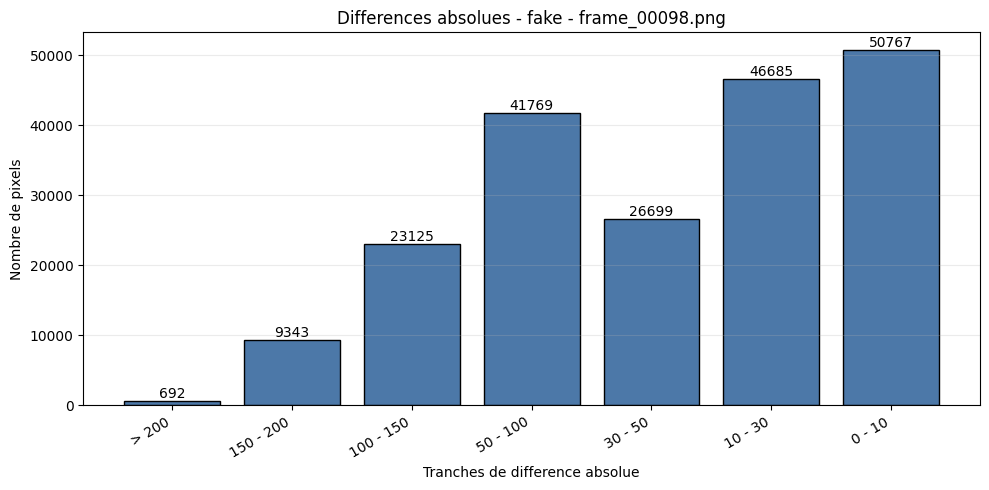

lvl:  4  initial error:  6002.551591128254
 error improvement too small, level converged! it:  4  error:  4196.891582268221  lambda:  6.4
lvl:  3  initial error:  4272.9550271916905
 error improvement too small, level converged! it:  2  error:  4231.49156121002  lambda:  879609302220.8
lvl:  2  initial error:  4523.739727650427
 error improvement too small, level converged! it:  1  error:  4520.117038563258  lambda:  0.0
[fake] frame 99 -> frame_00099.png | sum error = 933361856.00 | mean abs error = 48.9880 | valid pixels = 197471


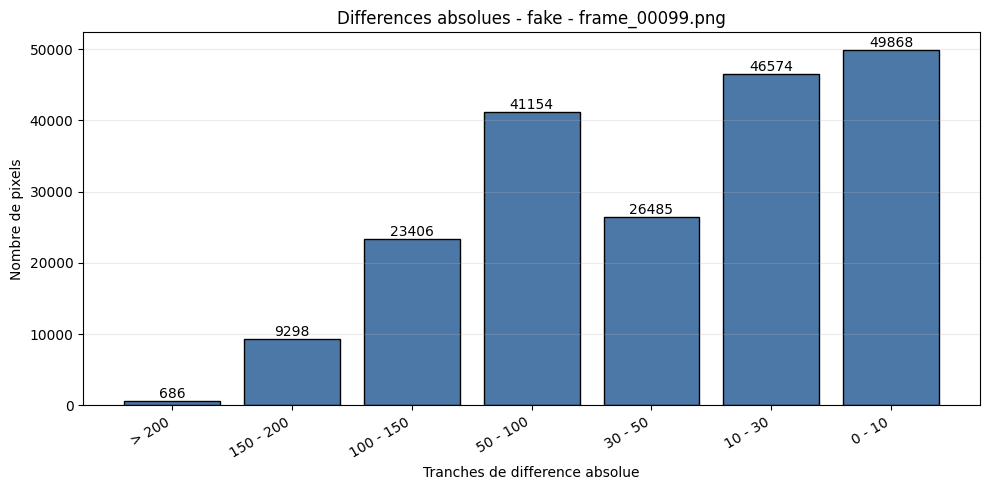

lvl:  4  initial error:  6078.008678881388
 error improvement too small, level converged! it:  4  error:  4322.6719270201265  lambda:  12.8
lvl:  3  initial error:  4367.037311438529
 error improvement too small, level converged! it:  2  error:  4349.402220466099  lambda:  0.0
lvl:  2  initial error:  4552.584054621813
 error improvement too small, level converged! it:  1  error:  4549.671063866121  lambda:  0.0
[fake] frame 100 -> frame_00100.png | sum error = 941758592.00 | mean abs error = 49.1885 | valid pixels = 197511


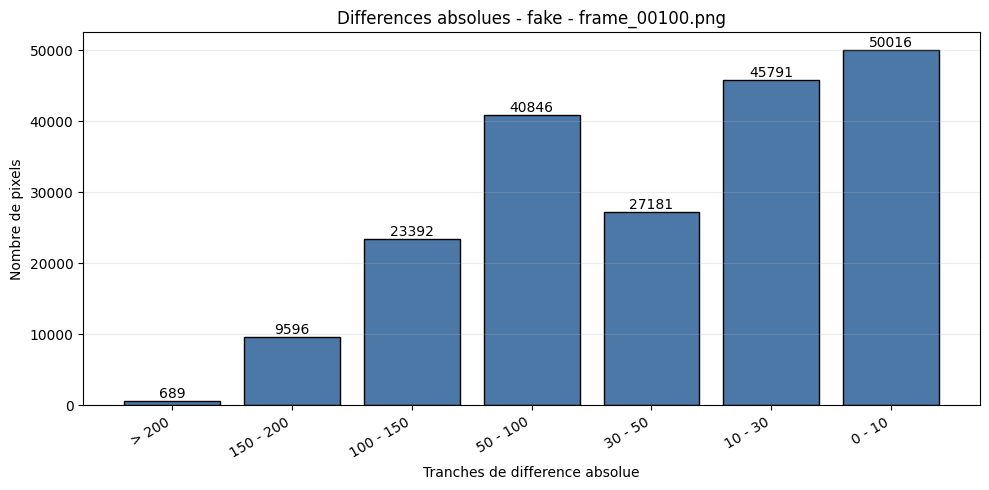

lvl:  4  initial error:  6075.862102217936
 error improvement too small, level converged! it:  2  error:  4361.408241768905  lambda:  25.6
lvl:  3  initial error:  4440.430556255215
 error improvement too small, level converged! it:  2  error:  4413.356990268294  lambda:  0.0
lvl:  2  initial error:  4604.755579223691
 error improvement too small, level converged! it:  2  error:  4595.084668554469  lambda:  0.0
[fake] frame 101 -> frame_00101.png | sum error = 940317056.00 | mean abs error = 49.3837 | valid pixels = 195752


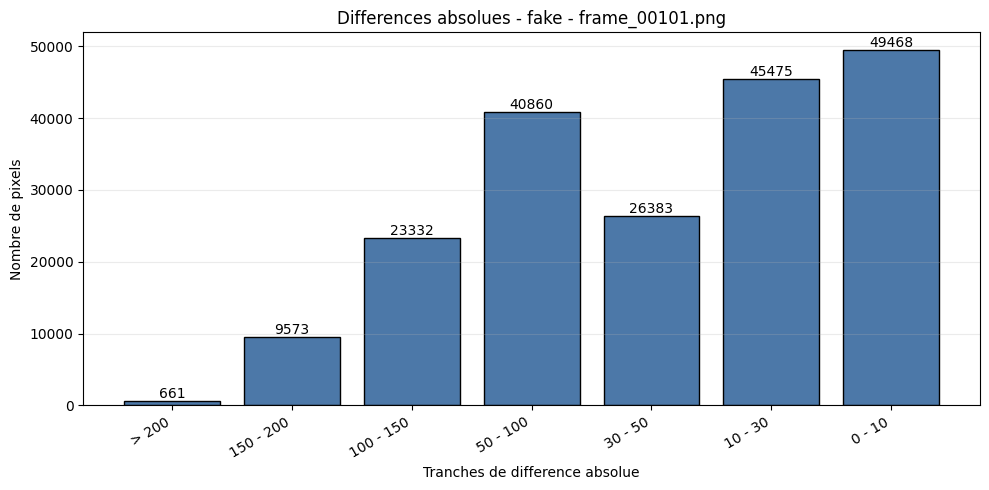

lvl:  4  initial error:  6101.367405978784
 error improvement too small, level converged! it:  3  error:  4435.041115122571  lambda:  879609302220.8
lvl:  3  initial error:  4496.697309422799
 error improvement too small, level converged! it:  5  error:  4457.387749388702  lambda:  0.0
lvl:  2  initial error:  4708.553553938397
 error improvement too small, level converged! it:  1  error:  4705.937947371286  lambda:  0.0
[fake] frame 102 -> frame_00102.png | sum error = 954136064.00 | mean abs error = 50.0523 | valid pixels = 194752


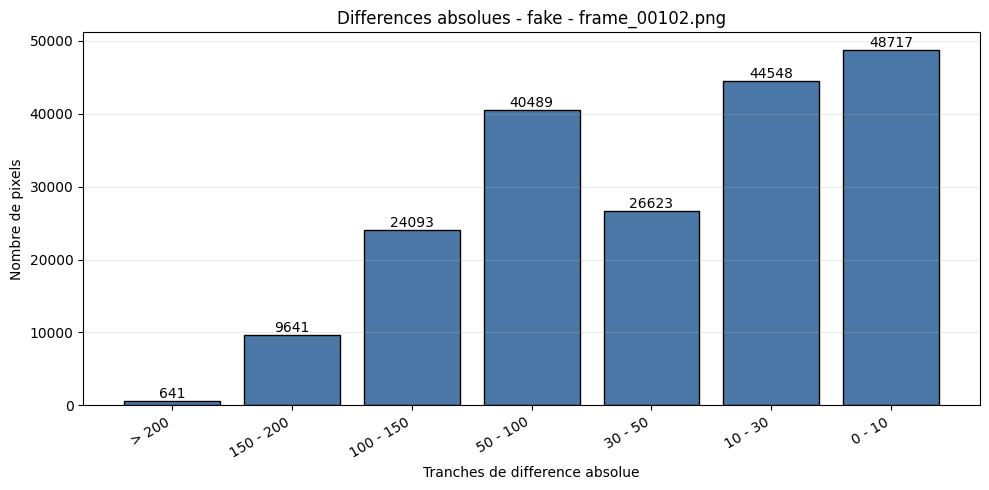

lvl:  4  initial error:  6246.499517839922
 error improvement too small, level converged! it:  7  error:  4505.973043460122  lambda:  25.6
lvl:  3  initial error:  4681.911675685698
 error improvement too small, level converged! it:  3  error:  4603.093467309199  lambda:  51.2
lvl:  2  initial error:  4875.291965841908
 error improvement too small, level converged! it:  1  error:  4871.461776178444  lambda:  0.0
[fake] frame 103 -> frame_00103.png | sum error = 997102400.00 | mean abs error = 51.2823 | valid pixels = 195543


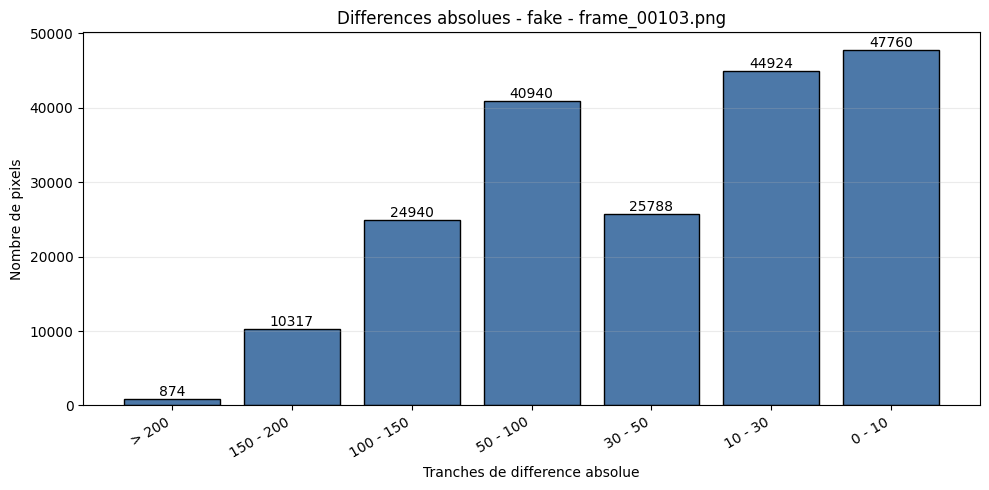

lvl:  4  initial error:  6344.703953712632
 error improvement too small, level converged! it:  6  error:  4405.945319119421  lambda:  1.6
lvl:  3  initial error:  4867.162637558394
 error improvement too small, level converged! it:  2  error:  4845.023993235958  lambda:  0.0
lvl:  2  initial error:  5129.414221319924
 error improvement too small, level converged! it:  1  error:  5126.844710236006  lambda:  0.0
[fake] frame 104 -> frame_00104.png | sum error = 1032137536.00 | mean abs error = 52.8196 | valid pixels = 192417


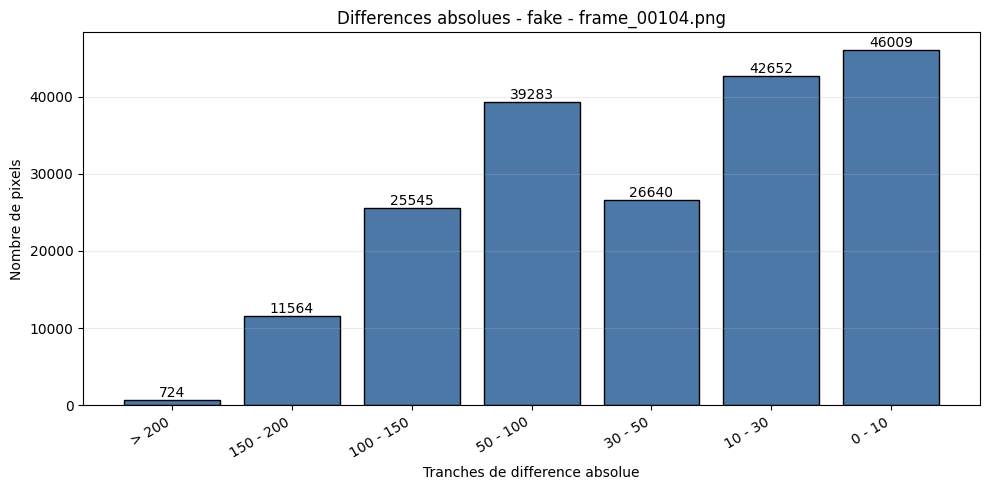

lvl:  4  initial error:  6482.286403085823
 error improvement too small, level converged! it:  4  error:  4528.283755806377  lambda:  14073748835532.8
lvl:  3  initial error:  5169.78872062695
 error improvement too small, level converged! it:  2  error:  5138.5383357829405  lambda:  0.0
lvl:  2  initial error:  5369.400173123828
 error improvement too small, level converged! it:  1  error:  5364.934370107354  lambda:  0.0
[fake] frame 105 -> frame_00105.png | sum error = 1064641984.00 | mean abs error = 54.3573 | valid pixels = 188842


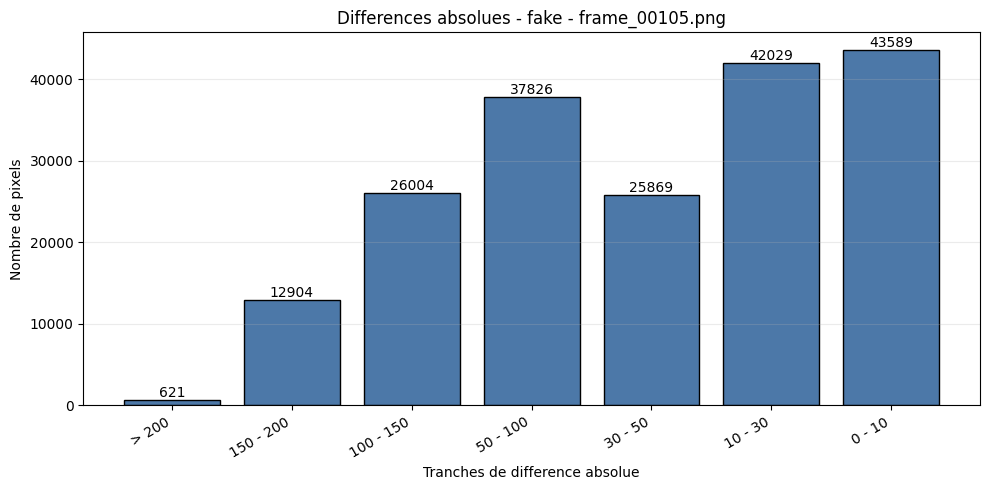

lvl:  4  initial error:  6805.0405014464795
 error improvement too small, level converged! it:  8  error:  4458.045113036756  lambda:  1.6
lvl:  3  initial error:  5164.480267259351
 error improvement too small, level converged! it:  2  error:  5144.053783782904  lambda:  25.6
lvl:  2  initial error:  5333.099395249729
 error improvement too small, level converged! it:  1  error:  5331.503811468673  lambda:  0.0
[fake] frame 106 -> frame_00106.png | sum error = 1046300864.00 | mean abs error = 54.3120 | valid pixels = 187441


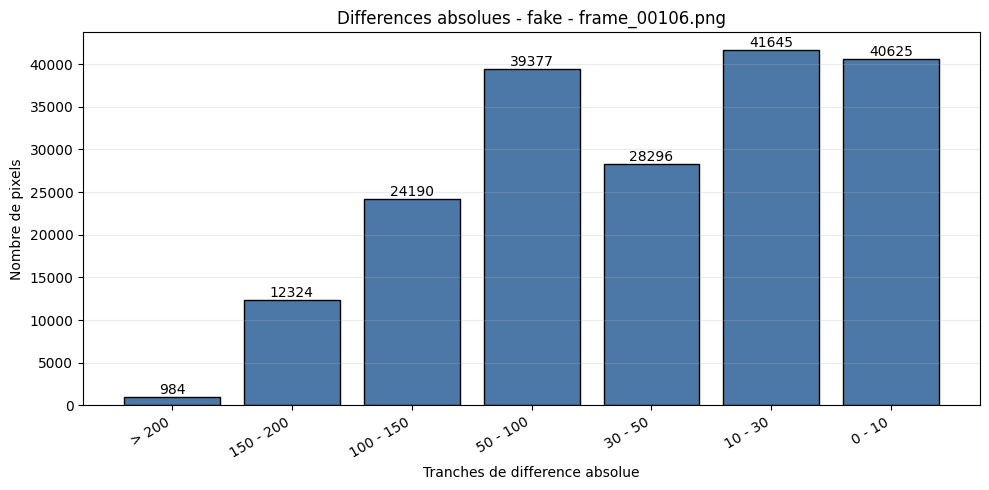

lvl:  4  initial error:  7313.126325940211
 error improvement too small, level converged! it:  2  error:  4715.856817005553  lambda:  3.2
lvl:  3  initial error:  5380.708669678822
 error improvement too small, level converged! it:  1  error:  5380.526138776503  lambda:  1.6
lvl:  2  initial error:  5619.1502922936525
 error improvement too small, level converged! it:  2  error:  5608.429561922829  lambda:  0.0
[fake] frame 107 -> frame_00107.png | sum error = 1094403200.00 | mean abs error = 55.8083 | valid pixels = 187640


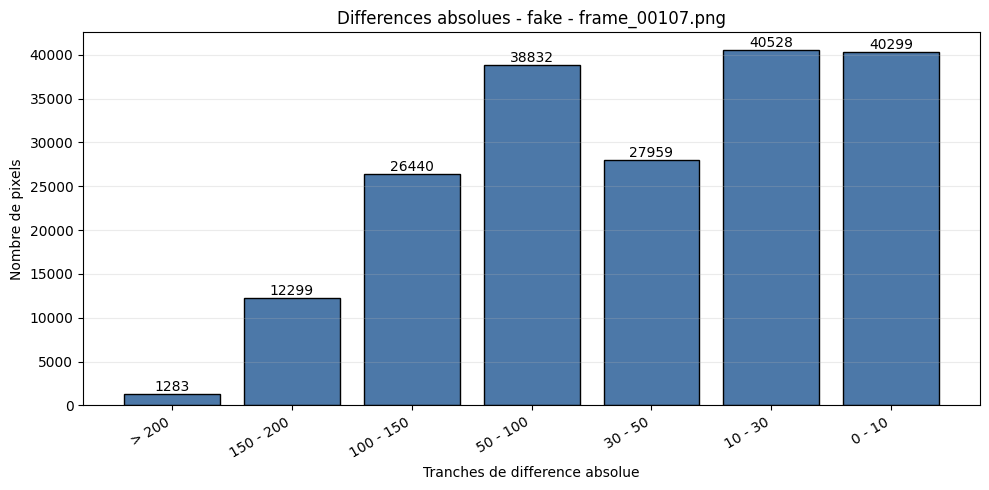

lvl:  4  initial error:  7968.408871745419
 error improvement too small, level converged! it:  2  error:  5210.888259546912  lambda:  0.1
lvl:  3  initial error:  5656.91708466783
 error improvement too small, level converged! it:  4  error:  5612.6515815326975  lambda:  3276.8
lvl:  2  initial error:  5860.216123344148
 error improvement too small, level converged! it:  1  error:  5860.113148233627  lambda:  0.2
[fake] frame 108 -> frame_00108.png | sum error = 1130974336.00 | mean abs error = 57.5373 | valid pixels = 186521


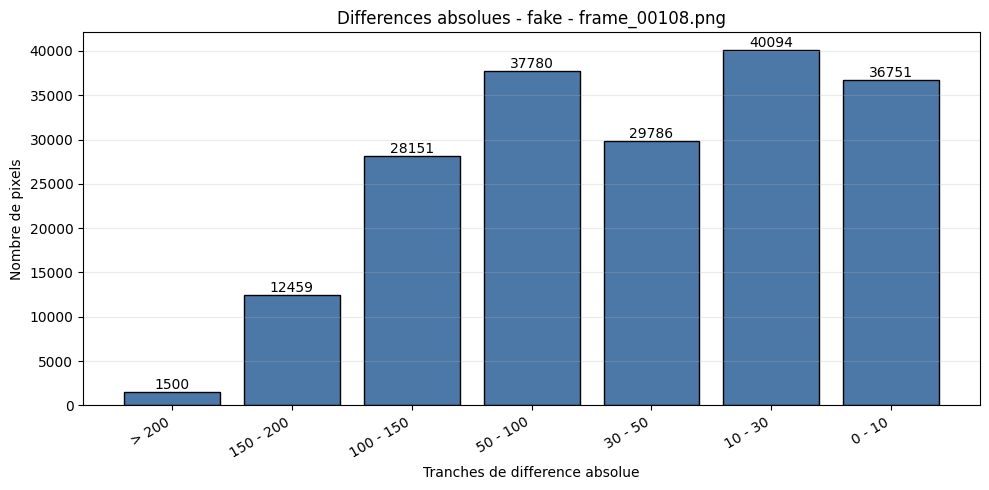

lvl:  4  initial error:  8740.509161041466
 error improvement too small, level converged! it:  6  error:  5555.493115470708  lambda:  25.6
lvl:  3  initial error:  5999.299119699575
 error improvement too small, level converged! it:  1  error:  5998.424006236161  lambda:  0.0
lvl:  2  initial error:  6235.681126887058
 error improvement too small, level converged! it:  2  error:  6225.14840573943  lambda:  25.6
[fake] frame 109 -> frame_00109.png | sum error = 1305091712.00 | mean abs error = 59.7745 | valid pixels = 201437


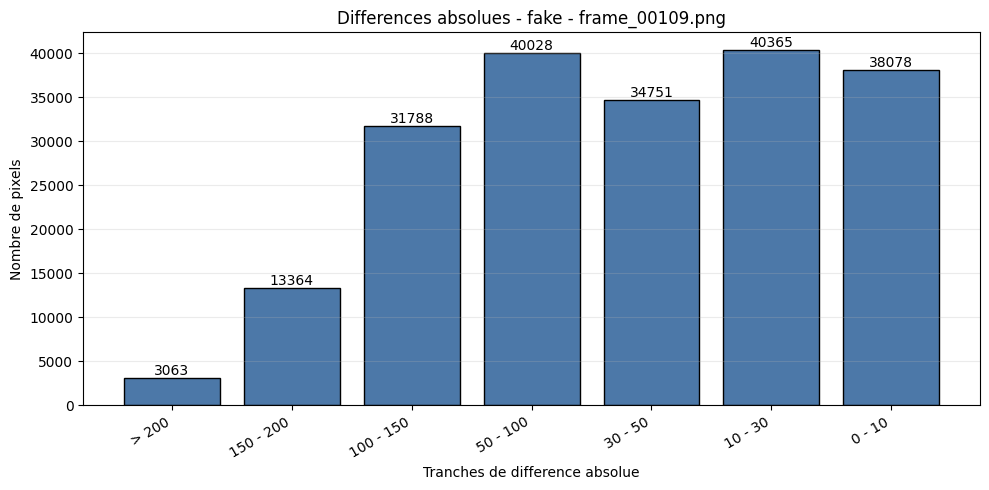

lvl:  4  initial error:  9271.113789778206
 error improvement too small, level converged! it:  7  error:  6127.136896737429  lambda:  409.6
lvl:  3  initial error:  6514.176923271688
 error improvement too small, level converged! it:  1  error:  6514.04832285677  lambda:  51.2
lvl:  2  initial error:  6778.655650262904
 error improvement too small, level converged! it:  5  error:  6720.324007628198  lambda:  0.0
[fake] frame 110 -> frame_00110.png | sum error = 1436430080.00 | mean abs error = 62.3773 | valid pixels = 206727


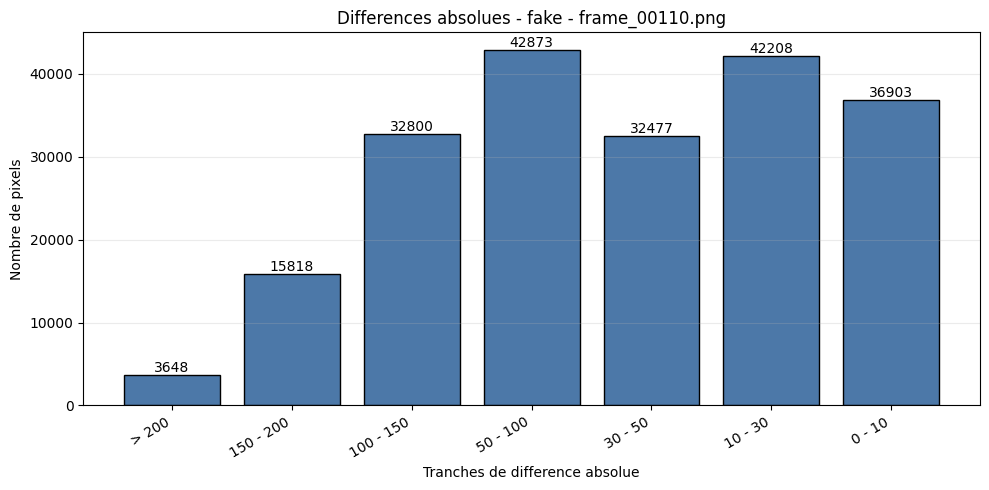

lvl:  4  initial error:  9698.995178399227
 error improvement too small, level converged! it:  5  error:  6453.699333301716  lambda:  0.2
lvl:  3  initial error:  6784.416593834427
 error improvement too small, level converged! it:  9  error:  6591.391640925506  lambda:  3.2
lvl:  2  initial error:  6885.355641247547
 error improvement too small, level converged! it:  1  error:  6881.062155209241  lambda:  0.0
[fake] frame 111 -> frame_00111.png | sum error = 1510771328.00 | mean abs error = 63.7210 | valid pixels = 211066


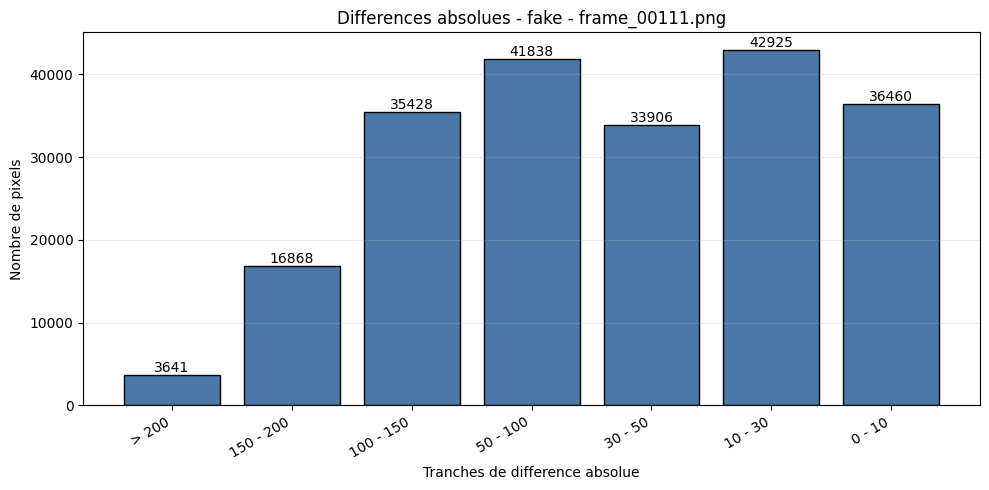

lvl:  4  initial error:  9715.887174541946
 error improvement too small, level converged! it:  12  error:  6640.866574439915  lambda:  0.2
lvl:  3  initial error:  6890.731281105509
 error improvement too small, level converged! it:  2  error:  6873.004753321966  lambda:  3.2
lvl:  2  initial error:  7168.292615468961
 error improvement too small, level converged! it:  1  error:  7165.904486733208  lambda:  0.0
[fake] frame 112 -> frame_00112.png | sum error = 1522388736.00 | mean abs error = 66.5335 | valid pixels = 203960


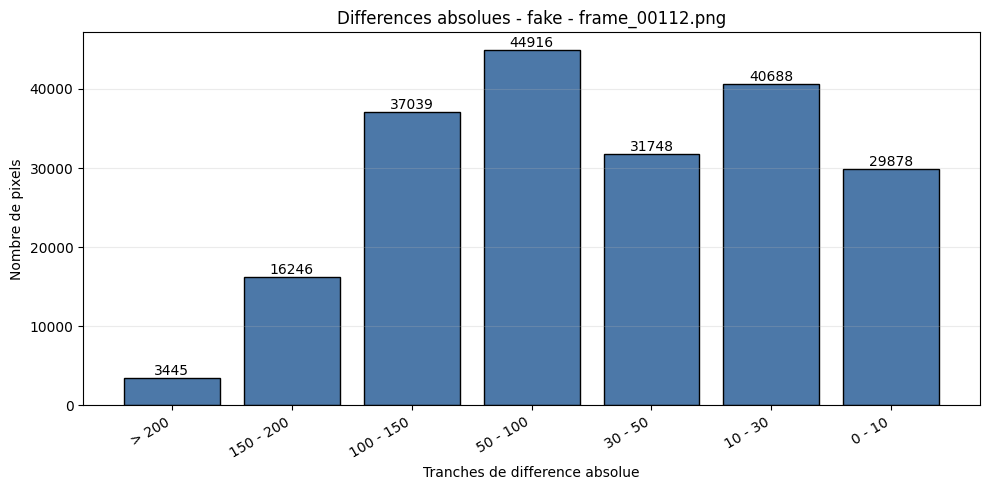

lvl:  4  initial error:  9380.14850530376
 error improvement too small, level converged! it:  12  error:  6659.4742570505005  lambda:  6.4
lvl:  3  initial error:  6973.754228498439
 error improvement too small, level converged! it:  3  error:  6923.808106170328  lambda:  0.0
lvl:  2  initial error:  7254.205893068152
 error improvement too small, level converged! it:  2  error:  7238.003083356998  lambda:  0.1
[fake] frame 113 -> frame_00113.png | sum error = 1360478080.00 | mean abs error = 67.0311 | valid pixels = 180739


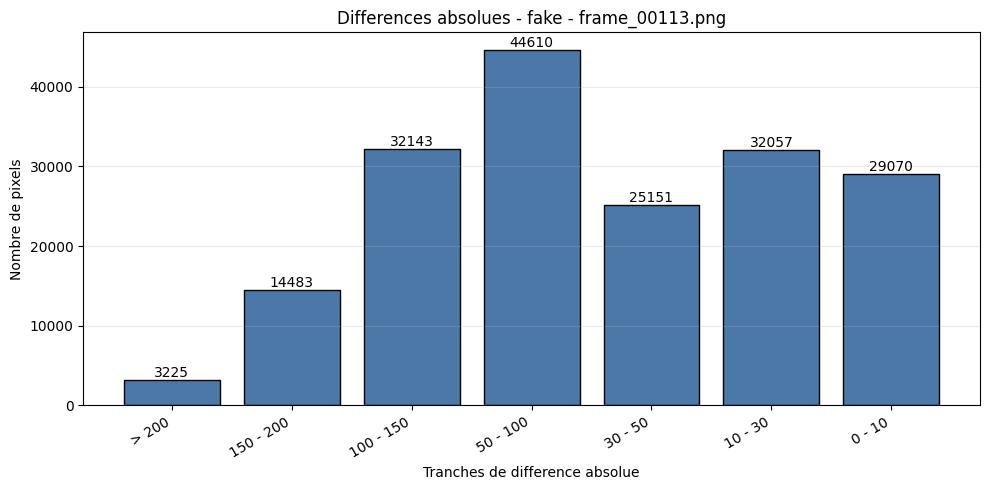

lvl:  4  initial error:  8658.506268081002
 error improvement too small, level converged! it:  22  error:  4310.3081440452825  lambda:  12.8
lvl:  3  initial error:  4783.721791090196
 error improvement too small, level converged! it:  2  error:  4763.948221639152  lambda:  0.4
lvl:  2  initial error:  5030.011720203667
 error improvement too small, level converged! it:  1  error:  5027.277553151195  lambda:  0.0
[fake] frame 114 -> frame_00114.png | sum error = 794249088.00 | mean abs error = 50.8232 | valid pixels = 150141


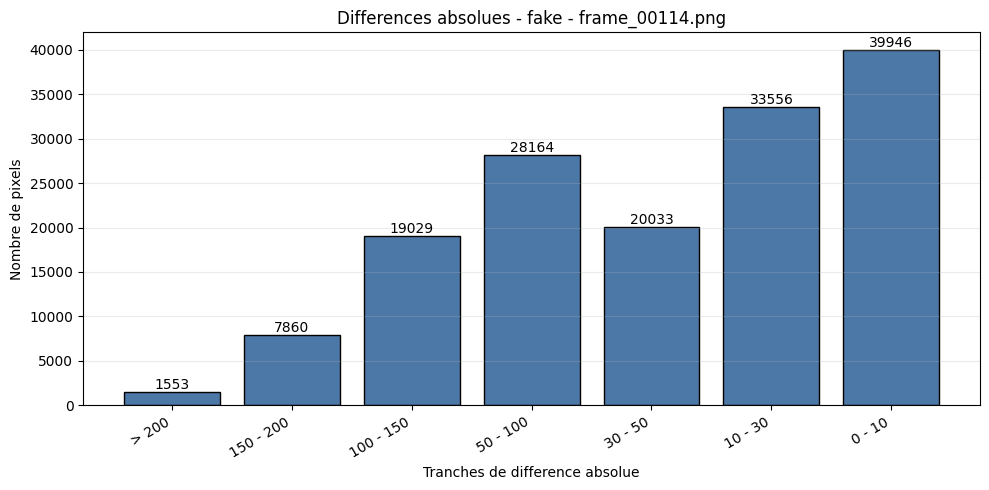

lvl:  4  initial error:  8474.329797492768
 error improvement too small, level converged! it:  6  error:  4300.8879358129625  lambda:  102.4
lvl:  3  initial error:  4767.2741282613615
 error improvement too small, level converged! it:  4  error:  4676.1334377805215  lambda:  12.8
lvl:  2  initial error:  4984.7586926591075
 error improvement too small, level converged! it:  3  error:  4921.331966385578  lambda:  0.1
[fake] frame 115 -> frame_00115.png | sum error = 812672640.00 | mean abs error = 50.9933 | valid pixels = 155503


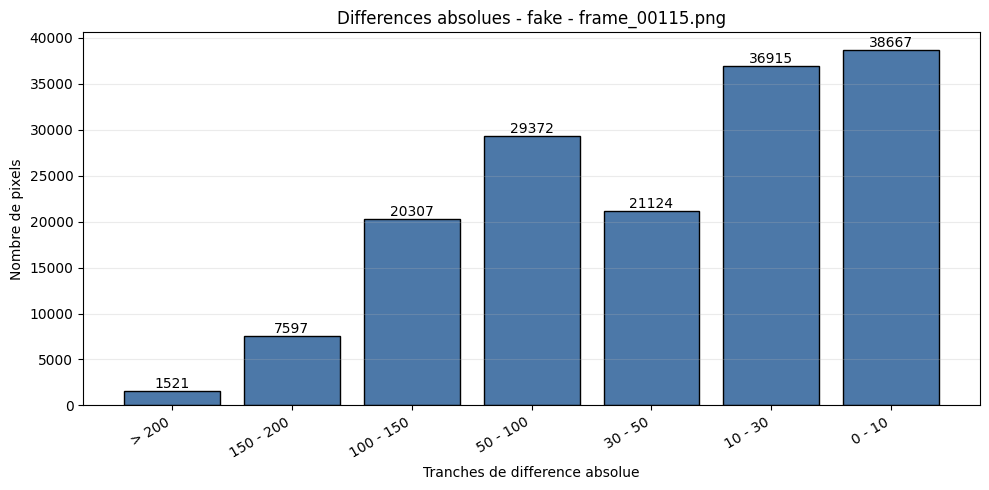

lvl:  4  initial error:  8498.547733847638
 error improvement too small, level converged! it:  2  error:  4273.0264679432175  lambda:  0.0
lvl:  3  initial error:  4616.835567404983
 error improvement too small, level converged! it:  5  error:  4509.512936487919  lambda:  0.1
lvl:  2  initial error:  4782.927469686504
 error improvement too small, level converged! it:  2  error:  4769.650216955677  lambda:  6.4
[fake] frame 116 -> frame_00116.png | sum error = 801942272.00 | mean abs error = 50.1746 | valid pixels = 157425


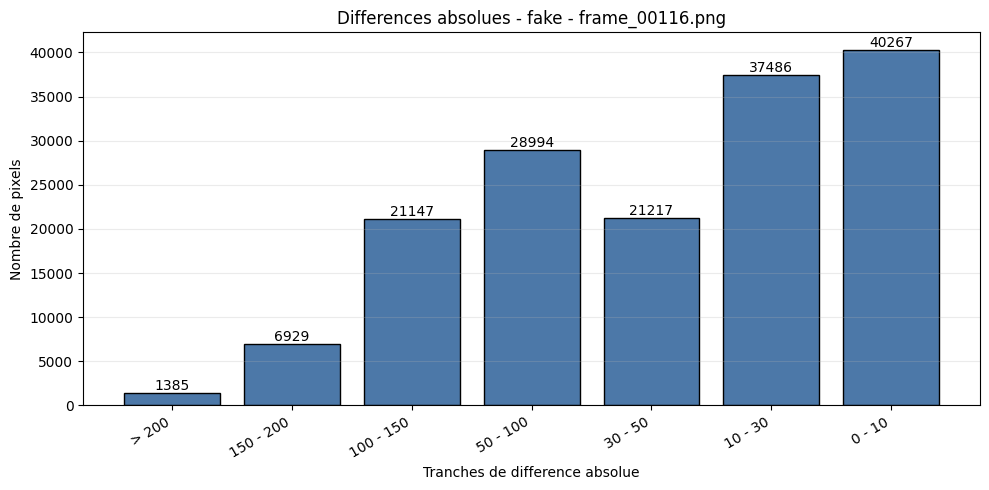

lvl:  4  initial error:  8229.710703953711
update too small, level converged! it:  2  error:  4127.297484412544  lambda:  2.8823037615171176e+16
lvl:  3  initial error:  4446.11738624107
 error improvement too small, level converged! it:  2  error:  4431.570013236764  lambda:  0.8
lvl:  2  initial error:  4685.922060618805
 error improvement too small, level converged! it:  1  error:  4684.518697025304  lambda:  0.0
[fake] frame 117 -> frame_00117.png | sum error = 780578496.00 | mean abs error = 49.5857 | valid pixels = 157296


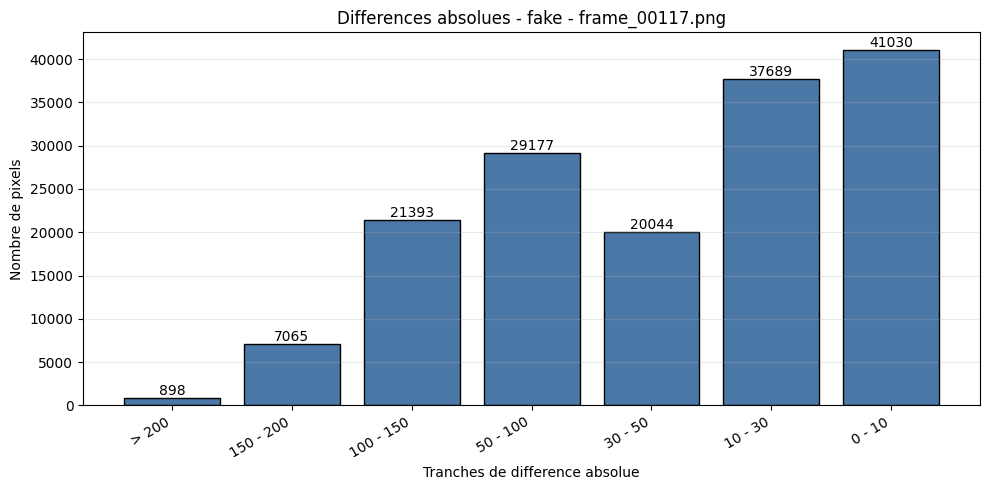

lvl:  4  initial error:  7670.507232401156
 error improvement too small, level converged! it:  5  error:  4091.2329544001727  lambda:  7036874417766.4
lvl:  3  initial error:  4699.711080948067
 error improvement too small, level converged! it:  3  error:  4636.115330759818  lambda:  1.6
lvl:  2  initial error:  4915.802635788831
 error improvement too small, level converged! it:  1  error:  4915.372083684616  lambda:  0.1
[fake] frame 118 -> frame_00118.png | sum error = 847976384.00 | mean abs error = 51.4295 | valid pixels = 162284


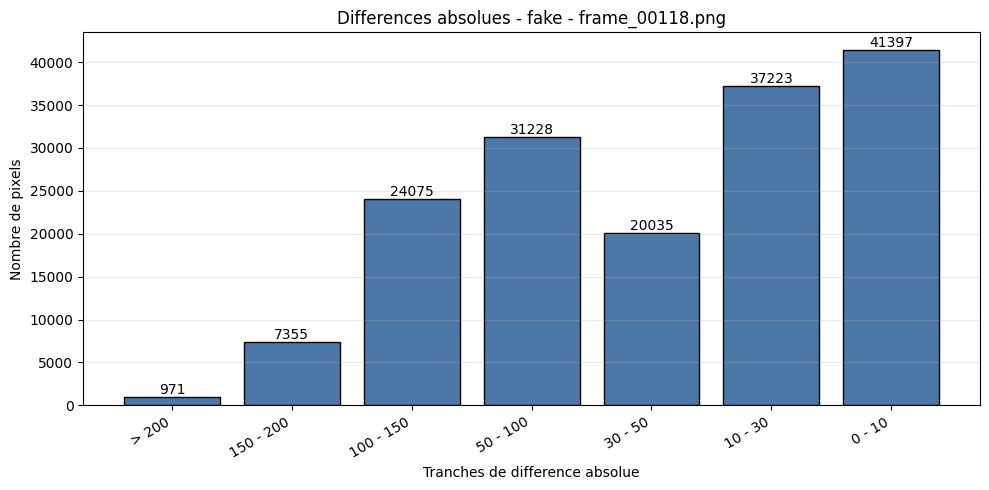

lvl:  4  initial error:  7483.86981677917
 error improvement too small, level converged! it:  8  error:  4096.3208428828675  lambda:  1638.4
lvl:  3  initial error:  4793.049315452955
 error improvement too small, level converged! it:  2  error:  4747.556277474346  lambda:  0.0
lvl:  2  initial error:  4972.9618570657485
 error improvement too small, level converged! it:  6  error:  4927.860642099939  lambda:  0.0
[fake] frame 119 -> frame_00119.png | sum error = 873303808.00 | mean abs error = 51.5191 | valid pixels = 167534


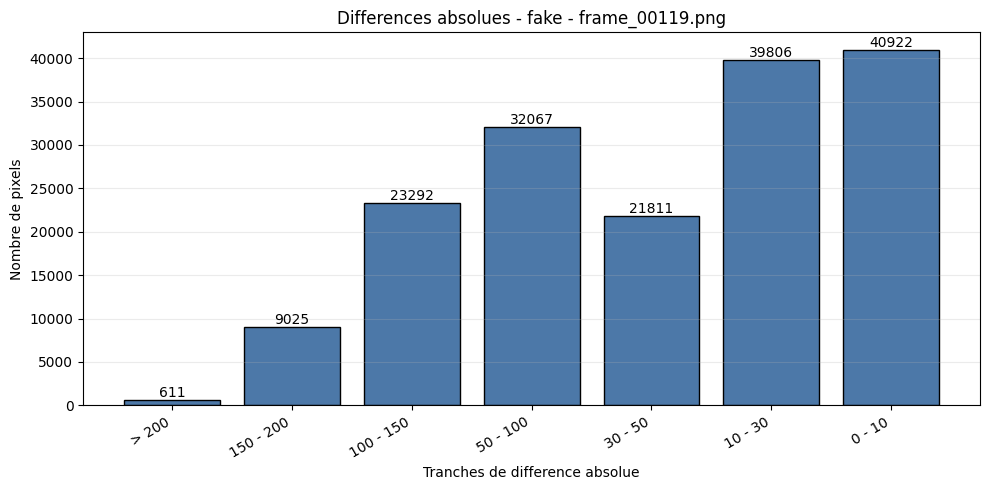

In [73]:
# Boucle simple sur toute la sequence: depth estimation puis pose estimation par frame.
# Cette version reconstruit une camera coherente pour la sequence traitee
# et reinitialise le solveur pour eviter de reutiliser un etat precedent.
frame_paths = fake_frame_paths[0:120]


if len(frame_paths) < 2:
    raise ValueError("Il faut au moins 2 frames pour lancer le pipeline.")

sequence_name = "fake"
sequence_keyframe = None
sequence_results = []

first_image_path = normalize_image_path(frame_paths[0])
first_image = load_gray_image(first_image_path)
sequence_height, sequence_width = first_image.shape[:2]

sequence_cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    sequence_width,
    sequence_height,
)
sequence_pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(sequence_cam, show_debug=False)

print(f"Sequence {sequence_name}:")
print(f"  source size = {sequence_width} x {sequence_height}")
print(f"  working size level-0 = {sequence_cam.width[0]} x {sequence_cam.height[0]}")
print(f"  fx level-0 = {sequence_cam.fx[0]}")
print(f"  fy level-0 = {sequence_cam.fy[0]}")
print()

for step, image_path in enumerate(frame_paths):
    image_path = normalize_image_path(image_path)
    image = load_gray_image(image_path)

    if image.shape[:2] != (sequence_height, sequence_width):
        raise ValueError(
            f"Toutes les images de la sequence {sequence_name} doivent avoir la meme taille. "
            f"Attendu: {(sequence_height, sequence_width)}, obtenu: {image.shape[:2]} pour {image_path.name}"
        )

    depth_map = load_depth_map(image_path)
    inv_depth, inv_depth_var, depth_valid_mask = depth_to_invdepth(depth_map)

    current_frame = frameData.frameData()
    current_frame.setImage(image)
    current_frame.setInvDepth(inv_depth, inv_depth_var)

    if step == 0:
        sequence_keyframe = current_frame
        print(f"[{sequence_name}] frame {step} -> keyframe de reference: {image_path.name}")
        sequence_results.append({
            "index": step,
            "image_path": str(image_path),
            "depth_valid_ratio": float(depth_valid_mask.mean()),
            "pose_matrix": current_frame.pose.as_matrix(),
            "photometric_error": None,
            "photometric_error_mean": None,
            "valid_pixel_count": None,            
            "histogram_counts": None,
     
        })
        continue

    sequence_pose_solver.optPose(current_frame, sequence_keyframe)
    evaluation = compute_photometric_error(current_frame, sequence_keyframe, sequence_cam, lvl=0)

    abs_error_map = np.sqrt(evaluation["squared_error_map"])
    valid_mask = evaluation["valid_mask"]
    valid_abs_errors = abs_error_map[valid_mask]
    valid_pixel_count = int(valid_abs_errors.size)
    photometric_error = float(evaluation["photometric_error"])
    photometric_error_mean = float(valid_abs_errors.mean()) if valid_pixel_count > 0 else None
    mean_error_display = f"{photometric_error_mean:.4f}" if photometric_error_mean is not None else "None"

    print(
        f"[{sequence_name}] frame {step} -> {image_path.name} | "
        f"sum error = {photometric_error:.2f} | "
        f"mean abs error = {mean_error_display} | "
        f"valid pixels = {valid_pixel_count}"
    )

    num_gt_200 = int(np.sum(valid_abs_errors > 200))
    num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
    num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
    num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))
    num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))
    num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))
    num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

    range_labels = [
        "> 200",
        "150 - 200",
        "100 - 150",
        "50 - 100",
        "30 - 50",
        "10 - 30",
        "0 - 10",
    ]

    range_counts = [
        num_gt_200,
        num_150_200,
        num_100_150,
        num_50_100,
        num_30_50,
        num_10_30,
        num_0_10,
    ]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
    plt.title(f"Differences absolues - {sequence_name} - {image_path.name}")
    plt.xlabel("Tranches de difference absolue")
    plt.ylabel("Nombre de pixels")
    plt.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=30, ha="right")

    for bar, count in zip(bars, range_counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(count),
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

    sequence_results.append({
        "index": step,
        "image_path": str(image_path),
        "depth_valid_ratio": float(depth_valid_mask.mean()),
        "pose_matrix": current_frame.pose.as_matrix(),
        "photometric_error": photometric_error,
        "photometric_error_mean": photometric_error_mean,
        "valid_pixel_count": valid_pixel_count,        
        "histogram_counts": range_counts,
    })


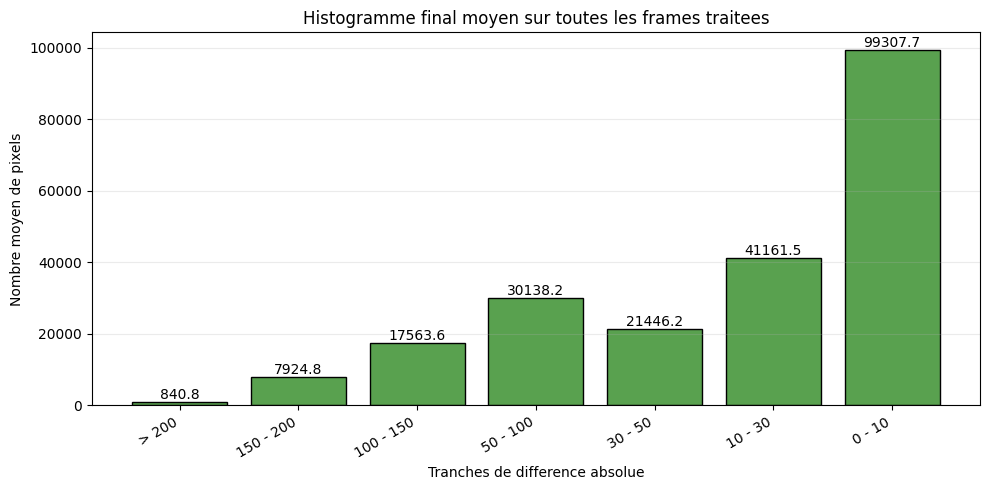

Histogramme final moyen:
     > 200 -> 840.85
  150 - 200 -> 7924.83
  100 - 150 -> 17563.56
  50 - 100 -> 30138.24
   30 - 50 -> 21446.21
   10 - 30 -> 41161.55
    0 - 10 -> 99307.68


In [74]:
valid_histogram_results = [
    item for item in sequence_results
    if item.get("histogram_counts") is not None
]

if not valid_histogram_results:
    raise ValueError("Aucun histogramme valide disponible pour calculer la moyenne finale.")

histogram_matrix = np.array([item["histogram_counts"] for item in valid_histogram_results], dtype=np.float64)
mean_histogram_counts = histogram_matrix.mean(axis=0)

final_range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

plt.figure(figsize=(10, 5))
bars = plt.bar(final_range_labels, mean_histogram_counts, color="#59A14F", edgecolor="black")
plt.title("Histogramme final moyen sur toutes les frames traitees")
plt.xlabel("Tranches de difference absolue")
plt.ylabel("Nombre moyen de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, value in zip(bars, mean_histogram_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

print("Histogramme final moyen:")
for label, value in zip(final_range_labels, mean_histogram_counts):
    print(f"  {label:>8} -> {value:.2f}")


752479043.1806723


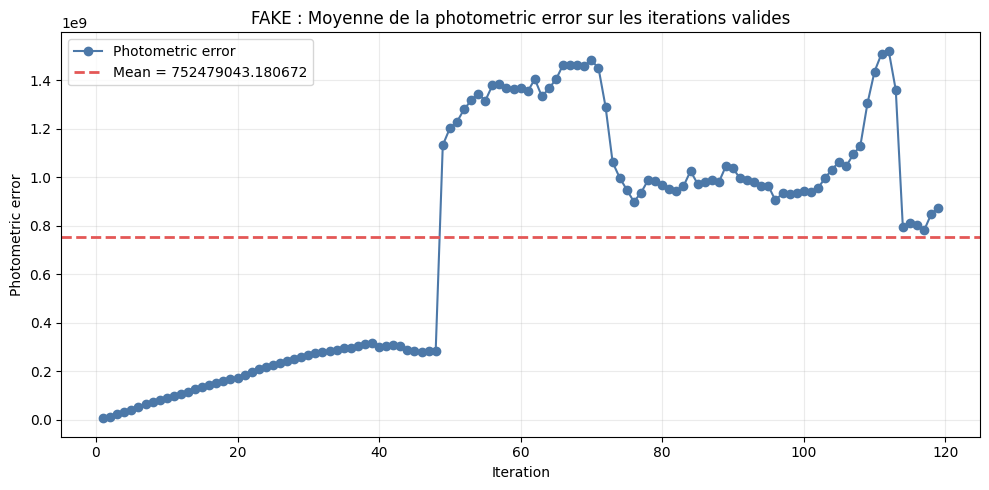

In [75]:
valid_results = [
    item for item in sequence_results
    if item["photometric_error"] is not None
]

if not valid_results:
    raise ValueError("Aucun résultat valide disponible pour calculer la moyenne des erreurs photométriques.")

iteration_indices = [item["index"] for item in valid_results]
photometric_errors = [item["photometric_error"] for item in valid_results]
mean_photometric_error = float(np.mean(photometric_errors))

print(mean_photometric_error)

plt.figure(figsize=(10, 5))
plt.plot(iteration_indices, photometric_errors, marker="o", color="#4C78A8", label="Photometric error")
plt.axhline(
    mean_photometric_error,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_photometric_error:.6f}"
)
plt.title("FAKE : Moyenne de la photometric error sur les iterations valides")
plt.xlabel("Iteration")
plt.ylabel("Photometric error")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()